# 02 SpanNER Baseline and Boundary Uncertainty

## Overview

This notebook develops the SpanNER branch of the dissertation pipeline using the fixed data populations established in Notebook 00.

A BERT-based span-classification model is trained over contiguous candidate spans with a maximum width of four words. The selected model is evaluated using strict typed-span metrics and then used to generate deterministic candidate probabilities and non-overlapping entity predictions for the validation, probability-calibration and conformal-calibration populations.

The notebook subsequently derives SpanNER-specific boundary uncertainty from competition between alternative candidate boundaries. For each decoded entity, start-boundary uncertainty is based on competing same-type candidates that preserve the predicted end boundary, while end-boundary uncertainty is based on competing candidates that preserve the predicted start boundary.

To complement these deterministic signals, ten-pass Monte Carlo Dropout is applied to the frozen model. Stochastic candidate-level measures, including predictive entropy, expected entropy, mutual information, probability variance and vote stability, are extracted without altering the deterministic candidate labels or decoded entity population. MC-mean boundary-competition signals are then calculated over the same fixed spans.

Prediction-to-gold matching is also performed to identify exact, type and boundary-specific correctness events and to support validation-only descriptive uncertainty analysis.

The resulting artefacts provide the SpanNER predictions, correctness labels and deterministic and stochastic uncertainty features required by the subsequent architecture-comparison, calibration and conformal-prediction stages.

Probability calibration and conformal prediction are not fitted in this notebook. The official CoNLL-2003 test split remains reserved for the final locked evaluation and is not loaded, inspected or evaluated here.


## 1. Environment, Reproducibility and Output Configuration

A fixed computational configuration is used throughout model training, deterministic inference and uncertainty extraction. Random seeds are controlled across Python, NumPy and PyTorch, and deterministic cuDNN behaviour is enabled where supported.

The SpanNER model is based on `bert-base-cased`. MC Dropout is applied only after model training and checkpoint selection have been completed; stochastic inference therefore does not influence model fitting or model selection.

All artefacts generated by this notebook are written to a dedicated output directory for use by subsequent comparison, calibration and conformal-prediction notebooks.

In [1]:
import gc
import hashlib
import json
import os
import random
import time
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from datasets import DatasetDict, load_dataset
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer


# Use the same frozen random seed throughout the dissertation pipeline.
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Prefer deterministic CUDA behaviour where supported.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Random seed:", SEED)
print("Device:", DEVICE)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print(
        "Warning: GPU execution is strongly recommended because "
        "the SpanNER model fine-tunes the complete BERT encoder."
    )

Random seed: 42
Device: cuda
GPU available: True
GPU: Tesla T4


### Software environment

In [2]:
environment_information = {
    "python": os.sys.version,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "torch": torch.__version__,
    "torch_cuda_version": torch.version.cuda,
    "transformers": version("transformers"),
    "datasets": version("datasets"),
    "gpu_available": torch.cuda.is_available(),
    "gpu_name": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else None
    ),
}

environment_df = pd.DataFrame(
    list(environment_information.items()),
    columns=["Component", "Version / Value"],
)

print("SpanNER software environment:")
display(environment_df)

SpanNER software environment:


,Component,Version / Value
0,python,"3.12.13 (main, Mar 4 2026, 09:23:07) [GCC 11...."
1,numpy,2.0.2
2,pandas,2.3.3
3,torch,2.10.0+cu128
4,torch_cuda_version,12.8
5,transformers,5.0.0
6,datasets,5.0.0
7,gpu_available,True
8,gpu_name,Tesla T4


### Experimental and output configuration

In [3]:
# Core model and inference configuration.
MODEL_CHECKPOINT = "bert-base-cased"
MAX_LENGTH = 256
MC_DROPOUT_PASSES = 10
NUM_WORKERS = 0

# The official CoNLL-2003 test split must remain inaccessible here.
RUN_FINAL_TEST = False

# These are the three frozen development populations reconstructed
# from the authoritative Notebook-00 registry.
PREDICTION_SPLITS = [
    "validation",
    "probability_calibration",
    "conformal_calibration",
]

# Store all Notebook-02 artefacts under one submission-ready directory.
OUTPUT_DIR = Path(
    "/kaggle/working/02_spanner_baseline_and_uncertainty"
)

MODEL_DIR = OUTPUT_DIR / "final_model"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
CONFIG_OUTPUT_DIR = OUTPUT_DIR / "configuration"
DATA_OUTPUT_DIR = OUTPUT_DIR / "processed_data"
CANDIDATE_OUTPUT_DIR = OUTPUT_DIR / "candidate_predictions"
SPAN_OUTPUT_DIR = OUTPUT_DIR / "span_predictions"
BOUNDARY_OUTPUT_DIR = OUTPUT_DIR / "boundary_competition"
MATCHING_OUTPUT_DIR = OUTPUT_DIR / "matching_tables"
METRICS_OUTPUT_DIR = OUTPUT_DIR / "metrics"
FIGURE_OUTPUT_DIR = OUTPUT_DIR / "figures"
MC_ARRAY_OUTPUT_DIR = OUTPUT_DIR / "mc_arrays"
CANDIDATE_UNCERTAINTY_DIR = OUTPUT_DIR / "candidate_uncertainty"
SPAN_UNCERTAINTY_DIR = OUTPUT_DIR / "span_uncertainty"
RUNTIME_OUTPUT_DIR = OUTPUT_DIR / "runtime"

output_directories = [
    OUTPUT_DIR,
    MODEL_DIR,
    CHECKPOINT_DIR,
    CONFIG_OUTPUT_DIR,
    DATA_OUTPUT_DIR,
    CANDIDATE_OUTPUT_DIR,
    SPAN_OUTPUT_DIR,
    BOUNDARY_OUTPUT_DIR,
    MATCHING_OUTPUT_DIR,
    METRICS_OUTPUT_DIR,
    FIGURE_OUTPUT_DIR,
    MC_ARRAY_OUTPUT_DIR,
    CANDIDATE_UNCERTAINTY_DIR,
    SPAN_UNCERTAINTY_DIR,
    RUNTIME_OUTPUT_DIR,
]

for directory in output_directories:
    directory.mkdir(parents=True, exist_ok=True)

# Save one environment record for reproducibility.
with open(
    CONFIG_OUTPUT_DIR / "environment_information.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(environment_information, file, indent=4)

print("Model checkpoint:", MODEL_CHECKPOINT)
print("Maximum sequence length:", MAX_LENGTH)
print("MC Dropout passes:", MC_DROPOUT_PASSES)
print("Output directory:", OUTPUT_DIR)
print("Official test selected by experiment code:", RUN_FINAL_TEST)

Model checkpoint: bert-base-cased
Maximum sequence length: 256
MC Dropout passes: 10
Output directory: /kaggle/working/02_spanner_baseline_and_uncertainty
Official test selected by experiment code: False


## 2. Load the Authoritative Notebook-00 Registry

The dataset configuration, BIO label mapping and predefined development-population indices are loaded from the artefacts generated in Notebook 00. This ensures that the validation, probability-calibration and conformal-calibration populations remain consistent across all subsequent stages of the experimental pipeline.

No additional splitting or resampling is performed in this notebook. The official CoNLL-2003 test split remains reserved for the final locked evaluation.

In [4]:
KAGGLE_INPUT_ROOT = Path("/kaggle/input")

if not KAGGLE_INPUT_ROOT.exists():
    raise FileNotFoundError("Kaggle input directory was not found.")

# Identify directories containing the complete Notebook-00 registry.
registry_candidates = []

for split_indices_file in KAGGLE_INPUT_ROOT.rglob("split_indices.json"):
    candidate_directory = split_indices_file.parent

    required_files = [
        candidate_directory / "split_indices.json",
        candidate_directory / "dataset_configuration.json",
        candidate_directory / "label_mapping.json",
    ]

    if all(path.is_file() for path in required_files):
        registry_candidates.append(candidate_directory)

registry_candidates = sorted(set(registry_candidates))

if len(registry_candidates) != 1:
    raise RuntimeError(
        "Expected exactly one compatible Notebook-00 registry under "
        f"/kaggle/input, but found {len(registry_candidates)}:\n"
        f"{registry_candidates}"
    )

DATA_REGISTRY_DIR = registry_candidates[0]

# Load the authoritative dataset configuration.
with open(
    DATA_REGISTRY_DIR / "dataset_configuration.json",
    "r",
    encoding="utf-8",
) as file:
    dataset_configuration = json.load(file)

# Load the shared BIO label mapping.
with open(
    DATA_REGISTRY_DIR / "label_mapping.json",
    "r",
    encoding="utf-8",
) as file:
    label_mapping = json.load(file)

# Load the frozen development-population source indices and identities.
with open(
    DATA_REGISTRY_DIR / "split_indices.json",
    "r",
    encoding="utf-8",
) as file:
    split_information = json.load(file)


DATASET_NAME = dataset_configuration["dataset_name"]

label_names = list(label_mapping["label_names"])

id2label = {
    int(label_id): label
    for label_id, label in label_mapping["id2label"].items()
}

label2id = {
    label: int(label_id)
    for label, label_id in label_mapping["label2id"].items()
}

# Derive entity types from the authoritative BIO label schema.
entity_types = [
    label.split("-", 1)[1]
    for label in label_names
    if label.startswith("B-")
]

# If Notebook 00 also stored entity types explicitly, require agreement.
if "entity_types" in label_mapping:
    if entity_types != list(label_mapping["entity_types"]):
        raise RuntimeError(
            "Derived entity types do not match the Notebook-00 label mapping."
        )

required_splits = {
    "validation",
    "probability_calibration",
    "conformal_calibration",
}

if set(split_information["splits"]) != required_splits:
    raise RuntimeError(
        "Notebook-00 split assignments do not match the expected "
        "development populations."
    )

if set(split_information["identities"]) != required_splits:
    raise RuntimeError(
        "Notebook-00 population identities do not match the expected "
        "development populations."
    )

if not dataset_configuration["test_split"]["reserved_for_final_evaluation"]:
    raise RuntimeError(
        "Notebook 00 does not mark the official test split as reserved."
    )

if dataset_configuration["test_split"]["loaded_in_notebook_00"]:
    raise RuntimeError(
        "Notebook 00 indicates that the official test split was loaded."
    )

if RUN_FINAL_TEST:
    raise RuntimeError(
        "Official test evaluation is disabled in Notebook 02."
    )

print("Notebook-00 registry:", DATA_REGISTRY_DIR)
print("Dataset:", DATASET_NAME)
print("BIO labels:", label_names)
print("Entity types:", entity_types)
print("Frozen development populations:", sorted(required_splits))
print("Official test reserved:", True)

Notebook-00 registry: /kaggle/input/datasets/umrahzargar/00-data-eda/00_data_eda_split_registry
Dataset: lhoestq/conll2003
BIO labels: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']
Entity types: ['PER', 'ORG', 'LOC', 'MISC']
Frozen development populations: ['conformal_calibration', 'probability_calibration', 'validation']
Official test reserved: True


## 3. Reconstruction of Development Populations

The CoNLL-2003 training and validation source splits are loaded directly from the dataset repository. The validation, probability-calibration and conformal-calibration populations are then reconstructed using the source indices defined in Notebook 00.

The reconstructed populations are verified against the identities recorded during dataset preparation. This check is performed once at the beginning of the SpanNER pipeline to confirm that all subsequent experiments operate on the intended observations.


In [5]:
# Load only the training and validation source splits required in this notebook.
train_dataset_raw = load_dataset(
    DATASET_NAME,
    split="train",
)

original_validation_dataset = load_dataset(
    DATASET_NAME,
    split="validation",
)


def select_with_source_index(source_dataset, indices):
    """Select registered rows while retaining their original source indices."""

    indices = [int(index) for index in indices]
    selected_dataset = source_dataset.select(indices)

    return selected_dataset.add_column(
        "source_index",
        indices,
    )


# Retain row provenance for the training population.
train_dataset = train_dataset_raw.add_column(
    "source_index",
    list(range(len(train_dataset_raw))),
)

# Reconstruct each predefined development population from Notebook 00.
validation_dataset = select_with_source_index(
    original_validation_dataset,
    split_information["splits"]["validation"],
)

probability_calibration_dataset = select_with_source_index(
    original_validation_dataset,
    split_information["splits"]["probability_calibration"],
)

conformal_calibration_dataset = select_with_source_index(
    original_validation_dataset,
    split_information["splits"]["conformal_calibration"],
)

dataset_splits = DatasetDict({
    "train": train_dataset,
    "validation": validation_dataset,
    "probability_calibration": probability_calibration_dataset,
    "conformal_calibration": conformal_calibration_dataset,
})

print("Development populations reconstructed successfully.")
print("Training sentences:", len(train_dataset))
print("Validation sentences:", len(validation_dataset))
print(
    "Probability-calibration sentences:",
    len(probability_calibration_dataset),
)
print(
    "Conformal-calibration sentences:",
    len(conformal_calibration_dataset),
)

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/281k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

...

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/1625 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/975 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/650 [00:00<?, ? examples/s]

Development populations reconstructed successfully.
Training sentences: 14041
Validation sentences: 1625
Probability-calibration sentences: 975
Conformal-calibration sentences: 650


### Verify reconstructed identities

In [6]:
def create_sentence_hash(tokens):
    """Create a deterministic SHA-256 hash for one token sequence."""

    payload = json.dumps(
        list(tokens),
        ensure_ascii=False,
        separators=(",", ":"),
    )

    return hashlib.sha256(
        payload.encode("utf-8")
    ).hexdigest()


def create_labeled_sentence_hash(tokens, ner_tags):
    """Create a deterministic hash for tokens and their BIO labels."""

    payload = {
        "tokens": list(tokens),
        "ner_tags": [int(tag) for tag in ner_tags],
    }

    encoded = json.dumps(
        payload,
        ensure_ascii=False,
        separators=(",", ":"),
        sort_keys=True,
    )

    return hashlib.sha256(
        encoded.encode("utf-8")
    ).hexdigest()


def sha256_from_lines(lines):
    """Combine ordered sentence hashes into one population hash."""

    return hashlib.sha256(
        "\n".join(lines).encode("utf-8")
    ).hexdigest()


identity_verification_rows = []

for split_name in PREDICTION_SPLITS:
    split_data = dataset_splits[split_name]

    token_hashes = []
    labeled_hashes = []
    token_count = 0

    for example in split_data:
        tokens = list(example["tokens"])
        ner_tags = [
            int(tag)
            for tag in example["ner_tags"]
        ]

        token_count += len(tokens)

        token_hashes.append(
            create_sentence_hash(tokens)
        )

        labeled_hashes.append(
            create_labeled_sentence_hash(
                tokens,
                ner_tags,
            )
        )

    reconstructed_identity = {
        "sentences": int(len(split_data)),
        "tokens": int(token_count),
        "aggregate_token_hash": sha256_from_lines(
            token_hashes
        ),
        "aggregate_labeled_hash": sha256_from_lines(
            labeled_hashes
        ),
    }

    saved_identity = split_information[
        "identities"
    ][split_name]

    identity_match = (
        reconstructed_identity["sentences"]
        == saved_identity["sentences"]
        and reconstructed_identity["tokens"]
        == saved_identity["tokens"]
        and reconstructed_identity["aggregate_token_hash"]
        == saved_identity["aggregate_token_hash"]
        and reconstructed_identity["aggregate_labeled_hash"]
        == saved_identity["aggregate_labeled_hash"]
    )

    identity_verification_rows.append({
        "Population": split_name,
        "Sentences": reconstructed_identity["sentences"],
        "Tokens": reconstructed_identity["tokens"],
        "Gold Spans": int(saved_identity["gold_spans"]),
        "Identity Verified": identity_match,
    })


identity_verification_df = pd.DataFrame(
    identity_verification_rows
)

if not identity_verification_df["Identity Verified"].all():
    raise RuntimeError(
        "At least one reconstructed development population "
        "does not match the identity recorded in Notebook 00."
    )

print("Development-population identity verification:")
display(identity_verification_df)

Development-population identity verification:


,Population,Sentences,Tokens,Gold Spans,Identity Verified
0,validation,1625,26021,3011,True
1,probability_calibration,975,15726,1756,True
2,conformal_calibration,650,9615,1175,True


## 4. Gold Spans and Candidate-Width Configuration

SpanNER formulates named-entity recognition as classification over contiguous candidate spans. Each candidate is assigned one of the four CoNLL-2003 entity types (`PER`, `ORG`, `LOC`, `MISC`) or the non-entity class `NONE`.

The token-level BIO annotations are first converted into complete typed entity spans. The same BIO conversion convention used in the BERT branch is retained for consistency between architectures.

The maximum candidate width is fixed at four original words. Its representational coverage and computational implications are summarised using the training population only; validation and calibration outcomes are not used to determine this setting. Gold entities wider than four words remain part of subsequent evaluation and are therefore treated as structurally unrepresentable by the SpanNER candidate space rather than being removed.


In [7]:
# Define the SpanNER classification labels from the shared entity schema.
span_label_names = [
    "NONE",
    *entity_types,
]

span_id2label = {
    label_id: label
    for label_id, label in enumerate(span_label_names)
}

span_label2id = {
    label: label_id
    for label_id, label in span_id2label.items()
}

if span_label2id["NONE"] != 0:
    raise RuntimeError("The NONE class must use label ID 0.")

span_label_mapping = {
    "span_label_names": span_label_names,
    "span_id2label": {
        str(label_id): label
        for label_id, label in span_id2label.items()
    },
    "span_label2id": span_label2id,
}

with open(
    CONFIG_OUTPUT_DIR / "span_label_mapping.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(span_label_mapping, file, indent=4)


def bio_to_spans(tokens, tags):
    """Convert BIO labels into complete typed entity spans."""

    if len(tokens) != len(tags):
        raise ValueError(
            "Tokens and BIO labels must have the same length."
        )

    spans = []
    current_entity = None

    def close_entity(entity, end_index):
        entity["end"] = int(end_index)
        entity["text"] = " ".join(
            tokens[entity["start"]: end_index + 1]
        )
        spans.append(entity)

    for token_index, tag in enumerate(tags):
        if tag == "O":
            if current_entity is not None:
                close_entity(
                    current_entity,
                    token_index - 1,
                )
                current_entity = None

        elif tag.startswith("B-") and len(tag) > 2:
            if current_entity is not None:
                close_entity(
                    current_entity,
                    token_index - 1,
                )

            current_entity = {
                "type": tag[2:],
                "start": int(token_index),
                "end": int(token_index),
            }

        elif tag.startswith("I-") and len(tag) > 2:
            entity_type = tag[2:]

            if (
                current_entity is not None
                and current_entity["type"] == entity_type
            ):
                current_entity["end"] = int(token_index)

            else:
                # An incompatible I-X label begins a new entity of type X.
                if current_entity is not None:
                    close_entity(
                        current_entity,
                        token_index - 1,
                    )

                current_entity = {
                    "type": entity_type,
                    "start": int(token_index),
                    "end": int(token_index),
                }

        else:
            raise ValueError(
                f"Unexpected BIO label: {tag}"
            )

    if current_entity is not None:
        close_entity(
            current_entity,
            len(tokens) - 1,
        )

    return spans


bio_conversion_policy = {
    "incompatible_I_label": (
        "An incompatible I-X label begins a new entity of type X."
    ),
    "shared_with_bert_branch": True,
}

with open(
    CONFIG_OUTPUT_DIR / "bio_conversion_policy.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        bio_conversion_policy,
        file,
        indent=4,
    )

span_label_table = pd.DataFrame({
    "Label ID": list(span_id2label.keys()),
    "Span Label": list(span_id2label.values()),
})

print("SpanNER candidate-label space:")
display(span_label_table)

SpanNER candidate-label space:


,Label ID,Span Label
0,0,NONE
1,1,PER
2,2,ORG
3,3,LOC
4,4,MISC


### Construct gold span tables

In [8]:
gold_span_tables = {}
gold_span_records = []

for split_name, split_data in dataset_splits.items():
    split_records = []

    for sentence_index, example in enumerate(
        tqdm(
            split_data,
            desc=f"Gold spans: {split_name}",
        )
    ):
        gold_tags = [
            id2label[int(tag_id)]
            for tag_id in example["ner_tags"]
        ]

        sentence_spans = bio_to_spans(
            tokens=example["tokens"],
            tags=gold_tags,
        )

        for entity_index, span in enumerate(sentence_spans):
            row = {
                "split": split_name,
                "source_index": int(example["source_index"]),
                "sentence_id": str(example["id"]),
                "sentence_index": int(sentence_index),
                "entity_index": int(entity_index),
                "entity_text": str(span["text"]),
                "entity_type": str(span["type"]),
                "start": int(span["start"]),
                "end": int(span["end"]),
                "token_count": int(
                    span["end"] - span["start"] + 1
                ),
                "sentence_length": int(
                    len(example["tokens"])
                ),
            }

            split_records.append(row)
            gold_span_records.append(row)

    split_gold_df = pd.DataFrame(split_records)
    gold_span_tables[split_name] = split_gold_df

    split_gold_df.to_csv(
        DATA_OUTPUT_DIR / f"{split_name}_gold_spans.csv",
        index=False,
    )


gold_entity_spans_df = pd.DataFrame(
    gold_span_records
)

gold_entity_spans_df.to_csv(
    DATA_OUTPUT_DIR / "gold_entity_spans.csv",
    index=False,
)

# Confirm that the BIO-to-span conversion reproduces the
# development-population span counts recorded in Notebook 00.
for split_name in PREDICTION_SPLITS:
    expected_gold_spans = int(
        split_information["identities"][
            split_name
        ]["gold_spans"]
    )

    if len(gold_span_tables[split_name]) != expected_gold_spans:
        raise RuntimeError(
            f"Gold-span count mismatch for {split_name}."
        )


gold_span_summary_df = pd.DataFrame({
    "Population": list(gold_span_tables.keys()),
    "Gold Entity Spans": [
        len(gold_span_tables[split_name])
        for split_name in gold_span_tables
    ],
})

print("Gold entity-span counts:")
display(gold_span_summary_df)

Gold spans: train:   0%|          | 0/14041 [00:00<?, ?it/s]

Gold spans: validation:   0%|          | 0/1625 [00:00<?, ?it/s]

Gold spans: probability_calibration:   0%|          | 0/975 [00:00<?, ?it/s]

Gold spans: conformal_calibration:   0%|          | 0/650 [00:00<?, ?it/s]

Gold entity-span counts:


,Population,Gold Entity Spans
0,train,23499
1,validation,3011
2,probability_calibration,1756
3,conformal_calibration,1175


### Create sentence-level gold-span lookup

In [9]:
gold_spans_by_sentence = {}

for split_name, split_gold_df in gold_span_tables.items():
    for row in split_gold_df.itertuples(index=False):
        sentence_key = (
            split_name,
            int(row.sentence_index),
        )

        gold_spans_by_sentence.setdefault(
            sentence_key,
            [],
        ).append({
            "start": int(row.start),
            "end": int(row.end),
            "type": str(row.entity_type),
            "text": str(row.entity_text),
        })

print(
    "Gold-span lookup created for",
    f"{len(gold_spans_by_sentence):,}",
    "sentences containing at least one entity.",
)

Gold-span lookup created for 13,737 sentences containing at least one entity.


### 4.1 Training-Only Assessment of Candidate Width

Restricting the maximum span width reduces the number of candidate spans that must be classified, but also limits which gold entities are representable. To document this trade-off without using validation information, entity-width coverage and candidate counts are calculated exclusively from the training population.

The adopted SpanNER configuration uses a maximum width of four words. Width six is shown only as a computational reference point and is not treated as an alternative selected through validation performance.


In [10]:
#Width coverage and candidate cost
training_gold_spans_df = gold_span_tables["train"].copy()

training_width_distribution_df = (
    training_gold_spans_df["token_count"]
    .value_counts()
    .sort_index()
    .rename_axis("Entity Width")
    .reset_index(name="Entity Count")
)

training_width_distribution_df["Proportion"] = (
    training_width_distribution_df["Entity Count"]
    / len(training_gold_spans_df)
)

training_width_distribution_df[
    "Cumulative Proportion"
] = (
    training_width_distribution_df["Proportion"]
    .cumsum()
)


def count_sentence_candidates(
    sentence_length,
    maximum_width,
):
    """Count contiguous candidate spans without materialising them."""

    return sum(
        min(
            maximum_width,
            sentence_length - start,
        )
        for start in range(sentence_length)
    )


candidate_cost_records = []

for maximum_width in [4, 6]:
    total_candidates = sum(
        count_sentence_candidates(
            sentence_length=len(example["tokens"]),
            maximum_width=maximum_width,
        )
        for example in dataset_splits["train"]
    )

    representable_entities = int(
        (
            training_gold_spans_df["token_count"]
            <= maximum_width
        ).sum()
    )

    none_candidates = (
        total_candidates - representable_entities
    )

    candidate_cost_records.append({
        "Maximum Span Width": maximum_width,
        "Total Training Candidates": int(total_candidates),
        "Representable Gold Entities": representable_entities,
        "Excluded Gold Entities": int(
            len(training_gold_spans_df)
            - representable_entities
        ),
        "NONE Candidates": int(none_candidates),
        "NONE-to-Positive Ratio": (
            none_candidates
            / representable_entities
        ),
        "Representable Percentage": (
            100
            * representable_entities
            / len(training_gold_spans_df)
        ),
    })


candidate_width_cost_df = pd.DataFrame(
    candidate_cost_records
)

MAX_SPAN_WIDTH = 4

width_four_row = candidate_width_cost_df.loc[
    candidate_width_cost_df[
        "Maximum Span Width"
    ] == MAX_SPAN_WIDTH
].iloc[0]

width_four_candidates = int(
    width_four_row["Total Training Candidates"]
)

width_six_candidates = int(
    candidate_width_cost_df.loc[
        candidate_width_cost_df[
            "Maximum Span Width"
        ] == 6,
        "Total Training Candidates",
    ].iloc[0]
)

candidate_increase = (
    width_six_candidates
    - width_four_candidates
)

candidate_percentage_increase = (
    100
    * candidate_increase
    / width_four_candidates
)

span_width_configuration = {
    "maximum_span_width": MAX_SPAN_WIDTH,
    "training_gold_entities": int(
        len(training_gold_spans_df)
    ),
    "representable_training_entities": int(
        width_four_row[
            "Representable Gold Entities"
        ]
    ),
    "excluded_training_entities": int(
        width_four_row[
            "Excluded Gold Entities"
        ]
    ),
    "representable_percentage": float(
        width_four_row[
            "Representable Percentage"
        ]
    ),
    "training_candidates_width_4": (
        width_four_candidates
    ),
    "training_candidates_width_6": (
        width_six_candidates
    ),
    "candidate_increase_width_4_to_6": int(
        candidate_increase
    ),
    "candidate_percentage_increase_width_4_to_6": float(
        candidate_percentage_increase
    ),
    "selection_population": "training only",
}

with open(
    CONFIG_OUTPUT_DIR / "span_width_configuration.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        span_width_configuration,
        file,
        indent=4,
    )

candidate_width_cost_df.to_csv(
    DATA_OUTPUT_DIR / "candidate_width_training_summary.csv",
    index=False,
)

print("Candidate-width training summary:")
display(candidate_width_cost_df.round(4))

print(
    "\nSelected maximum span width:",
    MAX_SPAN_WIDTH,
)

print(
    "Representable training entities:",
    f"{span_width_configuration['representable_percentage']:.4f}%",
)

print(
    "Increase in candidate count from width 4 to width 6:",
    f"{candidate_percentage_increase:.2f}%",
)

Candidate-width training summary:


,Maximum Span Width,Total Training Candidates,Representable Gold Entities,Excluded Gold Entities,NONE Candidates,NONE-to-Positive Ratio,Representable Percentage
0,4,731904,23369,130,708535,30.3194,99.4468
1,6,1022204,23476,23,998728,42.5425,99.9021



Selected maximum span width: 4
Representable training entities: 99.4468%
Increase in candidate count from width 4 to width 6: 39.66%


### 4.2 Candidate Generation

For each sentence, all contiguous word spans of length one to four are enumerated as SpanNER candidates. A candidate receives an entity label when its start and end boundaries exactly match a gold entity; all other candidates are assigned the `NONE` class.

Candidate boundaries are defined at the original-word level. Gold entities longer than the maximum span width are retained in the evaluation data but cannot appear as positive candidates within the width-constrained SpanNER representation.


In [11]:
def generate_candidate_spans(
    tokens,
    gold_spans,
    max_span_width,
):
    """Generate contiguous SpanNER candidates up to the specified width."""

    if max_span_width < 1:
        raise ValueError(
            "Maximum span width must be at least one."
        )

    sentence_length = len(tokens)

    # Map exact gold boundaries to their entity types so that
    # candidate labelling is performed at the complete-span level.
    gold_span_lookup = {}

    for gold_span in gold_spans:
        start = int(gold_span["start"])
        end = int(gold_span["end"])
        entity_type = str(gold_span["type"])

        # Gold boundaries must refer to valid original-word positions.
        if not (0 <= start <= end < sentence_length):
            raise ValueError(
                f"Invalid gold span boundaries: {(start, end)}"
            )

        if entity_type not in span_label2id:
            raise ValueError(
                f"Unknown entity type: {entity_type}"
            )

        gold_span_lookup[(start, end)] = entity_type

    candidate_spans = []
    candidate_id = 0

    # Enumerate every contiguous word span whose width does not
    # exceed the fixed SpanNER candidate-width limit.
    for start in range(sentence_length):
        maximum_end = min(
            sentence_length - 1,
            start + max_span_width - 1,
        )

        for end in range(start, maximum_end + 1):
            boundary_key = (start, end)

            # Exact gold-boundary matches receive their entity type;
            # every other candidate is treated as a non-entity span.
            gold_label = gold_span_lookup.get(
                boundary_key,
                "NONE",
            )

            candidate_spans.append({
                "candidate_id": int(candidate_id),
                "start": int(start),
                "end": int(end),
                "width": int(end - start + 1),
                "text": " ".join(tokens[start:end + 1]),
                "gold_label": gold_label,
                "gold_label_id": int(
                    span_label2id[gold_label]
                ),
            })

            candidate_id += 1

    # Confirm that enumeration produced the expected number of
    # contiguous spans for this sentence and width configuration.
    expected_candidate_count = count_sentence_candidates(
        sentence_length=sentence_length,
        maximum_width=max_span_width,
    )

    if len(candidate_spans) != expected_candidate_count:
        raise RuntimeError(
            "Candidate enumeration produced an unexpected "
            "number of spans."
        )

    return candidate_spans


print(
    "Candidate-generation function configured with maximum width:",
    MAX_SPAN_WIDTH,
)

Candidate-generation function configured with maximum width: 4


### Summarise the candidate populations

In [12]:
candidate_population_records = []

for split_name, split_data in dataset_splits.items():
    # Calculate the complete width-4 candidate universe for the split
    # without storing every individual candidate in memory.
    total_candidates = sum(
        count_sentence_candidates(
            sentence_length=len(example["tokens"]),
            maximum_width=MAX_SPAN_WIDTH,
        )
        for example in split_data
    )

    split_gold_df = gold_span_tables[split_name]

    # Only gold entities within the maximum width can correspond to
    # positive candidates in the SpanNER classification space.
    entity_candidates = int(
        (
            split_gold_df["token_count"]
            <= MAX_SPAN_WIDTH
        ).sum()
    )

    unrepresentable_gold_entities = int(
        len(split_gold_df)
        - entity_candidates
    )

    none_candidates = int(
        total_candidates
        - entity_candidates
    )

    candidate_population_records.append({
        "Population": split_name,
        "Total Candidates": int(total_candidates),
        "Entity Candidates": entity_candidates,
        "NONE Candidates": none_candidates,
        "NONE-to-Entity Ratio": (
            none_candidates / entity_candidates
        ),
        "Unrepresentable Gold Entities": (
            unrepresentable_gold_entities
        ),
    })


candidate_population_df = pd.DataFrame(
    candidate_population_records
)

# Retain the candidate-space summary as a compact methodological artefact.
candidate_population_df.to_csv(
    METRICS_OUTPUT_DIR / "candidate_population_summary.csv",
    index=False,
)

print("SpanNER candidate-population summary:")
display(candidate_population_df.round(4))

SpanNER candidate-population summary:


,Population,Total Candidates,Entity Candidates,NONE Candidates,NONE-to-Entity Ratio,Unrepresentable Gold Entities
0,train,731904,23369,708535,30.3194,130
1,validation,94497,2993,91504,30.5727,18
2,probability_calibration,57126,1750,55376,31.6434,6
3,conformal_calibration,34635,1169,33466,28.6279,6


## 5. Tokenisation and Span Features

Span candidates are defined over original CoNLL-2003 words, whereas contextual representations are obtained from BERT subword tokens. Each original word is therefore mapped to its first and last BERT subword positions. A candidate span is represented using the BERT vector at the first subword of its starting word and the BERT vector at the last subword of its ending word.

Two additional length features are retained: the candidate length in original words and a tokenised-width bucket derived from the distance between its BERT subword endpoints. Tokenisation is performed without truncation so that all original-word boundaries remain available to the span model.


In [13]:
# A fast tokenizer is required because word-to-subword alignment
# relies on the word_ids() mapping provided by Hugging Face.
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_CHECKPOINT,
    use_fast=True,
)

if not tokenizer.is_fast:
    raise RuntimeError(
        "SpanNER requires a fast tokenizer for word-to-subword alignment."
    )

print("Tokenizer:", tokenizer.__class__.__name__)
print("Fast tokenizer:", tokenizer.is_fast)
print("Vocabulary size:", tokenizer.vocab_size)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer: BertTokenizer
Fast tokenizer: True
Vocabulary size: 28996


### Confirm sequence lengths

In [14]:
sequence_length_records = []

for split_name, split_data in dataset_splits.items():
    split_lengths = []

    # Tokenise complete pre-split word sequences so that the true
    # BERT sequence length can be assessed before model preparation.
    for example in tqdm(
        split_data,
        desc=f"Token lengths: {split_name}",
    ):
        encoded = tokenizer(
            example["tokens"],
            is_split_into_words=True,
            truncation=False,
            add_special_tokens=True,
        )

        split_lengths.append(
            len(encoded["input_ids"])
        )

    split_lengths = np.asarray(
        split_lengths,
        dtype=np.int32,
    )

    sequence_length_records.append({
        "Population": split_name,
        "Sentences": int(len(split_lengths)),
        "Mean BERT Tokens": float(
            split_lengths.mean()
        ),
        "Maximum BERT Tokens": int(
            split_lengths.max()
        ),
        f"Sentences Above {MAX_LENGTH}": int(
            (split_lengths > MAX_LENGTH).sum()
        ),
    })


sequence_length_summary_df = pd.DataFrame(
    sequence_length_records
)

sequence_length_summary_df[
    "Mean BERT Tokens"
] = sequence_length_summary_df[
    "Mean BERT Tokens"
].round(2)

# Truncation would invalidate original-word boundary mappings, so all
# accessible sentences must fit within the configured sequence length.
if (
    sequence_length_summary_df[
        f"Sentences Above {MAX_LENGTH}"
    ] > 0
).any():
    raise RuntimeError(
        f"At least one sentence exceeds MAX_LENGTH={MAX_LENGTH}."
    )

sequence_length_summary_df.to_csv(
    METRICS_OUTPUT_DIR / "tokenised_sequence_lengths.csv",
    index=False,
)

print("Tokenised sequence-length summary:")
display(sequence_length_summary_df)

print(
    f"\nAll accessible sentences fit within MAX_LENGTH={MAX_LENGTH}; "
    "no truncation is required."
)

Token lengths: train:   0%|          | 0/14041 [00:00<?, ?it/s]

Token lengths: validation:   0%|          | 0/1625 [00:00<?, ?it/s]

Token lengths: probability_calibration:   0%|          | 0/975 [00:00<?, ?it/s]

Token lengths: conformal_calibration:   0%|          | 0/650 [00:00<?, ?it/s]

Tokenised sequence-length summary:


,Population,Sentences,Mean BERT Tokens,Maximum BERT Tokens,Sentences Above 256
0,train,14041,21.41,173,0
1,validation,1625,23.23,121,0
2,probability_calibration,975,23.18,139,0
3,conformal_calibration,650,21.68,151,0



All accessible sentences fit within MAX_LENGTH=256; no truncation is required.


### Map original words to BERT endpoints

In [15]:
def get_word_subword_boundaries(tokens):
    """
    Tokenise one sentence and return the first and last BERT
    subword position corresponding to each original word.
    """

    # Truncation is deliberately disabled so that every original
    # word remains available for candidate-span construction.
    encoded = tokenizer(
        tokens,
        is_split_into_words=True,
        truncation=False,
        add_special_tokens=True,
    )

    word_ids = encoded.word_ids()

    first_subword_positions = [None] * len(tokens)
    last_subword_positions = [None] * len(tokens)

    # Record the first and final BERT token associated with each
    # original CoNLL word.
    for bert_position, word_id in enumerate(word_ids):
        if word_id is None:
            continue

        if first_subword_positions[word_id] is None:
            first_subword_positions[word_id] = bert_position

        last_subword_positions[word_id] = bert_position

    # Every original word must have a valid BERT representation.
    if any(
        position is None
        for position in first_subword_positions
    ):
        raise RuntimeError(
            "At least one word has no first BERT subword position."
        )

    if any(
        position is None
        for position in last_subword_positions
    ):
        raise RuntimeError(
            "At least one word has no final BERT subword position."
        )

    if any(
        first_position > last_position
        for first_position, last_position in zip(
            first_subword_positions,
            last_subword_positions,
        )
    ):
        raise RuntimeError(
            "Invalid word-to-subword boundary ordering."
        )

    if len(encoded["input_ids"]) > MAX_LENGTH:
        raise RuntimeError(
            "Tokenised sentence exceeds the configured maximum length."
        )

    return (
        encoded,
        first_subword_positions,
        last_subword_positions,
    )


print("Word-to-subword boundary mapping configured.")

Word-to-subword boundary mapping configured.


### Candidate length features

In [16]:
# The validated SpanNER configuration uses four tokenised-width buckets.
TOKENISED_WIDTH_BUCKETS = 4


def bucket_tokenised_width(
    first_subword_position,
    last_subword_position,
):
    """
    Convert the distance between BERT span endpoints into one of
    four tokenised-width categories.
    """

    if first_subword_position > last_subword_position:
        raise ValueError(
            "The first subword position cannot exceed the last."
        )

    # Endpoint distance is used rather than original-word width;
    # larger distances are clipped into the final bucket.
    subword_distance = (
        last_subword_position
        - first_subword_position
    )

    return min(
        subword_distance,
        TOKENISED_WIDTH_BUCKETS - 1,
    )


def get_candidate_length_features(
    candidate_start,
    candidate_end,
    first_subword_positions,
    last_subword_positions,
):
    """
    Return the original-word and BERT-token length features
    required by the SpanNER representation.
    """

    # Original-word length is bounded by the fixed width-4
    # candidate universe.
    word_length = (
        candidate_end
        - candidate_start
        + 1
    )

    if not (
        1
        <= word_length
        <= MAX_SPAN_WIDTH
    ):
        raise ValueError(
            f"Invalid candidate word length: {word_length}"
        )

    # A span begins at the first BERT subword of its first word
    # and ends at the last BERT subword of its final word.
    start_subword = first_subword_positions[
        candidate_start
    ]

    end_subword = last_subword_positions[
        candidate_end
    ]

    tokenised_width_bucket = (
        bucket_tokenised_width(
            start_subword,
            end_subword,
        )
    )

    return {
        "word_length": int(word_length),
        "tokenised_width_bucket": int(
            tokenised_width_bucket
        ),
        "start_subword": int(start_subword),
        "end_subword": int(end_subword),
        "subword_count": int(
            end_subword
            - start_subword
            + 1
        ),
    }


print(
    "Original-word candidate widths:",
    f"1 to {MAX_SPAN_WIDTH}",
)
print(
    "Tokenised-width buckets:",
    TOKENISED_WIDTH_BUCKETS,
)

Original-word candidate widths: 1 to 4
Tokenised-width buckets: 4


## 6. SpanNER Input Preparation

Each sentence is converted into a BERT input sequence together with its complete width-constrained candidate set. For every candidate, the prepared representation retains the original-word boundaries, corresponding BERT subword endpoints, original-word length, tokenised-width bucket and gold span label.

Because non-entity spans substantially outnumber entity spans, `NONE` candidates receive a reduced loss weight of 0.5 during training, while positive entity candidates retain unit weight. This weighting is applied only to the training objective; validation loss and model selection remain unweighted.

Training and validation DataLoaders are constructed at this stage. The probability-calibration and conformal-calibration populations are retained for later frozen-model inference and do not contribute to parameter fitting or checkpoint selection.


In [17]:
# Reduce the contribution of the substantially more frequent NONE
# candidates while retaining every candidate in the training population.
NEGATIVE_SPAN_WEIGHT = 0.5


def prepare_spanner_sentence(
    split_name,
    sentence_index,
):
    """Prepare one sentence and its complete SpanNER candidate set."""

    if split_name not in dataset_splits:
        raise ValueError(
            f"Unknown dataset split: {split_name}"
        )

    example = dataset_splits[split_name][
        sentence_index
    ]

    tokens = list(example["tokens"])

    # Tokenise the sentence and recover the BERT endpoint associated
    # with every original CoNLL word.
    (
        encoded,
        first_subword_positions,
        last_subword_positions,
    ) = get_word_subword_boundaries(tokens)

    # Retrieve the complete typed gold spans for this sentence.
    sentence_gold_spans = gold_spans_by_sentence.get(
        (split_name, sentence_index),
        [],
    )

    # Enumerate the full width-4 candidate universe.
    candidates = generate_candidate_spans(
        tokens=tokens,
        gold_spans=sentence_gold_spans,
        max_span_width=MAX_SPAN_WIDTH,
    )

    span_word_indices = []
    span_subword_indices = []
    span_word_lengths = []
    tokenised_width_buckets = []
    span_labels = []
    span_weights = []
    candidate_texts = []

    # Convert every candidate into the features consumed by the model.
    for candidate in candidates:
        features = get_candidate_length_features(
            candidate_start=candidate["start"],
            candidate_end=candidate["end"],
            first_subword_positions=first_subword_positions,
            last_subword_positions=last_subword_positions,
        )

        span_word_indices.append([
            candidate["start"],
            candidate["end"],
        ])

        span_subword_indices.append([
            features["start_subword"],
            features["end_subword"],
        ])

        span_word_lengths.append(
            features["word_length"]
        )

        tokenised_width_buckets.append(
            features["tokenised_width_bucket"]
        )

        span_labels.append(
            candidate["gold_label_id"]
        )

        # NONE candidates are down-weighted during model fitting only.
        span_weights.append(
            NEGATIVE_SPAN_WEIGHT
            if candidate["gold_label"] == "NONE"
            else 1.0
        )

        candidate_texts.append(
            candidate["text"]
        )

    number_of_candidates = len(candidates)

    # Convert model inputs and candidate-level features to tensors.
    prepared_sentence = {
        "input_ids": torch.tensor(
            encoded["input_ids"],
            dtype=torch.long,
        ),
        "attention_mask": torch.tensor(
            encoded["attention_mask"],
            dtype=torch.long,
        ),
        "token_type_ids": torch.tensor(
            encoded.get(
                "token_type_ids",
                [0] * len(encoded["input_ids"]),
            ),
            dtype=torch.long,
        ),
        "span_word_indices": torch.tensor(
            span_word_indices,
            dtype=torch.long,
        ),
        "span_subword_indices": torch.tensor(
            span_subword_indices,
            dtype=torch.long,
        ),
        "span_word_lengths": torch.tensor(
            span_word_lengths,
            dtype=torch.long,
        ),
        "tokenised_width_buckets": torch.tensor(
            tokenised_width_buckets,
            dtype=torch.long,
        ),
        "labels": torch.tensor(
            span_labels,
            dtype=torch.long,
        ),
        "span_weights": torch.tensor(
            span_weights,
            dtype=torch.float,
        ),
        "span_mask": torch.ones(
            number_of_candidates,
            dtype=torch.bool,
        ),
        "split": split_name,
        "source_index": int(
            example["source_index"]
        ),
        "sentence_index": int(
            sentence_index
        ),
        "sentence_id": str(
            example["id"]
        ),
        "tokens": tokens,
        "candidate_texts": candidate_texts,
    }

    # All candidate-level tensors must describe the same candidate universe.
    candidate_tensor_names = [
        "span_word_indices",
        "span_subword_indices",
        "span_word_lengths",
        "tokenised_width_buckets",
        "labels",
        "span_weights",
        "span_mask",
    ]

    for tensor_name in candidate_tensor_names:
        if len(prepared_sentence[tensor_name]) != number_of_candidates:
            raise RuntimeError(
                f"Candidate-count mismatch in {tensor_name}."
            )

    return prepared_sentence


print("SpanNER sentence preparation configured.")
print("NONE training weight:", NEGATIVE_SPAN_WEIGHT)

SpanNER sentence preparation configured.
NONE training weight: 0.5


### PyTorch sentence datasets

In [18]:
class SpanNERSentenceDataset(Dataset):
    """Prepare SpanNER sentence examples on demand."""

    def __init__(self, split_name):
        if split_name not in dataset_splits:
            raise ValueError(
                f"Unknown dataset split: {split_name}"
            )

        self.split_name = split_name
        self.dataset = dataset_splits[
            split_name
        ]

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, sentence_index):
        # Candidate construction is performed sentence-by-sentence
        # rather than materialising the complete candidate universe.
        return prepare_spanner_sentence(
            split_name=self.split_name,
            sentence_index=int(sentence_index),
        )


# Create lightweight dataset wrappers for all development populations.
train_span_dataset = SpanNERSentenceDataset(
    "train"
)

validation_span_dataset = SpanNERSentenceDataset(
    "validation"
)

probability_calibration_span_dataset = (
    SpanNERSentenceDataset(
        "probability_calibration"
    )
)

conformal_calibration_span_dataset = (
    SpanNERSentenceDataset(
        "conformal_calibration"
    )
)


span_dataset_summary_df = pd.DataFrame({
    "Population": [
        "train",
        "validation",
        "probability_calibration",
        "conformal_calibration",
    ],
    "Sentences": [
        len(train_span_dataset),
        len(validation_span_dataset),
        len(probability_calibration_span_dataset),
        len(conformal_calibration_span_dataset),
    ],
})

print("SpanNER sentence datasets:")
display(span_dataset_summary_df)

SpanNER sentence datasets:


,Population,Sentences
0,train,14041
1,validation,1625
2,probability_calibration,975
3,conformal_calibration,650


### Batch collator

In [19]:
def collate_spanner_batch(batch):
    """Pad BERT sequences and candidate dimensions within one batch."""

    if len(batch) == 0:
        raise ValueError(
            "The batch cannot be empty."
        )

    batch_size = len(batch)

    # Padding is performed only to the longest sequence and largest
    # candidate set occurring within the current batch.
    maximum_sequence_length = max(
        len(sentence["input_ids"])
        for sentence in batch
    )

    maximum_candidate_count = max(
        len(sentence["labels"])
        for sentence in batch
    )

    # Prepare padded BERT input tensors.
    input_ids = torch.full(
        (
            batch_size,
            maximum_sequence_length,
        ),
        fill_value=tokenizer.pad_token_id,
        dtype=torch.long,
    )

    attention_mask = torch.zeros(
        (
            batch_size,
            maximum_sequence_length,
        ),
        dtype=torch.long,
    )

    token_type_ids = torch.zeros(
        (
            batch_size,
            maximum_sequence_length,
        ),
        dtype=torch.long,
    )

    # Prepare padded candidate-level tensors.
    span_word_indices = torch.zeros(
        (
            batch_size,
            maximum_candidate_count,
            2,
        ),
        dtype=torch.long,
    )

    span_subword_indices = torch.zeros(
        (
            batch_size,
            maximum_candidate_count,
            2,
        ),
        dtype=torch.long,
    )

    span_word_lengths = torch.zeros(
        (
            batch_size,
            maximum_candidate_count,
        ),
        dtype=torch.long,
    )

    tokenised_width_buckets = torch.zeros(
        (
            batch_size,
            maximum_candidate_count,
        ),
        dtype=torch.long,
    )

    # Padded label values are irrelevant because span_mask excludes them
    # from both training and evaluation losses.
    labels = torch.full(
        (
            batch_size,
            maximum_candidate_count,
        ),
        fill_value=span_label2id["NONE"],
        dtype=torch.long,
    )

    span_weights = torch.zeros(
        (
            batch_size,
            maximum_candidate_count,
        ),
        dtype=torch.float,
    )

    span_mask = torch.zeros(
        (
            batch_size,
            maximum_candidate_count,
        ),
        dtype=torch.bool,
    )

    metadata = []

    # Copy each variable-length sentence into the padded batch tensors.
    for batch_index, sentence in enumerate(batch):
        sequence_length = len(
            sentence["input_ids"]
        )

        candidate_count = len(
            sentence["labels"]
        )

        input_ids[
            batch_index,
            :sequence_length,
        ] = sentence["input_ids"]

        attention_mask[
            batch_index,
            :sequence_length,
        ] = sentence["attention_mask"]

        token_type_ids[
            batch_index,
            :sequence_length,
        ] = sentence["token_type_ids"]

        span_word_indices[
            batch_index,
            :candidate_count,
        ] = sentence["span_word_indices"]

        span_subword_indices[
            batch_index,
            :candidate_count,
        ] = sentence["span_subword_indices"]

        span_word_lengths[
            batch_index,
            :candidate_count,
        ] = sentence["span_word_lengths"]

        tokenised_width_buckets[
            batch_index,
            :candidate_count,
        ] = sentence["tokenised_width_buckets"]

        labels[
            batch_index,
            :candidate_count,
        ] = sentence["labels"]

        span_weights[
            batch_index,
            :candidate_count,
        ] = sentence["span_weights"]

        span_mask[
            batch_index,
            :candidate_count,
        ] = True

        # Metadata is retained for deterministic decoding and later
        # candidate-level uncertainty exports.
        metadata.append({
            "split": sentence["split"],
            "source_index": sentence["source_index"],
            "sentence_index": sentence["sentence_index"],
            "sentence_id": sentence["sentence_id"],
            "tokens": sentence["tokens"],
            "candidate_texts": sentence["candidate_texts"],
        })

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "token_type_ids": token_type_ids,
        "span_word_indices": span_word_indices,
        "span_subword_indices": span_subword_indices,
        "span_word_lengths": span_word_lengths,
        "tokenised_width_buckets": tokenised_width_buckets,
        "labels": labels,
        "span_weights": span_weights,
        "span_mask": span_mask,
        "metadata": metadata,
    }


print("SpanNER batch collator configured.")

SpanNER batch collator configured.


### Training and validation DataLoaders

In [20]:
# Preserve the validated batch sizes used by the original SpanNER run.
TRAIN_BATCH_SIZE = 10
EVAL_BATCH_SIZE = 10

# Use an explicitly seeded generator so that training-sentence
# shuffling is reproducible.
dataloader_generator = torch.Generator()
dataloader_generator.manual_seed(SEED)

train_dataloader = DataLoader(
    dataset=train_span_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    collate_fn=collate_spanner_batch,
    generator=dataloader_generator,
)

validation_dataloader = DataLoader(
    dataset=validation_span_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    collate_fn=collate_spanner_batch,
)


development_loader_summary_df = pd.DataFrame({
    "DataLoader": [
        "Training",
        "Validation",
    ],
    "Sentences": [
        len(train_span_dataset),
        len(validation_span_dataset),
    ],
    "Batches": [
        len(train_dataloader),
        len(validation_dataloader),
    ],
    "Batch Size": [
        TRAIN_BATCH_SIZE,
        EVAL_BATCH_SIZE,
    ],
    "Shuffled": [
        True,
        False,
    ],
})

print("SpanNER model-development DataLoaders:")
display(development_loader_summary_df)

SpanNER model-development DataLoaders:


,DataLoader,Sentences,Batches,Batch Size,Shuffled
0,Training,14041,1405,10,True
1,Validation,1625,163,10,False


## 7. BERT-Based SpanNER Architecture

The SpanNER model classifies each candidate span directly using contextual representations from `bert-base-cased`. For a candidate spanning words \(s\) to \(e\), the representation concatenates four components: the BERT vector at the first subword of the starting word, the BERT vector at the last subword of the ending word, a tokenised-width embedding, and an embedding of the span length in original words.

The two BERT endpoint vectors contribute 768 dimensions each. The tokenised-width and original-word-length embeddings contribute 50 and 100 dimensions respectively, producing a 1,686-dimensional span representation. The word-length embedding is passed through a ReLU activation before concatenation.

Candidate representations are classified by a two-layer feed-forward network with GELU activation and dropout of 0.2. The complete BERT encoder is fine-tuned jointly with the span-specific layers.


In [21]:
# Preserve the span-representation dimensions used in the validated
# SpanNER implementation.
BERT_HIDDEN_SIZE = 768
TOKENISED_WIDTH_EMBEDDING_DIM = 50
WORD_LENGTH_EMBEDDING_DIM = 100
SPAN_CLASSIFIER_DROPOUT = 0.2
NUM_SPAN_LABELS = len(span_label_names)

# The complete candidate representation contains two BERT endpoint
# vectors together with the two span-length embeddings.
SPAN_REPRESENTATION_DIM = (
    2 * BERT_HIDDEN_SIZE
    + TOKENISED_WIDTH_EMBEDDING_DIM
    + WORD_LENGTH_EMBEDDING_DIM
)

architecture_configuration = {
    "model_checkpoint": MODEL_CHECKPOINT,
    "maximum_span_width": MAX_SPAN_WIDTH,
    "bert_hidden_size": BERT_HIDDEN_SIZE,
    "tokenised_width_buckets": TOKENISED_WIDTH_BUCKETS,
    "tokenised_width_embedding_dim": TOKENISED_WIDTH_EMBEDDING_DIM,
    "word_length_embedding_dim": WORD_LENGTH_EMBEDDING_DIM,
    "word_length_embedding_relu": True,
    "span_representation_dim": SPAN_REPRESENTATION_DIM,
    "classifier_hidden_dim": SPAN_REPRESENTATION_DIM,
    "classifier_activation": "GELU",
    "classifier_dropout": SPAN_CLASSIFIER_DROPOUT,
    "number_of_span_labels": NUM_SPAN_LABELS,
    "bert_fine_tuned_end_to_end": True,
}

# Save the architecture specification for downstream reproducibility.
with open(
    CONFIG_OUTPUT_DIR / "spanner_architecture_configuration.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        architecture_configuration,
        file,
        indent=4,
    )

architecture_table = pd.DataFrame({
    "Component": [
        "BERT start endpoint",
        "BERT end endpoint",
        "Tokenised-width embedding",
        "Original-word-length embedding",
        "Final span representation",
        "Classifier hidden layer",
        "Output classes",
    ],
    "Dimensions": [
        BERT_HIDDEN_SIZE,
        BERT_HIDDEN_SIZE,
        TOKENISED_WIDTH_EMBEDDING_DIM,
        WORD_LENGTH_EMBEDDING_DIM,
        SPAN_REPRESENTATION_DIM,
        SPAN_REPRESENTATION_DIM,
        NUM_SPAN_LABELS,
    ],
})

print("SpanNER architecture dimensions:")
display(architecture_table)

SpanNER architecture dimensions:


,Component,Dimensions
0,BERT start endpoint,768
1,BERT end endpoint,768
2,Tokenised-width embedding,50
3,Original-word-length embedding,100
4,Final span representation,1686
5,Classifier hidden layer,1686
6,Output classes,5


### Span classifier and BERT-based SpanNER model

In [22]:
class SpanClassifier(nn.Module):
    """Two-layer feed-forward classifier for candidate-span representations."""

    def __init__(
        self,
        input_dim,
        hidden_dim,
        number_of_labels,
        dropout_rate,
    ):
        super().__init__()

        # Project the complete candidate representation through a
        # nonlinear hidden layer before final span classification.
        self.linear_1 = nn.Linear(
            input_dim,
            hidden_dim,
        )

        self.dropout = nn.Dropout(
            dropout_rate
        )

        self.linear_2 = nn.Linear(
            hidden_dim,
            number_of_labels,
        )

    def forward(
        self,
        span_representations,
    ):
        # GELU retains the activation used in the validated model.
        hidden = self.linear_1(
            span_representations
        )

        hidden = F.gelu(hidden)
        hidden = self.dropout(hidden)

        return self.linear_2(hidden)


class BERTSpanNER(nn.Module):
    """Endpoint-based candidate-span NER model using a BERT encoder."""

    def __init__(
        self,
        model_checkpoint,
        maximum_span_width,
        number_of_width_buckets,
        width_embedding_dim,
        word_length_embedding_dim,
        number_of_labels,
        classifier_dropout,
    ):
        super().__init__()

        # Load the pretrained BERT encoder. Its parameters remain trainable
        # so that contextual representations are fine-tuned for span NER.
        self.bert = AutoModel.from_pretrained(
            model_checkpoint
        )

        self.hidden_size = (
            self.bert.config.hidden_size
        )

        if self.hidden_size != BERT_HIDDEN_SIZE:
            raise RuntimeError(
                "The loaded BERT hidden size does not match "
                "the configured SpanNER architecture."
            )

        # Encode the BERT-token distance between candidate endpoints.
        self.tokenised_width_embedding = nn.Embedding(
            num_embeddings=number_of_width_buckets,
            embedding_dim=width_embedding_dim,
        )

        # Index 0 is reserved for padded candidate positions. Real
        # candidates use original-word lengths 1 to MAX_SPAN_WIDTH.
        self.word_length_embedding = nn.Embedding(
            num_embeddings=maximum_span_width + 1,
            embedding_dim=word_length_embedding_dim,
            padding_idx=0,
        )

        self.span_representation_dim = (
            2 * self.hidden_size
            + width_embedding_dim
            + word_length_embedding_dim
        )

        # The validated classifier retains the full 1,686-dimensional
        # representation through its nonlinear hidden layer.
        self.classifier = SpanClassifier(
            input_dim=self.span_representation_dim,
            hidden_dim=self.span_representation_dim,
            number_of_labels=number_of_labels,
            dropout_rate=classifier_dropout,
        )

        # Newly introduced SpanNER-specific layers use the same
        # initialisation scale as the pretrained BERT architecture.
        self._initialise_new_layers()

    def _initialise_new_layers(self):
        """Initialise SpanNER-specific layers using BERT's initializer range."""

        initializer_range = (
            self.bert.config.initializer_range
        )

        new_layers = [
            self.tokenised_width_embedding,
            self.word_length_embedding,
            self.classifier,
        ]

        for layer in new_layers:
            for module in layer.modules():
                if isinstance(module, nn.Linear):
                    nn.init.normal_(
                        module.weight,
                        mean=0.0,
                        std=initializer_range,
                    )

                    if module.bias is not None:
                        nn.init.zeros_(
                            module.bias
                        )

                elif isinstance(module, nn.Embedding):
                    nn.init.normal_(
                        module.weight,
                        mean=0.0,
                        std=initializer_range,
                    )

                    # Preserve a zero vector for padded word-length indices.
                    if module.padding_idx is not None:
                        with torch.no_grad():
                            module.weight[
                                module.padding_idx
                            ].zero_()

    def forward(
        self,
        input_ids,
        attention_mask,
        token_type_ids,
        span_subword_indices,
        span_word_lengths,
        tokenised_width_buckets,
    ):
        # Obtain contextual BERT representations for every subword token.
        bert_outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )

        sequence_output = (
            bert_outputs.last_hidden_state
        )

        batch_size = sequence_output.shape[0]
        candidate_count = (
            span_subword_indices.shape[1]
        )
        hidden_size = sequence_output.shape[-1]

        # Candidate endpoint positions contain the first BERT subword
        # of the starting word and last BERT subword of the ending word.
        start_indices = (
            span_subword_indices[:, :, 0]
        )

        end_indices = (
            span_subword_indices[:, :, 1]
        )

        expanded_start_indices = (
            start_indices
            .unsqueeze(-1)
            .expand(
                batch_size,
                candidate_count,
                hidden_size,
            )
        )

        expanded_end_indices = (
            end_indices
            .unsqueeze(-1)
            .expand(
                batch_size,
                candidate_count,
                hidden_size,
            )
        )

        # Gather contextual endpoint vectors directly from the BERT sequence.
        start_vectors = torch.gather(
            sequence_output,
            dim=1,
            index=expanded_start_indices,
        )

        end_vectors = torch.gather(
            sequence_output,
            dim=1,
            index=expanded_end_indices,
        )

        # Embed the tokenised endpoint distance and original-word span length.
        width_vectors = (
            self.tokenised_width_embedding(
                tokenised_width_buckets
            )
        )

        word_length_vectors = (
            self.word_length_embedding(
                span_word_lengths
            )
        )

        # The original SpanNER implementation applies ReLU specifically
        # to the original-word-length embedding before concatenation.
        word_length_vectors = F.relu(
            word_length_vectors
        )

        # Concatenate both contextual endpoints with the two
        # architecture-specific span-length representations.
        span_representations = torch.cat(
            [
                start_vectors,
                end_vectors,
                width_vectors,
                word_length_vectors,
            ],
            dim=-1,
        )

        if (
            span_representations.shape[-1]
            != self.span_representation_dim
        ):
            raise RuntimeError(
                "Unexpected SpanNER representation dimension."
            )

        return self.classifier(
            span_representations
        )


print("BERT-based SpanNER architecture defined.")

BERT-based SpanNER architecture defined.


### Instantiate the model

In [23]:
# Instantiate the complete SpanNER architecture on the configured device.
spanner_model = BERTSpanNER(
    model_checkpoint=MODEL_CHECKPOINT,
    maximum_span_width=MAX_SPAN_WIDTH,
    number_of_width_buckets=TOKENISED_WIDTH_BUCKETS,
    width_embedding_dim=TOKENISED_WIDTH_EMBEDDING_DIM,
    word_length_embedding_dim=WORD_LENGTH_EMBEDDING_DIM,
    number_of_labels=NUM_SPAN_LABELS,
    classifier_dropout=SPAN_CLASSIFIER_DROPOUT,
).to(DEVICE)

# These checks protect two core architectural assumptions without
# introducing broader notebook-level auditing.
if (
    spanner_model.span_representation_dim
    != SPAN_REPRESENTATION_DIM
):
    raise RuntimeError(
        "Span representation dimension does not match the configuration."
    )

if not all(
    parameter.requires_grad
    for parameter in spanner_model.bert.parameters()
):
    raise RuntimeError(
        "BERT parameters must remain trainable during SpanNER fitting."
    )

total_parameters = sum(
    parameter.numel()
    for parameter in spanner_model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in spanner_model.parameters()
    if parameter.requires_grad
)

parameter_summary_df = pd.DataFrame({
    "Quantity": [
        "Total parameters",
        "Trainable parameters",
        "Span representation dimensions",
        "Output classes",
    ],
    "Value": [
        total_parameters,
        trainable_parameters,
        spanner_model.span_representation_dim,
        spanner_model.classifier.linear_2.out_features,
    ],
})

print("SpanNER model summary:")
display(parameter_summary_df)

print(
    "\nBERT fine-tuned end-to-end:",
    True,
)

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SpanNER model summary:


,Quantity,Value
0,Total parameters,111163689
1,Trainable parameters,111163689
2,Span representation dimensions,1686
3,Output classes,5



BERT fine-tuned end-to-end: True


## 8. Training, Decoding and Model Selection

The SpanNER model is trained using candidate-level cross-entropy. During parameter fitting, the previously defined candidate weights reduce the contribution of `NONE` spans, whereas validation loss is calculated without candidate weighting.

Candidate predictions are converted into entity predictions using deterministic non-overlapping decoding. Candidates predicted as entity classes are ranked by confidence and selected greedily when they do not overlap an already selected span. This decoding rule is held fixed throughout model selection and subsequent deterministic evaluation.

Model checkpoints are selected using strict typed-span F1 on the validation population. Training is limited to five epochs with early stopping after two consecutive epochs without improvement. Neither calibration population contributes to parameter fitting or checkpoint selection.


In [24]:
def compute_span_loss(
    logits,
    labels,
    span_mask,
    span_weights=None,
    apply_span_weights=False,
):
    """Calculate candidate-level cross-entropy over non-padded spans."""

    # Calculate an individual cross-entropy value for every
    # candidate position before masking padded candidates.
    per_candidate_loss = F.cross_entropy(
        logits.reshape(
            -1,
            logits.shape[-1],
        ),
        labels.reshape(-1),
        reduction="none",
    ).reshape_as(labels)

    # The reduced NONE weight is used during training only.
    if apply_span_weights:
        if span_weights is None:
            raise ValueError(
                "Span weights are required for weighted training loss."
            )

        per_candidate_loss = (
            per_candidate_loss
            * span_weights
        )

    # Candidate padding introduced by batching must not contribute
    # to either training or validation loss.
    real_candidate_losses = torch.masked_select(
        per_candidate_loss,
        span_mask.bool(),
    )

    if real_candidate_losses.numel() == 0:
        raise ValueError(
            "No real SpanNER candidates were found in the batch."
        )

    return real_candidate_losses.mean()


print("Candidate-level SpanNER loss configured.")

Candidate-level SpanNER loss configured.


### Deterministic non-overlapping decoder

In [25]:
def spans_overlap(first_span, second_span):
    """Return whether two inclusive word-level spans overlap."""

    return not (
        first_span["end"] < second_span["start"]
        or second_span["end"] < first_span["start"]
    )


def decode_non_overlapping_spans(
    probabilities,
    span_word_indices,
    span_mask,
    candidate_texts=None,
):
    """Decode candidate probabilities into non-overlapping typed entities."""

    ranked_candidates = []

    # Consider only genuine candidates rather than padded batch positions.
    real_candidate_indices = (
        torch.nonzero(
            span_mask.bool(),
            as_tuple=False,
        )
        .flatten()
        .tolist()
    )

    for candidate_index in real_candidate_indices:
        # Each candidate is initially assigned its highest-probability class.
        predicted_label_id = int(
            probabilities[
                candidate_index
            ]
            .argmax()
            .item()
        )

        # Candidates whose most probable class is NONE do not
        # enter the decoded entity population.
        if (
            predicted_label_id
            == span_label2id["NONE"]
        ):
            continue

        start, end = (
            span_word_indices[
                candidate_index
            ]
            .detach()
            .cpu()
            .tolist()
        )

        confidence = float(
            probabilities[
                candidate_index,
                predicted_label_id,
            ].item()
        )

        candidate = {
            "candidate_index": int(
                candidate_index
            ),
            "start": int(start),
            "end": int(end),
            "width": int(
                end - start + 1
            ),
            "label_id": int(
                predicted_label_id
            ),
            "label": span_id2label[
                predicted_label_id
            ],
            "confidence": confidence,
        }

        if candidate_texts is not None:
            candidate["text"] = (
                candidate_texts[
                    candidate_index
                ]
            )

        ranked_candidates.append(
            candidate
        )

    # Preserve the validated deterministic ranking rule:
    # confidence first, then wider spans, followed by position.
    ranked_candidates.sort(
        key=lambda candidate: (
            -candidate["confidence"],
            -candidate["width"],
            candidate["start"],
            candidate["end"],
            candidate["candidate_index"],
        )
    )

    selected_candidates = []

    # Greedily retain a candidate only when it does not overlap
    # any higher-ranked entity already selected.
    for candidate in ranked_candidates:
        overlaps_selected = any(
            spans_overlap(
                candidate,
                selected,
            )
            for selected in selected_candidates
        )

        if not overlaps_selected:
            selected_candidate = dict(
                candidate
            )

            selected_candidate[
                "decoding_rank"
            ] = (
                len(selected_candidates)
                + 1
            )

            selected_candidates.append(
                selected_candidate
            )

    # Return entities in their natural sentence order rather than
    # the confidence order used internally during decoding.
    selected_candidates.sort(
        key=lambda candidate: (
            candidate["start"],
            candidate["end"],
            candidate["label_id"],
        )
    )

    return selected_candidates


print("Deterministic non-overlapping SpanNER decoder configured.")

Deterministic non-overlapping SpanNER decoder configured.


### Strict typed-span metrics

In [26]:
def calculate_strict_span_metrics(
    predicted_spans_by_sentence,
    gold_spans_by_sentence_list,
):
    """Calculate exact typed-span precision, recall and F1."""

    if (
        len(predicted_spans_by_sentence)
        != len(gold_spans_by_sentence_list)
    ):
        raise ValueError(
            "Predicted and gold sentence populations must have equal length."
        )

    true_positives = 0
    predicted_count = 0
    gold_count = 0

    for predicted_spans, gold_spans in zip(
        predicted_spans_by_sentence,
        gold_spans_by_sentence_list,
    ):
        # A correct entity requires exact agreement on start,
        # end and entity type.
        predicted_set = {
            (
                int(span["start"]),
                int(span["end"]),
                str(span["label"]),
            )
            for span in predicted_spans
        }

        gold_set = {
            (
                int(span["start"]),
                int(span["end"]),
                str(span["type"]),
            )
            for span in gold_spans
        }

        true_positives += len(
            predicted_set
            & gold_set
        )

        predicted_count += len(
            predicted_set
        )

        gold_count += len(
            gold_set
        )

    false_positives = (
        predicted_count
        - true_positives
    )

    false_negatives = (
        gold_count
        - true_positives
    )

    precision = (
        true_positives
        / predicted_count
        if predicted_count > 0
        else 0.0
    )

    recall = (
        true_positives
        / gold_count
        if gold_count > 0
        else 0.0
    )

    f1 = (
        2
        * precision
        * recall
        / (precision + recall)
        if precision + recall > 0
        else 0.0
    )

    return {
        "gold_entity_count": int(
            gold_count
        ),
        "predicted_entity_count": int(
            predicted_count
        ),
        "true_positives": int(
            true_positives
        ),
        "false_positives": int(
            false_positives
        ),
        "false_negatives": int(
            false_negatives
        ),
        "precision": float(
            precision
        ),
        "recall": float(
            recall
        ),
        "f1": float(
            f1
        ),
    }


print("Strict typed-span evaluation configured.")

Strict typed-span evaluation configured.


### Validation evaluation

In [27]:
def move_spanner_batch_to_device(batch):
    """Move SpanNER model inputs and candidate targets to the active device."""

    # Only tensors consumed by the neural model are transferred.
    # Sentence metadata remains on the CPU for decoding.
    model_inputs = {
        "input_ids": (
            batch["input_ids"].to(DEVICE)
        ),
        "attention_mask": (
            batch["attention_mask"].to(DEVICE)
        ),
        "token_type_ids": (
            batch["token_type_ids"].to(DEVICE)
        ),
        "span_subword_indices": (
            batch[
                "span_subword_indices"
            ].to(DEVICE)
        ),
        "span_word_lengths": (
            batch[
                "span_word_lengths"
            ].to(DEVICE)
        ),
        "tokenised_width_buckets": (
            batch[
                "tokenised_width_buckets"
            ].to(DEVICE)
        ),
    }

    labels = (
        batch["labels"].to(DEVICE)
    )

    span_mask = (
        batch["span_mask"].to(DEVICE)
    )

    span_weights = (
        batch["span_weights"].to(DEVICE)
    )

    return (
        model_inputs,
        labels,
        span_mask,
        span_weights,
    )


def evaluate_spanner_model(
    model,
    dataloader,
    split_name,
):
    """Evaluate a SpanNER model using strict deterministic span decoding."""

    model.eval()

    total_loss = 0.0
    total_candidates = 0
    correct_candidates = 0

    predicted_spans_by_sentence = []
    gold_spans_by_sentence_list = []

    with torch.no_grad():
        for batch in dataloader:
            (
                model_inputs,
                labels,
                span_mask,
                _,
            ) = move_spanner_batch_to_device(
                batch
            )

            # Validation inference is deterministic because the
            # complete model is placed in evaluation mode.
            logits = model(
                **model_inputs
            )

            # Validation loss is deliberately unweighted.
            validation_loss = compute_span_loss(
                logits=logits,
                labels=labels,
                span_mask=span_mask,
                apply_span_weights=False,
            )

            probabilities = torch.softmax(
                logits,
                dim=-1,
            )

            predictions = probabilities.argmax(
                dim=-1
            )

            real_candidate_count = int(
                span_mask.sum().item()
            )

            total_loss += (
                validation_loss.item()
                * real_candidate_count
            )

            total_candidates += (
                real_candidate_count
            )

            correct_candidates += int(
                (
                    predictions.eq(labels)
                    & span_mask.bool()
                )
                .sum()
                .item()
            )

            # Decode every sentence independently using the fixed
            # non-overlapping SpanNER decoding rule.
            for sentence_position, metadata in enumerate(
                batch["metadata"]
            ):
                candidate_count = int(
                    batch["span_mask"][
                        sentence_position
                    ]
                    .sum()
                    .item()
                )

                sentence_probabilities = (
                    probabilities[
                        sentence_position,
                        :candidate_count,
                    ]
                    .detach()
                    .cpu()
                )

                sentence_boundaries = (
                    batch[
                        "span_word_indices"
                    ][
                        sentence_position,
                        :candidate_count,
                    ]
                )

                sentence_mask = (
                    batch["span_mask"][
                        sentence_position,
                        :candidate_count,
                    ]
                )

                decoded_spans = (
                    decode_non_overlapping_spans(
                        probabilities=(
                            sentence_probabilities
                        ),
                        span_word_indices=(
                            sentence_boundaries
                        ),
                        span_mask=sentence_mask,
                        candidate_texts=(
                            metadata[
                                "candidate_texts"
                            ]
                        ),
                    )
                )

                predicted_spans_by_sentence.append(
                    decoded_spans
                )

                # Evaluation includes every gold entity, including
                # entities wider than the width-4 candidate support.
                sentence_gold_spans = (
                    gold_spans_by_sentence.get(
                        (
                            split_name,
                            int(
                                metadata[
                                    "sentence_index"
                                ]
                            ),
                        ),
                        [],
                    )
                )

                gold_spans_by_sentence_list.append(
                    sentence_gold_spans
                )

    strict_metrics = (
        calculate_strict_span_metrics(
            predicted_spans_by_sentence,
            gold_spans_by_sentence_list,
        )
    )

    strict_metrics.update({
        "loss": float(
            total_loss
            / total_candidates
        ),
        "candidate_count": int(
            total_candidates
        ),
        "candidate_accuracy": float(
            correct_candidates
            / total_candidates
        ),
        "sentence_count": int(
            len(dataloader.dataset)
        ),
    })

    return strict_metrics


print("SpanNER validation evaluation function configured.")

SpanNER validation evaluation function configured.


### 8.1 Optimisation Configuration

The complete SpanNER model is optimised using AdamW with a learning rate of $1 \times 10^{-5}$, weight decay of 0.01, and Adam coefficients $\beta_1 = 0.9$ and $\beta_2 = 0.98$. Bias terms and LayerNorm weights are excluded from weight decay.

A linearly decaying OneCycle learning-rate schedule is applied over the maximum five-epoch training horizon with no warm-up phase. Gradient norms are clipped at 1.0. Mixed-precision training is used when CUDA is available.

Checkpoint selection is based exclusively on strict typed-span validation F1. Early stopping is triggered after two consecutive epochs without an improvement greater than $10^{-6}$.



In [28]:
# Preserve the optimisation settings used in the validated
# SpanNER model-development run.
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.01
ADAM_BETAS = (0.9, 0.98)
ADAM_EPSILON = 1e-8
MAX_GRAD_NORM = 1.0

MAX_EPOCHS = 5
EARLY_STOPPING_PATIENCE = 2
MINIMUM_F1_IMPROVEMENT = 1e-6

# Mixed precision reduces GPU memory use during full BERT fine-tuning.
USE_MIXED_PRECISION = (
    DEVICE.type == "cuda"
)

BEST_CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / "best_validation_f1.pt"
)

TRAINING_HISTORY_PATH = (
    METRICS_OUTPUT_DIR
    / "training_history.csv"
)

# AdamW weight decay is not applied to bias or LayerNorm parameters.
no_decay_terms = (
    "bias",
    "LayerNorm.weight",
)

optimizer_parameter_groups = [
    {
        "params": [
            parameter
            for name, parameter
            in spanner_model.named_parameters()
            if not any(
                term in name
                for term in no_decay_terms
            )
        ],
        "weight_decay": WEIGHT_DECAY,
    },
    {
        "params": [
            parameter
            for name, parameter
            in spanner_model.named_parameters()
            if any(
                term in name
                for term in no_decay_terms
            )
        ],
        "weight_decay": 0.0,
    },
]

optimizer = torch.optim.AdamW(
    optimizer_parameter_groups,
    lr=LEARNING_RATE,
    betas=ADAM_BETAS,
    eps=ADAM_EPSILON,
)

# The schedule is defined over the maximum possible training horizon.
TOTAL_PLANNED_TRAINING_STEPS = (
    len(train_dataloader)
    * MAX_EPOCHS
)

scheduler = (
    torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=LEARNING_RATE,
        total_steps=(
            TOTAL_PLANNED_TRAINING_STEPS
        ),
        pct_start=0.0,
        anneal_strategy="linear",
        final_div_factor=1e4,
    )
)

# Gradient scaling is enabled only for CUDA mixed-precision execution.
gradient_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_MIXED_PRECISION,
)

training_configuration = {
    "optimizer": "AdamW",
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "adam_betas": list(
        ADAM_BETAS
    ),
    "adam_epsilon": ADAM_EPSILON,
    "maximum_gradient_norm": (
        MAX_GRAD_NORM
    ),
    "scheduler": (
        "OneCycleLR linear decay"
    ),
    "warmup_fraction": 0.0,
    "maximum_epochs": MAX_EPOCHS,
    "early_stopping_patience": (
        EARLY_STOPPING_PATIENCE
    ),
    "minimum_f1_improvement": (
        MINIMUM_F1_IMPROVEMENT
    ),
    "training_batch_size": (
        TRAIN_BATCH_SIZE
    ),
    "validation_batch_size": (
        EVAL_BATCH_SIZE
    ),
    "negative_span_weight": (
        NEGATIVE_SPAN_WEIGHT
    ),
    "mixed_precision": (
        USE_MIXED_PRECISION
    ),
    "checkpoint_selection_metric": (
        "strict validation typed-span F1"
    ),
    "probability_calibration_used_for_selection": False,
    "conformal_calibration_used_for_selection": False,
    "test_used_for_selection": False,
}

# Save the complete model-development configuration before fitting.
with open(
    CONFIG_OUTPUT_DIR
    / "training_configuration.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        training_configuration,
        file,
        indent=4,
    )

training_configuration_df = pd.DataFrame({
    "Setting": [
        "Learning rate",
        "Weight decay",
        "Adam betas",
        "Maximum gradient norm",
        "Maximum epochs",
        "Early-stopping patience",
        "Minimum F1 improvement",
        "Training batch size",
        "Validation batch size",
        "NONE candidate weight",
        "Mixed precision",
    ],
    "Value": [
        LEARNING_RATE,
        WEIGHT_DECAY,
        str(ADAM_BETAS),
        MAX_GRAD_NORM,
        MAX_EPOCHS,
        EARLY_STOPPING_PATIENCE,
        MINIMUM_F1_IMPROVEMENT,
        TRAIN_BATCH_SIZE,
        EVAL_BATCH_SIZE,
        NEGATIVE_SPAN_WEIGHT,
        USE_MIXED_PRECISION,
    ],
})

print("SpanNER training configuration:")
display(training_configuration_df)

print(
    "\nMaximum planned optimiser steps:",
    TOTAL_PLANNED_TRAINING_STEPS,
)

SpanNER training configuration:


,Setting,Value
0,Learning rate,0.00001
1,Weight decay,0.01
2,Adam betas,"(0.9, 0.98)"
3,Maximum gradient norm,1.0
4,Maximum epochs,5
5,Early-stopping patience,2
6,Minimum F1 improvement,0.000001
7,Training batch size,10
8,Validation batch size,10
9,NONE candidate weight,0.5



Maximum planned optimiser steps: 7025


### Train and select the best checkpoint

In [29]:
training_history = []

best_validation_f1 = -float("inf")
best_epoch = None
epochs_without_improvement = 0

training_start_time = time.time()

# Reset the training DataLoader generator so that the first
# shuffled epoch begins from the frozen dissertation seed.
dataloader_generator.manual_seed(
    SEED
)

for epoch in range(
    1,
    MAX_EPOCHS + 1,
):
    spanner_model.train()

    total_training_loss = 0.0
    total_training_candidates = 0

    progress_bar = tqdm(
        train_dataloader,
        desc=(
            f"Epoch {epoch}/{MAX_EPOCHS}"
        ),
    )

    for batch in progress_bar:
        (
            model_inputs,
            labels,
            span_mask,
            span_weights,
        ) = move_spanner_batch_to_device(
            batch
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        # Mixed precision is applied only to the forward pass
        # and loss calculation; gradient scaling protects updates.
        with torch.amp.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=USE_MIXED_PRECISION,
        ):
            logits = spanner_model(
                **model_inputs
            )

            training_loss = (
                compute_span_loss(
                    logits=logits,
                    labels=labels,
                    span_mask=span_mask,
                    span_weights=(
                        span_weights
                    ),
                    apply_span_weights=True,
                )
            )

        if not torch.isfinite(
            training_loss
        ).item():
            raise RuntimeError(
                "A non-finite SpanNER training loss "
                f"was encountered in epoch {epoch}."
            )

        gradient_scaler.scale(
            training_loss
        ).backward()

        # Unscale gradients before clipping so that the clipping
        # threshold applies to the true gradient values.
        gradient_scaler.unscale_(
            optimizer
        )

        torch.nn.utils.clip_grad_norm_(
            spanner_model.parameters(),
            max_norm=MAX_GRAD_NORM,
        )

        # Detect an AMP overflow because the scheduler should advance
        # only when an optimiser update was actually performed.
        scale_before_step = (
            gradient_scaler.get_scale()
        )

        gradient_scaler.step(
            optimizer
        )

        gradient_scaler.update()

        scale_after_step = (
            gradient_scaler.get_scale()
        )

        optimizer_step_skipped = (
            scale_after_step
            < scale_before_step
        )

        if not optimizer_step_skipped:
            scheduler.step()

        real_candidate_count = int(
            span_mask.sum().item()
        )

        total_training_loss += (
            training_loss.item()
            * real_candidate_count
        )

        total_training_candidates += (
            real_candidate_count
        )

        progress_bar.set_postfix(
            loss=(
                f"{training_loss.item():.4f}"
            ),
            lr=(
                f"{scheduler.get_last_lr()[0]:.2e}"
            ),
        )

    mean_training_loss = (
        total_training_loss
        / total_training_candidates
    )

    # Strict typed-span validation F1, rather than candidate
    # accuracy or loss, determines checkpoint selection.
    validation_metrics = (
        evaluate_spanner_model(
            model=spanner_model,
            dataloader=(
                validation_dataloader
            ),
            split_name="validation",
        )
    )

    current_validation_f1 = float(
        validation_metrics["f1"]
    )

    training_history.append({
        "epoch": int(epoch),
        "training_loss": float(
            mean_training_loss
        ),
        "validation_loss": float(
            validation_metrics["loss"]
        ),
        "validation_candidate_accuracy": float(
            validation_metrics[
                "candidate_accuracy"
            ]
        ),
        "validation_precision": float(
            validation_metrics[
                "precision"
            ]
        ),
        "validation_recall": float(
            validation_metrics[
                "recall"
            ]
        ),
        "validation_f1": (
            current_validation_f1
        ),
        "predicted_entities": int(
            validation_metrics[
                "predicted_entity_count"
            ]
        ),
        "gold_entities": int(
            validation_metrics[
                "gold_entity_count"
            ]
        ),
    })

    print(
        f"\nEpoch {epoch}: "
        f"training loss={mean_training_loss:.6f}, "
        f"validation loss={validation_metrics['loss']:.6f}, "
        f"P={validation_metrics['precision']:.6f}, "
        f"R={validation_metrics['recall']:.6f}, "
        f"F1={current_validation_f1:.6f}"
    )

    validation_improved = (
        current_validation_f1
        > (
            best_validation_f1
            + MINIMUM_F1_IMPROVEMENT
        )
    )

    if validation_improved:
        best_validation_f1 = (
            current_validation_f1
        )
        best_epoch = int(epoch)
        epochs_without_improvement = 0

        # Save only checkpoints that improve strict validation F1.
        checkpoint = {
            "epoch": int(epoch),
            "model_state_dict": (
                spanner_model.state_dict()
            ),
            "validation_metrics": (
                validation_metrics
            ),
            "training_configuration": (
                training_configuration
            ),
            "architecture_configuration": (
                architecture_configuration
            ),
            "span_label_names": (
                span_label_names
            ),
            "bio_label_names": (
                label_names
            ),
        }

        torch.save(
            checkpoint,
            BEST_CHECKPOINT_PATH,
        )

        print(
            "Best validation checkpoint updated."
        )

    else:
        epochs_without_improvement += 1

        print(
            "Epochs without strict-F1 improvement:",
            epochs_without_improvement,
        )

    # Stop once strict validation F1 fails to improve for
    # the predefined number of consecutive epochs.
    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print(
            f"Early stopping triggered after epoch {epoch}."
        )
        break


training_duration_minutes = (
    time.time()
    - training_start_time
) / 60

# Restore the checkpoint that achieved the highest strict validation F1.
best_checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False,
)

spanner_model.load_state_dict(
    best_checkpoint[
        "model_state_dict"
    ]
)

spanner_model.to(DEVICE)
spanner_model.eval()

training_history_df = pd.DataFrame(
    training_history
)

training_history_df.to_csv(
    TRAINING_HISTORY_PATH,
    index=False,
)

print("\nSpanNER training history:")
display(
    training_history_df.round(6)
)

print(
    "\nTraining duration:",
    round(
        training_duration_minutes,
        2,
    ),
    "minutes",
)

print(
    "Selected epoch:",
    best_epoch,
)

print(
    "Best strict validation F1:",
    f"{best_validation_f1:.6f}",
)

print(
    "Calibration populations used for checkpoint selection:",
    False,
)

print(
    "Official test used:",
    False,
)

Epoch 1/5:   0%|          | 0/1405 [00:00<?, ?it/s]


Epoch 1: training loss=0.033363, validation loss=0.017052, P=0.945846, R=0.933909, F1=0.939840
Best validation checkpoint updated.


Epoch 2/5:   0%|          | 0/1405 [00:00<?, ?it/s]


Epoch 2: training loss=0.009298, validation loss=0.012510, P=0.956935, R=0.937230, F1=0.946980
Best validation checkpoint updated.


Epoch 3/5:   0%|          | 0/1405 [00:00<?, ?it/s]

...


Epoch 4: training loss=0.003792, validation loss=0.010889, P=0.960376, R=0.949851, F1=0.955084
Best validation checkpoint updated.


Epoch 5/5:   0%|          | 0/1405 [00:00<?, ?it/s]


Epoch 5: training loss=0.002702, validation loss=0.011226, P=0.962391, R=0.951843, F1=0.957088
Best validation checkpoint updated.

SpanNER training history:


,epoch,training_loss,validation_loss,validation_candidate_accuracy,validation_precision,validation_recall,validation_f1,predicted_entities,gold_entities
0,1,0.033363,0.017052,0.994846,0.945846,0.933909,0.939840,2973,3011
1,2,0.009298,0.012510,0.996391,0.956935,0.937230,0.946980,2949,3011
2,3,0.005518,0.011039,0.997069,0.957519,0.943208,0.950310,2966,3011
3,4,0.003792,0.010889,0.997249,0.960376,0.949851,0.955084,2978,3011
4,5,0.002702,0.011226,0.997344,0.962391,0.951843,0.957088,2978,3011



Training duration: 11.65 minutes
Selected epoch: 5
Best strict validation F1: 0.957088
Calibration populations used for checkpoint selection: False
Official test used: False


### 8.2 Training and Validation Behaviour

Training behaviour is summarised across epochs using strict typed-span validation F1 and the training and validation loss trajectories. These visualisations provide a compact record of model convergence and the progression of the validation criterion used for checkpoint selection.


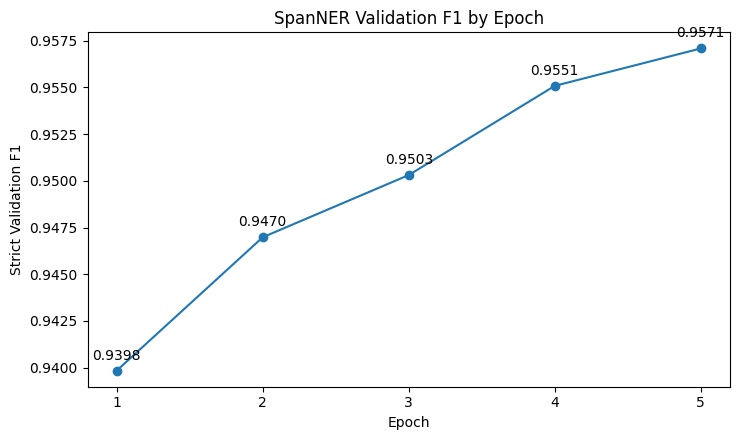

Validation-F1 figure saved: /kaggle/working/02_spanner_baseline_and_uncertainty/figures/validation_f1_by_epoch.png


In [30]:
# Visualise the strict typed-span validation F1 used for
# checkpoint selection across the complete training trajectory.
plt.figure(figsize=(7.5, 4.5))

plt.plot(
    training_history_df["epoch"],
    training_history_df["validation_f1"],
    marker="o",
)

# Annotate each epoch so that small improvements remain visible
# without requiring inspection of the training-history table.
for row in training_history_df.itertuples(index=False):
    plt.annotate(
        f"{row.validation_f1:.4f}",
        (
            row.epoch,
            row.validation_f1,
        ),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
    )

plt.xlabel("Epoch")
plt.ylabel("Strict Validation F1")
plt.title("SpanNER Validation F1 by Epoch")
plt.xticks(
    training_history_df["epoch"]
)
plt.tight_layout()

validation_f1_figure_path = (
    FIGURE_OUTPUT_DIR
    / "validation_f1_by_epoch.png"
)

# Save a publication-quality copy for the final notebook artefacts.
plt.savefig(
    validation_f1_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Validation-F1 figure saved:",
    validation_f1_figure_path,
)

### Training and validation loss

SpanNER training and validation loss by epoch:


,Epoch,Training Loss,Validation Loss
0,1,0.033363,0.017052
1,2,0.009298,0.012510
2,3,0.005518,0.011039
3,4,0.003792,0.010889
4,5,0.002702,0.011226


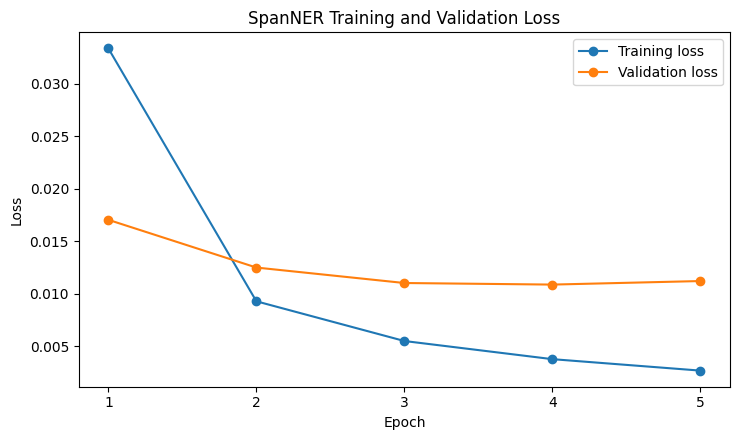

Training-loss figure saved: /kaggle/working/02_spanner_baseline_and_uncertainty/figures/training_validation_loss.png


In [31]:
# Retain only the epoch-level loss quantities needed for the
# convergence visualisation.
loss_curve_df = training_history_df[
    [
        "epoch",
        "training_loss",
        "validation_loss",
    ]
].copy()

loss_curve_df.columns = [
    "Epoch",
    "Training Loss",
    "Validation Loss",
]

print(
    "SpanNER training and validation loss by epoch:"
)
display(
    loss_curve_df.round(6)
)

# Compare optimisation loss with the unweighted validation loss
# recorded after each training epoch.
plt.figure(figsize=(7.5, 4.5))

plt.plot(
    loss_curve_df["Epoch"],
    loss_curve_df["Training Loss"],
    marker="o",
    label="Training loss",
)

plt.plot(
    loss_curve_df["Epoch"],
    loss_curve_df["Validation Loss"],
    marker="o",
    label="Validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SpanNER Training and Validation Loss")
plt.xticks(
    loss_curve_df["Epoch"]
)
plt.legend()
plt.tight_layout()

learning_curve_figure_path = (
    FIGURE_OUTPUT_DIR
    / "training_validation_loss.png"
)

# Save the learning-curve figure as part of the final artefact set.
plt.savefig(
    learning_curve_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Training-loss figure saved:",
    learning_curve_figure_path,
)

### 8.3 Final Model Verification and Freezing

The checkpoint achieving the highest strict typed-span validation F1 is retained as the final deterministic SpanNER model. Before uncertainty extraction, the selected parameters are independently reloaded into a new model instance and the validation result is reproduced.

Following this verification, all learned parameters are frozen. Subsequent deterministic inference and MC-Dropout uncertainty extraction therefore operate on the same selected model without any further parameter updates.


In [32]:
# Re-evaluate the checkpoint restored at the end of training so that
# the final deterministic validation result is recorded explicitly.
selected_validation_metrics = evaluate_spanner_model(
    model=spanner_model,
    dataloader=validation_dataloader,
    split_name="validation",
)

# The restored model should reproduce the validation result stored
# when the best checkpoint was selected.
checkpoint_validation_metrics = best_checkpoint[
    "validation_metrics"
]

for metric_name in [
    "precision",
    "recall",
    "f1",
    "candidate_accuracy",
    "loss",
]:
    if not np.isclose(
        selected_validation_metrics[metric_name],
        checkpoint_validation_metrics[metric_name],
        atol=1e-6,
        rtol=1e-5,
    ):
        raise RuntimeError(
            f"Selected checkpoint does not reproduce {metric_name}."
        )

selected_validation_summary_df = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "Strict F1",
        "Candidate Accuracy",
        "Validation Loss",
        "Predicted Entities",
        "Gold Entities",
    ],
    "Value": [
        selected_validation_metrics["precision"],
        selected_validation_metrics["recall"],
        selected_validation_metrics["f1"],
        selected_validation_metrics["candidate_accuracy"],
        selected_validation_metrics["loss"],
        selected_validation_metrics["predicted_entity_count"],
        selected_validation_metrics["gold_entity_count"],
    ],
})

selected_validation_summary_df.to_csv(
    METRICS_OUTPUT_DIR / "selected_validation_metrics.csv",
    index=False,
)

print("Selected SpanNER validation result:")
display(selected_validation_summary_df.round(6))

Selected SpanNER validation result:


,Metric,Value
0,Precision,0.962391
1,Recall,0.951843
2,Strict F1,0.957088
3,Candidate Accuracy,0.997344
4,Validation Loss,0.011226
5,Predicted Entities,2978.000000
6,Gold Entities,3011.000000


### Save the final model artefact

In [33]:
FINAL_MODEL_PATH = (
    MODEL_DIR / "spanner_model.pt"
)

TOKENIZER_OUTPUT_DIR = (
    MODEL_DIR / "tokenizer"
)

# Store the selected model together with the configuration needed
# to reconstruct the custom SpanNER architecture downstream.
final_model_artifact = {
    "model_state_dict": (
        spanner_model.state_dict()
    ),
    "selected_epoch": int(
        best_epoch
    ),
    "validation_metrics": (
        selected_validation_metrics
    ),
    "architecture_configuration": (
        architecture_configuration
    ),
    "training_configuration": (
        training_configuration
    ),
    "span_label_names": (
        span_label_names
    ),
    "bio_label_names": (
        label_names
    ),
    "model_checkpoint": (
        MODEL_CHECKPOINT
    ),
    "maximum_span_width": int(
        MAX_SPAN_WIDTH
    ),
    "random_seed": int(
        SEED
    ),
}

torch.save(
    final_model_artifact,
    FINAL_MODEL_PATH,
)

# Save the tokenizer configuration used for word-to-subword alignment.
tokenizer.save_pretrained(
    TOKENIZER_OUTPUT_DIR
)

print(
    "Final model saved:",
    FINAL_MODEL_PATH,
)
print(
    "Tokenizer saved:",
    TOKENIZER_OUTPUT_DIR,
)

Final model saved: /kaggle/working/02_spanner_baseline_and_uncertainty/final_model/spanner_model.pt
Tokenizer saved: /kaggle/working/02_spanner_baseline_and_uncertainty/final_model/tokenizer


### Independent reload verification

In [34]:
# Load the saved artefact independently rather than continuing to
# rely on the in-memory model produced during training.
reloaded_artifact = torch.load(
    FINAL_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False,
)

# Reconstruct a fresh SpanNER model using the frozen architecture.
reloaded_spanner_model = BERTSpanNER(
    model_checkpoint=MODEL_CHECKPOINT,
    maximum_span_width=MAX_SPAN_WIDTH,
    number_of_width_buckets=TOKENISED_WIDTH_BUCKETS,
    width_embedding_dim=TOKENISED_WIDTH_EMBEDDING_DIM,
    word_length_embedding_dim=WORD_LENGTH_EMBEDDING_DIM,
    number_of_labels=NUM_SPAN_LABELS,
    classifier_dropout=SPAN_CLASSIFIER_DROPOUT,
).to(DEVICE)

reloaded_spanner_model.load_state_dict(
    reloaded_artifact[
        "model_state_dict"
    ]
)

reloaded_spanner_model.eval()

# Confirm exact parameter preservation across the save/reload boundary.
parameters_identical = all(
    torch.equal(
        spanner_model.state_dict()[name]
        .detach()
        .cpu(),
        reloaded_tensor
        .detach()
        .cpu(),
    )
    for name, reloaded_tensor
    in reloaded_spanner_model.state_dict().items()
)

if not parameters_identical:
    raise RuntimeError(
        "Reloaded SpanNER parameters differ from the selected model."
    )

# Reproduce the deterministic validation result with the independently
# reconstructed model.
reloaded_validation_metrics = evaluate_spanner_model(
    model=reloaded_spanner_model,
    dataloader=validation_dataloader,
    split_name="validation",
)

verification_metrics = [
    "precision",
    "recall",
    "f1",
    "candidate_accuracy",
    "loss",
]

for metric_name in verification_metrics:
    if not np.isclose(
        reloaded_validation_metrics[metric_name],
        selected_validation_metrics[metric_name],
        atol=1e-6,
        rtol=1e-5,
    ):
        raise RuntimeError(
            f"Reloaded model does not reproduce {metric_name}."
        )

reload_verification_df = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "Strict F1",
        "Candidate Accuracy",
        "Validation Loss",
    ],
    "Selected Model": [
        selected_validation_metrics["precision"],
        selected_validation_metrics["recall"],
        selected_validation_metrics["f1"],
        selected_validation_metrics["candidate_accuracy"],
        selected_validation_metrics["loss"],
    ],
    "Reloaded Model": [
        reloaded_validation_metrics["precision"],
        reloaded_validation_metrics["recall"],
        reloaded_validation_metrics["f1"],
        reloaded_validation_metrics["candidate_accuracy"],
        reloaded_validation_metrics["loss"],
    ],
})

print("Saved-model reload verification:")
display(reload_verification_df.round(6))

print(
    "\nParameters preserved exactly:",
    parameters_identical,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Saved-model reload verification:


,Metric,Selected Model,Reloaded Model
0,Precision,0.962391,0.962391
1,Recall,0.951843,0.951843
2,Strict F1,0.957088,0.957088
3,Candidate Accuracy,0.997344,0.997344
4,Validation Loss,0.011226,0.011226



Parameters preserved exactly: True


### Freeze the selected model

In [35]:
# Replace the training model with the independently reloaded copy.
# This model becomes the fixed basis for every subsequent inference step.
spanner_model = reloaded_spanner_model

# Disable gradient computation for all learned parameters. MC Dropout
# later changes dropout behaviour only; it does not update parameters.
for parameter in spanner_model.parameters():
    parameter.requires_grad = False

spanner_model.eval()

if any(
    parameter.requires_grad
    for parameter in spanner_model.parameters()
):
    raise RuntimeError(
        "At least one SpanNER parameter remains trainable."
    )

model_selection_summary = {
    "selected_epoch": int(
        best_epoch
    ),
    "validation_precision": float(
        selected_validation_metrics[
            "precision"
        ]
    ),
    "validation_recall": float(
        selected_validation_metrics[
            "recall"
        ]
    ),
    "validation_f1": float(
        selected_validation_metrics[
            "f1"
        ]
    ),
    "predicted_entities": int(
        selected_validation_metrics[
            "predicted_entity_count"
        ]
    ),
    "gold_entities": int(
        selected_validation_metrics[
            "gold_entity_count"
        ]
    ),
    "parameters_frozen": True,
    "probability_calibration_used_for_selection": False,
    "conformal_calibration_used_for_selection": False,
    "official_test_used": False,
}

with open(
    CONFIG_OUTPUT_DIR / "model_selection_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        model_selection_summary,
        file,
        indent=4,
    )

print("Selected epoch:", best_epoch)
print(
    "Final strict validation F1:",
    f"{selected_validation_metrics['f1']:.6f}",
)
print(
    "Model parameters frozen:",
    True,
)
print(
    "Further parameter updates permitted:",
    False,
)

Selected epoch: 5
Final strict validation F1: 0.957088
Model parameters frozen: True
Further parameter updates permitted: False


## 9. Deterministic Candidate and Span Predictions

The frozen SpanNER model is applied to the validation, probability-calibration and conformal-calibration populations without further parameter updates. For every width-constrained candidate span, the complete five-class logits and softmax probabilities are retained together with deterministic confidence, entropy and probability-margin measures.

Candidate predictions are subsequently passed through the fixed non-overlapping decoder defined during model development. These decoded spans form the deterministic prediction population used for subsequent boundary-competition analysis and MC-Dropout uncertainty extraction.

The outputs generated in this section are model predictions and reusable uncertainty features only. No probability calibration or conformal threshold is fitted in this notebook.


In [36]:
# Construct inference-only DataLoaders for the three development
# populations used after model selection.
inference_datasets = {
    "validation": validation_span_dataset,
    "probability_calibration": (
        probability_calibration_span_dataset
    ),
    "conformal_calibration": (
        conformal_calibration_span_dataset
    ),
}

# Sentence order must remain fixed because the deterministic candidate
# population will later be reused during MC-Dropout aggregation.
inference_dataloaders = {
    split_name: DataLoader(
        dataset=split_dataset,
        batch_size=EVAL_BATCH_SIZE,
        shuffle=False,
        drop_last=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        collate_fn=collate_spanner_batch,
    )
    for split_name, split_dataset
    in inference_datasets.items()
}

inference_loader_summary_df = pd.DataFrame({
    "Population": list(
        inference_dataloaders.keys()
    ),
    "Sentences": [
        len(inference_datasets[split_name])
        for split_name in inference_dataloaders
    ],
    "Batches": [
        len(inference_dataloaders[split_name])
        for split_name in inference_dataloaders
    ],
})

print("Frozen SpanNER inference DataLoaders:")
display(inference_loader_summary_df)

Frozen SpanNER inference DataLoaders:


,Population,Sentences,Batches
0,validation,1625,163
1,probability_calibration,975,98
2,conformal_calibration,650,65


In [37]:
# The maximum entropy of a five-class categorical distribution is
# log(5); this is used to normalise deterministic candidate entropy.
MAXIMUM_SPAN_ENTROPY = float(
    np.log(NUM_SPAN_LABELS)
)


def export_spanner_predictions(
    split_name,
    dataloader,
):
    """
    Run frozen deterministic SpanNER inference and export
    candidate-level and decoded-span predictions.
    """

    # Complete evaluation mode disables all dropout during this
    # deterministic reference pass.
    spanner_model.eval()

    candidate_rows = []
    decoded_rows = []

    predicted_spans_by_sentence = []
    gold_spans_by_sentence_list = []

    total_candidate_loss = 0.0
    total_candidates = 0
    correct_candidates = 0

    with torch.no_grad():
        for batch in tqdm(
            dataloader,
            desc=f"Deterministic inference: {split_name}",
        ):
            (
                model_inputs,
                labels,
                span_mask,
                _,
            ) = move_spanner_batch_to_device(
                batch
            )

            # Generate deterministic logits and five-class probabilities
            # from the frozen SpanNER checkpoint.
            logits = spanner_model(
                **model_inputs
            )

            probabilities = torch.softmax(
                logits,
                dim=-1,
            )

            # Candidate loss remains unweighted outside model fitting.
            batch_loss = compute_span_loss(
                logits=logits,
                labels=labels,
                span_mask=span_mask,
                apply_span_weights=False,
            )

            predictions = probabilities.argmax(
                dim=-1
            )

            real_candidate_count = int(
                span_mask.sum().item()
            )

            total_candidate_loss += (
                batch_loss.item()
                * real_candidate_count
            )

            total_candidates += (
                real_candidate_count
            )

            correct_candidates += int(
                (
                    predictions.eq(labels)
                    & span_mask.bool()
                )
                .sum()
                .item()
            )

            # Candidate rows are exported sentence-by-sentence so that
            # original word boundaries and metadata remain explicit.
            for sentence_position, metadata in enumerate(
                batch["metadata"]
            ):
                candidate_count = int(
                    batch["span_mask"][
                        sentence_position
                    ]
                    .sum()
                    .item()
                )

                sentence_logits = (
                    logits[
                        sentence_position,
                        :candidate_count,
                    ]
                    .detach()
                    .cpu()
                )

                sentence_probabilities = (
                    probabilities[
                        sentence_position,
                        :candidate_count,
                    ]
                    .detach()
                    .cpu()
                )

                sentence_boundaries = (
                    batch[
                        "span_word_indices"
                    ][
                        sentence_position,
                        :candidate_count,
                    ]
                    .detach()
                    .cpu()
                )

                sentence_word_lengths = (
                    batch[
                        "span_word_lengths"
                    ][
                        sentence_position,
                        :candidate_count,
                    ]
                    .detach()
                    .cpu()
                )

                sentence_width_buckets = (
                    batch[
                        "tokenised_width_buckets"
                    ][
                        sentence_position,
                        :candidate_count,
                    ]
                    .detach()
                    .cpu()
                )

                sentence_gold_ids = (
                    batch["labels"][
                        sentence_position,
                        :candidate_count,
                    ]
                    .detach()
                    .cpu()
                )

                sentence_texts = metadata[
                    "candidate_texts"
                ]

                # Shannon entropy summarises uncertainty across all
                # five SpanNER classes.
                candidate_entropy = -(
                    sentence_probabilities
                    * torch.log(
                        sentence_probabilities.clamp_min(
                            1e-12
                        )
                    )
                ).sum(dim=-1)

                # The top-two probability margin provides a second
                # deterministic measure of classification separation.
                top_two_probabilities = torch.topk(
                    sentence_probabilities,
                    k=2,
                    dim=-1,
                ).values

                candidate_margin = (
                    top_two_probabilities[:, 0]
                    - top_two_probabilities[:, 1]
                )

                sentence_predicted_ids = (
                    sentence_probabilities.argmax(
                        dim=-1
                    )
                )

                candidate_lookup = {}

                for candidate_index in range(
                    candidate_count
                ):
                    start, end = (
                        sentence_boundaries[
                            candidate_index
                        ].tolist()
                    )

                    predicted_label_id = int(
                        sentence_predicted_ids[
                            candidate_index
                        ].item()
                    )

                    gold_label_id = int(
                        sentence_gold_ids[
                            candidate_index
                        ].item()
                    )

                    predicted_confidence = float(
                        sentence_probabilities[
                            candidate_index,
                            predicted_label_id,
                        ].item()
                    )

                    # Retain the strongest entity class independently of
                    # NONE. This is important for later candidate-level
                    # calibration and conformal prediction.
                    entity_class_probabilities = (
                        sentence_probabilities[
                            candidate_index,
                            1:,
                        ]
                    )

                    best_entity_relative_id = int(
                        entity_class_probabilities
                        .argmax()
                        .item()
                    )

                    best_entity_label_id = (
                        best_entity_relative_id
                        + 1
                    )

                    best_entity_label = (
                        span_id2label[
                            best_entity_label_id
                        ]
                    )

                    best_entity_probability = float(
                        sentence_probabilities[
                            candidate_index,
                            best_entity_label_id,
                        ].item()
                    )

                    entropy = float(
                        candidate_entropy[
                            candidate_index
                        ].item()
                    )

                    normalised_entropy = (
                        entropy
                        / MAXIMUM_SPAN_ENTROPY
                    )

                    margin = float(
                        candidate_margin[
                            candidate_index
                        ].item()
                    )

                    row = {
                        "split": split_name,
                        "source_index": int(
                            metadata["source_index"]
                        ),
                        "sentence_id": str(
                            metadata["sentence_id"]
                        ),
                        "sentence_index": int(
                            metadata["sentence_index"]
                        ),
                        "sentence_length": int(
                            len(metadata["tokens"])
                        ),
                        "candidate_index": int(
                            candidate_index
                        ),
                        "start": int(start),
                        "end": int(end),
                        "word_length": int(
                            sentence_word_lengths[
                                candidate_index
                            ].item()
                        ),
                        "tokenised_width_bucket": int(
                            sentence_width_buckets[
                                candidate_index
                            ].item()
                        ),
                        "text": str(
                            sentence_texts[
                                candidate_index
                            ]
                        ),
                        "gold_label_id": int(
                            gold_label_id
                        ),
                        "gold_label": str(
                            span_id2label[
                                gold_label_id
                            ]
                        ),
                        "predicted_label_id": int(
                            predicted_label_id
                        ),
                        "predicted_label": str(
                            span_id2label[
                                predicted_label_id
                            ]
                        ),
                        "predicted_confidence": (
                            predicted_confidence
                        ),
                        "maximum_five_class_probability": (
                            predicted_confidence
                        ),
                        "best_entity_label_id": int(
                            best_entity_label_id
                        ),
                        "best_entity_label": str(
                            best_entity_label
                        ),
                        "best_entity_probability": (
                            best_entity_probability
                        ),
                        "entropy": entropy,
                        "normalised_entropy": (
                            normalised_entropy
                        ),
                        "margin": margin,
                        "top_two_probability_margin": (
                            margin
                        ),
                        "confidence_uncertainty": (
                            1.0
                            - predicted_confidence
                        ),
                        "margin_uncertainty": (
                            1.0
                            - margin
                        ),
                        "candidate_correct": bool(
                            predicted_label_id
                            == gold_label_id
                        ),
                        "gold_is_entity": bool(
                            gold_label_id
                            != span_label2id["NONE"]
                        ),
                        "predicted_is_entity": bool(
                            predicted_label_id
                            != span_label2id["NONE"]
                        ),
                    }

                    # Mark candidates that are relevant either because
                    # they are gold entities or because the model predicts
                    # them as entities.
                    row["entity_relevant"] = bool(
                        row["gold_is_entity"]
                        or row[
                            "predicted_is_entity"
                        ]
                    )

                    # Preserve the complete five-class logits and
                    # probabilities for downstream analysis.
                    for (
                        label_id,
                        label_name,
                    ) in enumerate(
                        span_label_names
                    ):
                        row[
                            f"logit_{label_name}"
                        ] = float(
                            sentence_logits[
                                candidate_index,
                                label_id,
                            ].item()
                        )

                        row[
                            f"probability_{label_name}"
                        ] = float(
                            sentence_probabilities[
                                candidate_index,
                                label_id,
                            ].item()
                        )

                    candidate_rows.append(
                        row
                    )

                    candidate_lookup[
                        candidate_index
                    ] = row

                # Apply the same deterministic non-overlapping decoder
                # used during model selection.
                sentence_mask = torch.ones(
                    candidate_count,
                    dtype=torch.bool,
                )

                decoded_spans = (
                    decode_non_overlapping_spans(
                        probabilities=(
                            sentence_probabilities
                        ),
                        span_word_indices=(
                            sentence_boundaries
                        ),
                        span_mask=sentence_mask,
                        candidate_texts=(
                            sentence_texts
                        ),
                    )
                )

                # Record whether each candidate survives deterministic
                # non-overlapping decoding.
                selected_by_candidate_index = {
                    int(
                        span["candidate_index"]
                    ): span
                    for span in decoded_spans
                }

                for (
                    candidate_index,
                    candidate_row,
                ) in candidate_lookup.items():
                    if (
                        candidate_index
                        in selected_by_candidate_index
                    ):
                        selected_span = (
                            selected_by_candidate_index[
                                candidate_index
                            ]
                        )

                        candidate_row[
                            "decoded_selected"
                        ] = True

                        candidate_row[
                            "decoding_rank"
                        ] = int(
                            selected_span[
                                "decoding_rank"
                            ]
                        )

                        candidate_row[
                            "decoding_rejection_reason"
                        ] = "selected"

                    elif (
                        candidate_row[
                            "predicted_label"
                        ]
                        == "NONE"
                    ):
                        candidate_row[
                            "decoded_selected"
                        ] = False

                        candidate_row[
                            "decoding_rank"
                        ] = np.nan

                        candidate_row[
                            "decoding_rejection_reason"
                        ] = "argmax_NONE"

                    else:
                        candidate_row[
                            "decoded_selected"
                        ] = False

                        candidate_row[
                            "decoding_rank"
                        ] = np.nan

                        candidate_row[
                            "decoding_rejection_reason"
                        ] = (
                            "overlap_with_selected_span"
                        )

                predicted_spans_by_sentence.append(
                    decoded_spans
                )

                # Strict evaluation retains all gold entities, including
                # entities that fall outside the width-4 candidate support.
                sentence_gold_spans = (
                    gold_spans_by_sentence.get(
                        (
                            split_name,
                            int(
                                metadata[
                                    "sentence_index"
                                ]
                            ),
                        ),
                        [],
                    )
                )

                gold_spans_by_sentence_list.append(
                    sentence_gold_spans
                )

                # Export the fixed decoded entity population together
                # with deterministic candidate-level uncertainty proxies.
                for decoded_span in decoded_spans:
                    candidate_row = (
                        candidate_lookup[
                            int(
                                decoded_span[
                                    "candidate_index"
                                ]
                            )
                        ]
                    )

                    decoded_rows.append({
                        "split": split_name,
                        "source_index": int(
                            metadata[
                                "source_index"
                            ]
                        ),
                        "sentence_id": str(
                            metadata[
                                "sentence_id"
                            ]
                        ),
                        "sentence_index": int(
                            metadata[
                                "sentence_index"
                            ]
                        ),
                        "sentence_length": int(
                            len(
                                metadata[
                                    "tokens"
                                ]
                            )
                        ),
                        "candidate_index": int(
                            decoded_span[
                                "candidate_index"
                            ]
                        ),
                        "decoding_rank": int(
                            decoded_span[
                                "decoding_rank"
                            ]
                        ),
                        "entity_text": str(
                            decoded_span.get(
                                "text",
                                "",
                            )
                        ),
                        "entity_type": str(
                            decoded_span[
                                "label"
                            ]
                        ),
                        "predicted_label_id": int(
                            decoded_span[
                                "label_id"
                            ]
                        ),
                        "start": int(
                            decoded_span[
                                "start"
                            ]
                        ),
                        "end": int(
                            decoded_span[
                                "end"
                            ]
                        ),
                        "token_count": int(
                            decoded_span[
                                "width"
                            ]
                        ),
                        "span_probability_proxy": float(
                            candidate_row[
                                "predicted_confidence"
                            ]
                        ),
                        "span_entropy_proxy": float(
                            candidate_row[
                                "entropy"
                            ]
                        ),
                        "span_normalised_entropy_proxy": float(
                            candidate_row[
                                "normalised_entropy"
                            ]
                        ),
                        "span_margin_proxy": float(
                            candidate_row[
                                "margin"
                            ]
                        ),
                        "confidence_uncertainty_proxy": float(
                            candidate_row[
                                "confidence_uncertainty"
                            ]
                        ),
                        "margin_uncertainty_proxy": float(
                            candidate_row[
                                "margin_uncertainty"
                            ]
                        ),
                    })

    candidate_df = pd.DataFrame(
        candidate_rows
    )

    decoded_df = pd.DataFrame(
        decoded_rows
    )

    # Calculate strict typed-span metrics from the deterministic
    # decoded entity population.
    strict_metrics = (
        calculate_strict_span_metrics(
            predicted_spans_by_sentence,
            gold_spans_by_sentence_list,
        )
    )

    reference_metrics = {
        **strict_metrics,
        "candidate_count": int(
            total_candidates
        ),
        "candidate_accuracy": float(
            correct_candidates
            / total_candidates
        ),
        "candidate_loss": float(
            total_candidate_loss
            / total_candidates
        ),
        "sentence_count": int(
            len(dataloader.dataset)
        ),
    }

    # Save the complete deterministic outputs required by
    # subsequent calibration and uncertainty notebooks.
    candidate_df.to_csv(
        CANDIDATE_OUTPUT_DIR
        / f"{split_name}_candidate_predictions.csv",
        index=False,
    )

    decoded_df.to_csv(
        SPAN_OUTPUT_DIR
        / f"{split_name}_predicted_spans.csv",
        index=False,
    )

    with open(
        METRICS_OUTPUT_DIR
        / f"{split_name}_reference_metrics.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            reference_metrics,
            file,
            indent=4,
        )

    return (
        candidate_df,
        decoded_df,
        reference_metrics,
    )


print(
    "Frozen deterministic SpanNER prediction export configured."
)

Frozen deterministic SpanNER prediction export configured.


In [38]:
candidate_prediction_tables = {}
predicted_span_tables = {}
reference_metrics_by_split = {}

prediction_summary_records = []
metric_summary_records = []

for split_name in PREDICTION_SPLITS:
    # Run the fixed model once for each predefined development
    # population and retain the resulting artefacts in memory.
    (
        candidate_df,
        decoded_df,
        reference_metrics,
    ) = export_spanner_predictions(
        split_name=split_name,
        dataloader=(
            inference_dataloaders[
                split_name
            ]
        ),
    )

    candidate_prediction_tables[
        split_name
    ] = candidate_df

    predicted_span_tables[
        split_name
    ] = decoded_df

    reference_metrics_by_split[
        split_name
    ] = reference_metrics

    prediction_summary_records.append({
        "Population": split_name,
        "Candidate Rows": int(
            len(candidate_df)
        ),
        "Decoded Entity Spans": int(
            len(decoded_df)
        ),
        "Gold Entity Spans": int(
            len(
                gold_span_tables[
                    split_name
                ]
            )
        ),
    })

    metric_summary_records.append({
        "Population": split_name,
        "Precision": float(
            reference_metrics[
                "precision"
            ]
        ),
        "Recall": float(
            reference_metrics[
                "recall"
            ]
        ),
        "Strict F1": float(
            reference_metrics[
                "f1"
            ]
        ),
        "Candidate Accuracy": float(
            reference_metrics[
                "candidate_accuracy"
            ]
        ),
    })


prediction_output_summary_df = (
    pd.DataFrame(
        prediction_summary_records
    )
)

deterministic_metric_summary_df = (
    pd.DataFrame(
        metric_summary_records
    )
)

# Candidate row counts should reproduce the candidate universes
# calculated before model fitting.
expected_candidate_counts = {
    row["Population"]: int(
        row["Total Candidates"]
    )
    for _, row
    in candidate_population_df.iterrows()
}

for split_name in PREDICTION_SPLITS:
    if (
        len(
            candidate_prediction_tables[
                split_name
            ]
        )
        != expected_candidate_counts[
            split_name
        ]
    ):
        raise RuntimeError(
            f"Candidate population changed during "
            f"inference for {split_name}."
        )

# The deterministic validation result must remain identical to
# the verified frozen checkpoint result.
if not np.isclose(
    reference_metrics_by_split[
        "validation"
    ]["f1"],
    selected_validation_metrics[
        "f1"
    ],
    atol=1e-6,
    rtol=1e-5,
):
    raise RuntimeError(
        "Frozen deterministic validation F1 changed "
        "during prediction export."
    )

prediction_output_summary_df.to_csv(
    METRICS_OUTPUT_DIR
    / "deterministic_prediction_summary.csv",
    index=False,
)

deterministic_metric_summary_df.to_csv(
    METRICS_OUTPUT_DIR
    / "deterministic_metric_summary.csv",
    index=False,
)

print("Saved deterministic SpanNER outputs:")
display(
    prediction_output_summary_df
)

print("\nDeterministic strict-span performance:")
display(
    deterministic_metric_summary_df.round(6)
)

print(
    "\nProbability calibration fitted:",
    False,
)
print(
    "Conformal threshold fitted:",
    False,
)
print(
    "Official test processed:",
    False,
)

Deterministic inference: validation:   0%|          | 0/163 [00:00<?, ?it/s]

Deterministic inference: probability_calibration:   0%|          | 0/98 [00:00<?, ?it/s]

Deterministic inference: conformal_calibration:   0%|          | 0/65 [00:00<?, ?it/s]

Saved deterministic SpanNER outputs:


,Population,Candidate Rows,Decoded Entity Spans,Gold Entity Spans
0,validation,94497,2978,3011
1,probability_calibration,57126,1760,1756
2,conformal_calibration,34635,1170,1175



Deterministic strict-span performance:


,Population,Precision,Recall,Strict F1,Candidate Accuracy
0,validation,0.962391,0.951843,0.957088,0.997344
1,probability_calibration,0.935795,0.937927,0.936860,0.996481
2,conformal_calibration,0.950427,0.946383,0.948401,0.996911



Probability calibration fitted: False
Conformal threshold fitted: False
Official test processed: False


## 10. Deterministic Boundary-Competition Signals

SpanNER predicts complete candidate spans directly, so boundary uncertainty is derived from competition between neighbouring candidates of the selected entity type.

For a decoded entity with start boundary \(s\), end boundary \(e\), and selected-type probability \(p_{\mathrm{sel}}\):

* a **start-boundary competitor** has the same end boundary \(e\) but a different start boundary;
* an **end-boundary competitor** has the same start boundary \(s\) but a different end boundary.

For each boundary, the strongest competitor is the alternative candidate with the highest probability for the selected entity type. Boundary-competition strength is then defined as

$$
u_s =
\frac{p^{\mathrm{alt}}_s}
     {p_{\mathrm{sel}} + p^{\mathrm{alt}}_s + \epsilon}
$$

and

$$
u_e =
\frac{p^{\mathrm{alt}}_e}
     {p_{\mathrm{sel}} + p^{\mathrm{alt}}_e + \epsilon},
$$

where \(\epsilon = 10^{-12}\) provides numerical stability.

Higher values indicate stronger local competition around the corresponding boundary. These quantities are architecture-specific uncertainty signals and should not be interpreted as calibrated probabilities that a boundary is incorrect.


In [39]:
# A small constant prevents division by zero when both candidate
# probabilities are extremely small.
BOUNDARY_EPSILON = 1e-12


def calculate_boundary_competition(
    split_name,
    candidate_df,
    decoded_df,
):
    """
    Derive start- and end-boundary competition for each
    deterministically decoded SpanNER entity.
    """

    competition_rows = []

    # Group the complete candidate universe by sentence so that
    # alternative boundaries can be retrieved efficiently.
    candidates_by_sentence = {
        int(sentence_index): group.copy()
        for sentence_index, group
        in candidate_df.groupby(
            "sentence_index",
            sort=False,
        )
    }

    for prediction in decoded_df.to_dict(
        "records"
    ):
        sentence_index = int(
            prediction["sentence_index"]
        )

        predicted_start = int(
            prediction["start"]
        )

        predicted_end = int(
            prediction["end"]
        )

        predicted_label = str(
            prediction["entity_type"]
        )

        # The selected probability is the deterministic probability
        # assigned to the decoded entity type for this candidate.
        selected_probability = float(
            prediction[
                "span_probability_proxy"
            ]
        )

        # Competing candidates are compared using evidence for the
        # same entity type as the decoded prediction.
        probability_column = (
            f"probability_{predicted_label}"
        )

        sentence_candidates = (
            candidates_by_sentence[
                sentence_index
            ]
        )

        # Start competitors preserve the selected end boundary
        # while proposing a different start boundary.
        start_competitors = (
            sentence_candidates[
                sentence_candidates["end"].eq(
                    predicted_end
                )
                & ~sentence_candidates[
                    "start"
                ].eq(
                    predicted_start
                )
            ]
        )

        # End competitors preserve the selected start boundary
        # while proposing a different end boundary.
        end_competitors = (
            sentence_candidates[
                sentence_candidates["start"].eq(
                    predicted_start
                )
                & ~sentence_candidates[
                    "end"
                ].eq(
                    predicted_end
                )
            ]
        )

        if len(start_competitors) > 0:
            # Retain the alternative start with the strongest
            # probability for the selected entity type.
            best_start_index = (
                start_competitors[
                    probability_column
                ].idxmax()
            )

            best_start_row = (
                start_competitors.loc[
                    best_start_index
                ]
            )

            start_competitor_probability = float(
                best_start_row[
                    probability_column
                ]
            )

            # The raw gap is retained alongside the normalised
            # boundary-competition signal.
            start_boundary_gap = (
                selected_probability
                - start_competitor_probability
            )

            start_boundary_uncertainty = (
                start_competitor_probability
                / (
                    selected_probability
                    + start_competitor_probability
                    + BOUNDARY_EPSILON
                )
            )

            start_competitor_candidate_index = int(
                best_start_row[
                    "candidate_index"
                ]
            )

            start_competitor_start = int(
                best_start_row["start"]
            )

        else:
            # No alternative start exists within the width-4
            # candidate support for this decoded entity.
            start_competitor_probability = np.nan
            start_boundary_gap = np.nan
            start_boundary_uncertainty = np.nan
            start_competitor_candidate_index = np.nan
            start_competitor_start = np.nan

        if len(end_competitors) > 0:
            # Retain the alternative end with the strongest
            # probability for the selected entity type.
            best_end_index = (
                end_competitors[
                    probability_column
                ].idxmax()
            )

            best_end_row = (
                end_competitors.loc[
                    best_end_index
                ]
            )

            end_competitor_probability = float(
                best_end_row[
                    probability_column
                ]
            )

            end_boundary_gap = (
                selected_probability
                - end_competitor_probability
            )

            end_boundary_uncertainty = (
                end_competitor_probability
                / (
                    selected_probability
                    + end_competitor_probability
                    + BOUNDARY_EPSILON
                )
            )

            end_competitor_candidate_index = int(
                best_end_row[
                    "candidate_index"
                ]
            )

            end_competitor_end = int(
                best_end_row["end"]
            )

        else:
            # No alternative end exists within the width-4
            # candidate support for this decoded entity.
            end_competitor_probability = np.nan
            end_boundary_gap = np.nan
            end_boundary_uncertainty = np.nan
            end_competitor_candidate_index = np.nan
            end_competitor_end = np.nan

        # Retain one combined descriptor for analyses that require
        # the stronger of the two available boundary signals.
        available_uncertainties = [
            value
            for value in [
                start_boundary_uncertainty,
                end_boundary_uncertainty,
            ]
            if pd.notna(value)
        ]

        strongest_boundary_uncertainty = (
            max(available_uncertainties)
            if available_uncertainties
            else np.nan
        )

        competition_rows.append({
            "split": split_name,
            "source_index": int(
                prediction[
                    "source_index"
                ]
            ),
            "sentence_id": str(
                prediction[
                    "sentence_id"
                ]
            ),
            "sentence_index": int(
                sentence_index
            ),
            "candidate_index": int(
                prediction[
                    "candidate_index"
                ]
            ),
            "selected_start": int(
                predicted_start
            ),
            "selected_end": int(
                predicted_end
            ),
            "predicted_label": (
                predicted_label
            ),
            "selected_probability": (
                selected_probability
            ),
            "has_start_competitor": bool(
                pd.notna(
                    start_competitor_probability
                )
            ),
            "start_competitor_candidate_index": (
                start_competitor_candidate_index
            ),
            "start_competitor_start": (
                start_competitor_start
            ),
            "start_competitor_probability": (
                start_competitor_probability
            ),
            "start_boundary_gap": (
                start_boundary_gap
            ),
            "start_boundary_competition_uncertainty": (
                start_boundary_uncertainty
            ),
            "has_end_competitor": bool(
                pd.notna(
                    end_competitor_probability
                )
            ),
            "end_competitor_candidate_index": (
                end_competitor_candidate_index
            ),
            "end_competitor_end": (
                end_competitor_end
            ),
            "end_competitor_probability": (
                end_competitor_probability
            ),
            "end_boundary_gap": (
                end_boundary_gap
            ),
            "end_boundary_competition_uncertainty": (
                end_boundary_uncertainty
            ),
            "strongest_boundary_competition_uncertainty": (
                strongest_boundary_uncertainty
            ),
        })

    return pd.DataFrame(
        competition_rows
    )


print(
    "Deterministic boundary-competition extraction configured."
)

Deterministic boundary-competition extraction configured.


### Generate and save boundary signals

In [40]:
boundary_competition_tables = {}
boundary_summary_records = []

for split_name in PREDICTION_SPLITS:
    # Derive candidate-local boundary competition for the fixed
    # deterministic decoded-span population.
    competition_df = (
        calculate_boundary_competition(
            split_name=split_name,
            candidate_df=(
                candidate_prediction_tables[
                    split_name
                ]
            ),
            decoded_df=(
                predicted_span_tables[
                    split_name
                ]
            ),
        )
    )

    boundary_competition_tables[
        split_name
    ] = competition_df

    # Save the boundary-specific table as an independent
    # downstream artefact.
    competition_df.to_csv(
        BOUNDARY_OUTPUT_DIR
        / f"{split_name}_boundary_competition.csv",
        index=False,
    )

    # Attach the deterministic boundary signals to each decoded
    # span while preserving the fixed span population.
    enriched_predicted_spans = (
        predicted_span_tables[
            split_name
        ].merge(
            competition_df,
            on=[
                "split",
                "source_index",
                "sentence_id",
                "sentence_index",
                "candidate_index",
            ],
            how="left",
            validate="one_to_one",
        )
    )

    if (
        len(enriched_predicted_spans)
        != len(
            predicted_span_tables[
                split_name
            ]
        )
    ):
        raise RuntimeError(
            f"Decoded-span population changed while "
            f"adding boundary signals for {split_name}."
        )

    predicted_span_tables[
        split_name
    ] = enriched_predicted_spans

    # Replace the earlier decoded-span file with the same fixed
    # predictions enriched by boundary-competition features.
    enriched_predicted_spans.to_csv(
        SPAN_OUTPUT_DIR
        / f"{split_name}_predicted_spans.csv",
        index=False,
    )

    boundary_summary_records.append({
        "Population": split_name,
        "Decoded Entities": int(
            len(competition_df)
        ),
        "Start Competitor Available": int(
            competition_df[
                "has_start_competitor"
            ].sum()
        ),
        "End Competitor Available": int(
            competition_df[
                "has_end_competitor"
            ].sum()
        ),
        "Mean Start Competition": float(
            competition_df[
                "start_boundary_competition_uncertainty"
            ].mean()
        ),
        "Mean End Competition": float(
            competition_df[
                "end_boundary_competition_uncertainty"
            ].mean()
        ),
    })


# Retain one combined boundary table for convenient downstream use.
all_boundary_competition_df = pd.concat(
    [
        boundary_competition_tables[
            split_name
        ]
        for split_name
        in PREDICTION_SPLITS
    ],
    ignore_index=True,
)

all_boundary_competition_df.to_csv(
    BOUNDARY_OUTPUT_DIR
    / "all_boundary_competition.csv",
    index=False,
)

boundary_competition_summary_df = pd.DataFrame(
    boundary_summary_records
)

boundary_competition_summary_df.to_csv(
    METRICS_OUTPUT_DIR
    / "deterministic_boundary_competition_summary.csv",
    index=False,
)

print(
    "Deterministic SpanNER boundary-competition summary:"
)

display(
    boundary_competition_summary_df.round(6)
)

print(
    "\nBoundary-competition signals calibrated:",
    False,
)

Deterministic SpanNER boundary-competition summary:


,Population,Decoded Entities,Start Competitor Available,End Competitor Available,Mean Start Competition,Mean End Competition
0,validation,2978,2470,2946,0.022488,0.016048
1,probability_calibration,1760,1467,1741,0.022003,0.017461
2,conformal_calibration,1170,975,1157,0.020516,0.016432



Boundary-competition signals calibrated: False


## 11. Prediction-to-Gold Matching and Boundary-Correctness Events

Decoded predictions are matched one-to-one with gold entities within each sentence to support boundary-specific error analysis. Matching is performed hierarchically: exact typed-span matches are assigned first, followed by predictions with identical boundaries but an incorrect entity type. Remaining overlapping spans are then paired deterministically, prioritising matching entity types, greater token overlap, higher intersection-over-union and smaller boundary distance.

For each matched prediction, start-boundary correctness, end-boundary correctness, joint-boundary correctness and entity-type correctness are recorded separately. Predictions without a matched gold entity are labelled as false positives, while unmatched gold entities are labelled as false negatives.

Boundary-correctness labels are defined only for matched prediction–gold pairs. Unmatched false-positive predictions are therefore not assigned artificial start- or end-boundary correctness values.


In [41]:
def calculate_overlap_features(
    predicted_span,
    gold_span,
):
    """Calculate overlap and boundary-distance features for one span pair."""

    predicted_start = int(
        predicted_span["start"]
    )
    predicted_end = int(
        predicted_span["end"]
    )

    gold_start = int(
        gold_span["start"]
    )
    gold_end = int(
        gold_span["end"]
    )

    # Count the number of original-word positions shared by the
    # predicted and gold spans.
    overlap_tokens = max(
        0,
        min(predicted_end, gold_end)
        - max(predicted_start, gold_start)
        + 1,
    )

    predicted_length = (
        predicted_end
        - predicted_start
        + 1
    )

    gold_length = (
        gold_end
        - gold_start
        + 1
    )

    union_tokens = (
        predicted_length
        + gold_length
        - overlap_tokens
    )

    overlap_iou = (
        overlap_tokens / union_tokens
        if union_tokens > 0
        else 0.0
    )

    # Boundary distance measures total displacement of the two
    # predicted endpoints from the corresponding gold endpoints.
    boundary_distance = (
        abs(predicted_start - gold_start)
        + abs(predicted_end - gold_end)
    )

    # Retain a descriptive overlap relation for later error analysis.
    if (
        predicted_start == gold_start
        and predicted_end == gold_end
    ):
        overlap_relation = "exact"

    elif (
        predicted_start >= gold_start
        and predicted_end <= gold_end
        and overlap_tokens > 0
    ):
        overlap_relation = (
            "prediction_inside_gold"
        )

    elif (
        gold_start >= predicted_start
        and gold_end <= predicted_end
        and overlap_tokens > 0
    ):
        overlap_relation = (
            "gold_inside_prediction"
        )

    elif (
        predicted_start < gold_start
        <= predicted_end < gold_end
    ):
        overlap_relation = (
            "left_partial_overlap"
        )

    elif (
        gold_start < predicted_start
        <= gold_end < predicted_end
    ):
        overlap_relation = (
            "right_partial_overlap"
        )

    else:
        overlap_relation = "none"

    return {
        "overlap_tokens": int(
            overlap_tokens
        ),
        "overlap_iou": float(
            overlap_iou
        ),
        "boundary_distance": int(
            boundary_distance
        ),
        "overlap_relation": (
            overlap_relation
        ),
    }


def determine_matched_error_category(
    predicted_span,
    gold_span,
):
    """Assign the primary error category for a matched span pair."""

    start_correct = (
        int(predicted_span["start"])
        == int(gold_span["start"])
    )

    end_correct = (
        int(predicted_span["end"])
        == int(gold_span["end"])
    )

    type_correct = (
        str(predicted_span["entity_type"])
        == str(gold_span["entity_type"])
    )

    if (
        start_correct
        and end_correct
        and type_correct
    ):
        return "exact_match"

    if (
        start_correct
        and end_correct
        and not type_correct
    ):
        return "type_error"

    if (
        not start_correct
        and end_correct
    ):
        return "start_boundary_error"

    if (
        start_correct
        and not end_correct
    ):
        return "end_boundary_error"

    return "both_boundary_error"


print("SpanNER matching utilities configured.")

SpanNER matching utilities configured.


### One-to-one sentence matcher

In [42]:
# Prediction-side quantities retained in the matching table so that
# correctness events can later be joined directly to uncertainty signals.
MATCHING_PREDICTION_COLUMNS = [
    "span_probability_proxy",
    "span_entropy_proxy",
    "span_normalised_entropy_proxy",
    "span_margin_proxy",
    "confidence_uncertainty_proxy",
    "margin_uncertainty_proxy",
    "selected_probability",
    "start_boundary_gap",
    "start_boundary_competition_uncertainty",
    "end_boundary_gap",
    "end_boundary_competition_uncertainty",
    "strongest_boundary_competition_uncertainty",
]


def match_sentence_spans(
    predicted_spans,
    gold_spans,
    split_name,
    source_index,
    sentence_id,
    sentence_index,
):
    """Match decoded predictions and gold entities one-to-one within a sentence."""

    predicted_spans = [
        dict(span)
        for span in predicted_spans
    ]

    gold_spans = [
        dict(span)
        for span in gold_spans
    ]

    unmatched_prediction_indices = set(
        range(len(predicted_spans))
    )

    unmatched_gold_indices = set(
        range(len(gold_spans))
    )

    matched_pairs = []

    # First assign exact typed-span matches. These correspond directly
    # to true positives under strict NER evaluation.
    for prediction_index in sorted(
        unmatched_prediction_indices.copy()
    ):
        predicted_span = predicted_spans[
            prediction_index
        ]

        possible_gold_matches = [
            gold_index
            for gold_index in sorted(
                unmatched_gold_indices
            )
            if (
                int(predicted_span["start"])
                == int(
                    gold_spans[
                        gold_index
                    ]["start"]
                )
                and int(
                    predicted_span["end"]
                )
                == int(
                    gold_spans[
                        gold_index
                    ]["end"]
                )
                and str(
                    predicted_span[
                        "entity_type"
                    ]
                )
                == str(
                    gold_spans[
                        gold_index
                    ]["entity_type"]
                )
            )
        ]

        if possible_gold_matches:
            gold_index = (
                possible_gold_matches[0]
            )

            matched_pairs.append(
                (
                    prediction_index,
                    gold_index,
                )
            )

            unmatched_prediction_indices.remove(
                prediction_index
            )

            unmatched_gold_indices.remove(
                gold_index
            )

    # Next pair identical boundaries with a different entity type.
    # This separates pure type errors from boundary errors.
    for prediction_index in sorted(
        unmatched_prediction_indices.copy()
    ):
        predicted_span = predicted_spans[
            prediction_index
        ]

        possible_gold_matches = [
            gold_index
            for gold_index in sorted(
                unmatched_gold_indices
            )
            if (
                int(predicted_span["start"])
                == int(
                    gold_spans[
                        gold_index
                    ]["start"]
                )
                and int(
                    predicted_span["end"]
                )
                == int(
                    gold_spans[
                        gold_index
                    ]["end"]
                )
                and str(
                    predicted_span[
                        "entity_type"
                    ]
                )
                != str(
                    gold_spans[
                        gold_index
                    ]["entity_type"]
                )
            )
        ]

        if possible_gold_matches:
            gold_index = (
                possible_gold_matches[0]
            )

            matched_pairs.append(
                (
                    prediction_index,
                    gold_index,
                )
            )

            unmatched_prediction_indices.remove(
                prediction_index
            )

            unmatched_gold_indices.remove(
                gold_index
            )

    # Construct all remaining prediction–gold pairs with at least
    # one overlapping original-word position.
    overlap_candidates = []

    for prediction_index in (
        unmatched_prediction_indices
    ):
        predicted_span = predicted_spans[
            prediction_index
        ]

        for gold_index in (
            unmatched_gold_indices
        ):
            gold_span = gold_spans[
                gold_index
            ]

            overlap_features = (
                calculate_overlap_features(
                    predicted_span,
                    gold_span,
                )
            )

            if (
                overlap_features[
                    "overlap_tokens"
                ]
                == 0
            ):
                continue

            type_match = (
                str(
                    predicted_span[
                        "entity_type"
                    ]
                )
                == str(
                    gold_span[
                        "entity_type"
                    ]
                )
            )

            overlap_candidates.append({
                "prediction_index": (
                    prediction_index
                ),
                "gold_index": (
                    gold_index
                ),
                "type_match": (
                    type_match
                ),
                **overlap_features,
            })

    # Prefer same-type matches, then larger overlap, larger IoU and
    # finally smaller boundary displacement. Position provides a
    # deterministic tie-break when all other quantities are equal.
    overlap_candidates.sort(
        key=lambda candidate: (
            -int(
                candidate[
                    "type_match"
                ]
            ),
            -candidate[
                "overlap_tokens"
            ],
            -candidate[
                "overlap_iou"
            ],
            candidate[
                "boundary_distance"
            ],
            candidate[
                "prediction_index"
            ],
            candidate[
                "gold_index"
            ],
        )
    )

    for candidate in overlap_candidates:
        prediction_index = candidate[
            "prediction_index"
        ]
        gold_index = candidate[
            "gold_index"
        ]

        # Earlier assignments have priority, so already-used spans
        # cannot participate in another pair.
        if (
            prediction_index
            not in unmatched_prediction_indices
            or gold_index
            not in unmatched_gold_indices
        ):
            continue

        matched_pairs.append(
            (
                prediction_index,
                gold_index,
            )
        )

        unmatched_prediction_indices.remove(
            prediction_index
        )

        unmatched_gold_indices.remove(
            gold_index
        )

    matching_rows = []
    match_counter = 0

    # Materialise matched prediction–gold pairs and derive separate
    # start, end, type and exact correctness events.
    for (
        prediction_index,
        gold_index,
    ) in matched_pairs:
        match_counter += 1

        predicted_span = (
            predicted_spans[
                prediction_index
            ]
        )

        gold_span = gold_spans[
            gold_index
        ]

        overlap_features = (
            calculate_overlap_features(
                predicted_span,
                gold_span,
            )
        )

        start_correct = (
            int(
                predicted_span[
                    "start"
                ]
            )
            == int(
                gold_span["start"]
            )
        )

        end_correct = (
            int(
                predicted_span[
                    "end"
                ]
            )
            == int(
                gold_span["end"]
            )
        )

        type_correct = (
            str(
                predicted_span[
                    "entity_type"
                ]
            )
            == str(
                gold_span[
                    "entity_type"
                ]
            )
        )

        exact_correct = (
            start_correct
            and end_correct
            and type_correct
        )

        error_category = (
            determine_matched_error_category(
                predicted_span,
                gold_span,
            )
        )

        matching_row = {
            "split": split_name,
            "source_index": int(
                source_index
            ),
            "sentence_id": str(
                sentence_id
            ),
            "sentence_index": int(
                sentence_index
            ),
            "match_id": (
                f"{split_name}_"
                f"{sentence_index}_"
                f"{match_counter}"
            ),
            "row_source": (
                "matched_pair"
            ),
            "error_category": (
                error_category
            ),
            "predicted_candidate_index": int(
                predicted_span[
                    "candidate_index"
                ]
            ),
            "predicted_decoding_rank": int(
                predicted_span[
                    "decoding_rank"
                ]
            ),
            "predicted_entity_text": str(
                predicted_span[
                    "entity_text"
                ]
            ),
            "predicted_entity_type": str(
                predicted_span[
                    "entity_type"
                ]
            ),
            "predicted_start": int(
                predicted_span["start"]
            ),
            "predicted_end": int(
                predicted_span["end"]
            ),
            "gold_entity_text": str(
                gold_span[
                    "entity_text"
                ]
            ),
            "gold_entity_type": str(
                gold_span[
                    "entity_type"
                ]
            ),
            "gold_start": int(
                gold_span["start"]
            ),
            "gold_end": int(
                gold_span["end"]
            ),
            "start_offset": int(
                predicted_span["start"]
                - gold_span["start"]
            ),
            "end_offset": int(
                predicted_span["end"]
                - gold_span["end"]
            ),
            **overlap_features,
            "is_start_correct": bool(
                start_correct
            ),
            "is_end_correct": bool(
                end_correct
            ),
            "is_type_correct": bool(
                type_correct
            ),
            "is_boundary_correct": bool(
                start_correct
                and end_correct
            ),
            "is_exact_correct": bool(
                exact_correct
            ),
            "is_any_error": bool(
                not exact_correct
            ),
        }

        # Copy deterministic confidence and boundary-competition
        # features from the selected prediction.
        for column_name in (
            MATCHING_PREDICTION_COLUMNS
        ):
            matching_row[
                column_name
            ] = predicted_span.get(
                column_name,
                np.nan,
            )

        matching_rows.append(
            matching_row
        )

    # Predictions with no suitable gold partner remain genuine
    # false positives. Boundary correctness is undefined for them.
    for prediction_index in sorted(
        unmatched_prediction_indices
    ):
        match_counter += 1

        predicted_span = (
            predicted_spans[
                prediction_index
            ]
        )

        matching_row = {
            "split": split_name,
            "source_index": int(
                source_index
            ),
            "sentence_id": str(
                sentence_id
            ),
            "sentence_index": int(
                sentence_index
            ),
            "match_id": (
                f"{split_name}_"
                f"{sentence_index}_"
                f"{match_counter}"
            ),
            "row_source": (
                "unmatched_prediction"
            ),
            "error_category": (
                "false_positive"
            ),
            "predicted_candidate_index": int(
                predicted_span[
                    "candidate_index"
                ]
            ),
            "predicted_decoding_rank": int(
                predicted_span[
                    "decoding_rank"
                ]
            ),
            "predicted_entity_text": str(
                predicted_span[
                    "entity_text"
                ]
            ),
            "predicted_entity_type": str(
                predicted_span[
                    "entity_type"
                ]
            ),
            "predicted_start": int(
                predicted_span["start"]
            ),
            "predicted_end": int(
                predicted_span["end"]
            ),
            "gold_entity_text": None,
            "gold_entity_type": None,
            "gold_start": np.nan,
            "gold_end": np.nan,
            "start_offset": np.nan,
            "end_offset": np.nan,
            "overlap_tokens": 0,
            "overlap_iou": 0.0,
            "boundary_distance": np.nan,
            "overlap_relation": "none",
            "is_start_correct": pd.NA,
            "is_end_correct": pd.NA,
            "is_type_correct": pd.NA,
            "is_boundary_correct": pd.NA,
            "is_exact_correct": False,
            "is_any_error": True,
        }

        for column_name in (
            MATCHING_PREDICTION_COLUMNS
        ):
            matching_row[
                column_name
            ] = predicted_span.get(
                column_name,
                np.nan,
            )

        matching_rows.append(
            matching_row
        )

    # Gold entities left without a prediction are false negatives
    # and have no associated prediction-side uncertainty features.
    for gold_index in sorted(
        unmatched_gold_indices
    ):
        match_counter += 1

        gold_span = gold_spans[
            gold_index
        ]

        matching_row = {
            "split": split_name,
            "source_index": int(
                source_index
            ),
            "sentence_id": str(
                sentence_id
            ),
            "sentence_index": int(
                sentence_index
            ),
            "match_id": (
                f"{split_name}_"
                f"{sentence_index}_"
                f"{match_counter}"
            ),
            "row_source": (
                "unmatched_gold"
            ),
            "error_category": (
                "false_negative"
            ),
            "predicted_candidate_index": np.nan,
            "predicted_decoding_rank": np.nan,
            "predicted_entity_text": None,
            "predicted_entity_type": None,
            "predicted_start": np.nan,
            "predicted_end": np.nan,
            "gold_entity_text": str(
                gold_span[
                    "entity_text"
                ]
            ),
            "gold_entity_type": str(
                gold_span[
                    "entity_type"
                ]
            ),
            "gold_start": int(
                gold_span["start"]
            ),
            "gold_end": int(
                gold_span["end"]
            ),
            "start_offset": np.nan,
            "end_offset": np.nan,
            "overlap_tokens": 0,
            "overlap_iou": 0.0,
            "boundary_distance": np.nan,
            "overlap_relation": "none",
            "is_start_correct": pd.NA,
            "is_end_correct": pd.NA,
            "is_type_correct": pd.NA,
            "is_boundary_correct": pd.NA,
            "is_exact_correct": False,
            "is_any_error": True,
        }

        for column_name in (
            MATCHING_PREDICTION_COLUMNS
        ):
            matching_row[
                column_name
            ] = np.nan

        matching_rows.append(
            matching_row
        )

    return matching_rows


print(
    "Deterministic one-to-one SpanNER sentence matcher configured."
)

Deterministic one-to-one SpanNER sentence matcher configured.


### Construct matching tables

In [43]:
matching_tables = {}
matching_summary_records = []

for split_name in PREDICTION_SPLITS:
    split_prediction_df = (
        predicted_span_tables[
            split_name
        ]
    )

    split_gold_df = (
        gold_span_tables[
            split_name
        ]
    )

    # Group predictions and gold spans once so that each sentence
    # can be matched independently.
    prediction_groups = {
        int(sentence_index): (
            group.to_dict(
                "records"
            )
        )
        for sentence_index, group
        in split_prediction_df.groupby(
            "sentence_index",
            sort=False,
        )
    }

    gold_groups = {
        int(sentence_index): (
            group.to_dict(
                "records"
            )
        )
        for sentence_index, group
        in split_gold_df.groupby(
            "sentence_index",
            sort=False,
        )
    }

    split_matching_rows = []

    for (
        sentence_index,
        example,
    ) in enumerate(
        dataset_splits[
            split_name
        ]
    ):
        split_matching_rows.extend(
            match_sentence_spans(
                predicted_spans=(
                    prediction_groups.get(
                        sentence_index,
                        [],
                    )
                ),
                gold_spans=(
                    gold_groups.get(
                        sentence_index,
                        [],
                    )
                ),
                split_name=split_name,
                source_index=int(
                    example[
                        "source_index"
                    ]
                ),
                sentence_id=str(
                    example["id"]
                ),
                sentence_index=int(
                    sentence_index
                ),
            )
        )

    matching_df = pd.DataFrame(
        split_matching_rows
    )

    # Use nullable Boolean values so false positives and false
    # negatives can retain undefined boundary-correctness labels.
    for boolean_column in [
        "is_start_correct",
        "is_end_correct",
        "is_type_correct",
        "is_boundary_correct",
        "is_exact_correct",
        "is_any_error",
    ]:
        matching_df[
            boolean_column
        ] = matching_df[
            boolean_column
        ].astype("boolean")

    matching_tables[
        split_name
    ] = matching_df

    matching_df.to_csv(
        MATCHING_OUTPUT_DIR
        / f"{split_name}_prediction_gold_matching.csv",
        index=False,
    )

    matching_summary_records.append({
        "Population": split_name,
        "Matched Pairs": int(
            (
                matching_df[
                    "row_source"
                ]
                == "matched_pair"
            ).sum()
        ),
        "False Positives": int(
            (
                matching_df[
                    "row_source"
                ]
                == "unmatched_prediction"
            ).sum()
        ),
        "False Negatives": int(
            (
                matching_df[
                    "row_source"
                ]
                == "unmatched_gold"
            ).sum()
        ),
    })


matching_summary_df = pd.DataFrame(
    matching_summary_records
)

print(
    "SpanNER prediction-to-gold matching summary:"
)
display(matching_summary_df)

SpanNER prediction-to-gold matching summary:


,Population,Matched Pairs,False Positives,False Negatives
0,validation,2953,25,58
1,probability_calibration,1729,31,27
2,conformal_calibration,1157,13,18


### 11.1 Validation Error Profile

The validation matching table is used to summarise the principal SpanNER error categories. This decomposition distinguishes errors caused by entity type, start-boundary placement, end-boundary placement and simultaneous displacement of both boundaries, while retaining unmatched false positives and false negatives as separate categories.


In [44]:
error_category_order = [
    "exact_match",
    "type_error",
    "start_boundary_error",
    "end_boundary_error",
    "both_boundary_error",
    "false_positive",
    "false_negative",
]

validation_matching_df = (
    matching_tables[
        "validation"
    ]
)

# Summarise the mutually exclusive primary error categories
# produced by the one-to-one matching procedure.
validation_error_summary_df = (
    validation_matching_df[
        "error_category"
    ]
    .value_counts()
    .reindex(
        error_category_order,
        fill_value=0,
    )
    .rename_axis(
        "Error Category"
    )
    .reset_index(
        name="Count"
    )
)

validation_error_summary_df.to_csv(
    METRICS_OUTPUT_DIR
    / "validation_error_summary.csv",
    index=False,
)

print(
    "SpanNER validation error categories:"
)
display(
    validation_error_summary_df
)

SpanNER validation error categories:


,Error Category,Count
0,exact_match,2866
1,type_error,59
2,start_boundary_error,14
3,end_boundary_error,13
4,both_boundary_error,1
5,false_positive,25
6,false_negative,58


### Visualise validation errors

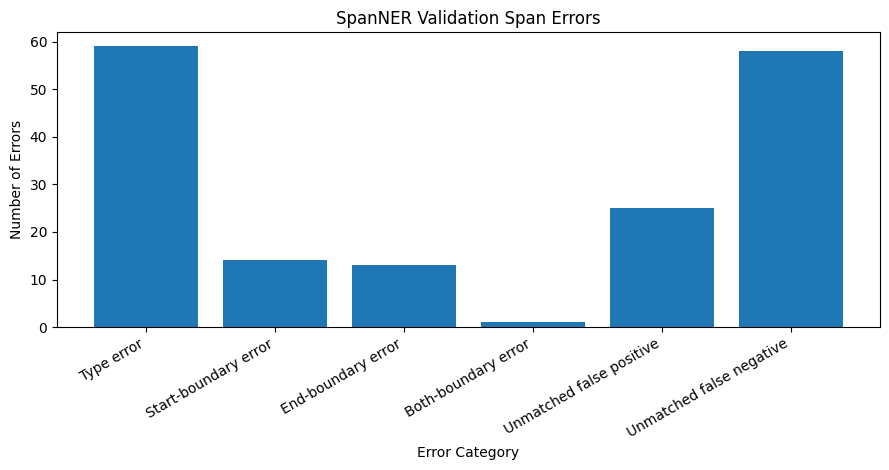

Validation-error figure saved: /kaggle/working/02_spanner_baseline_and_uncertainty/figures/validation_span_error_distribution.png


In [45]:
# Exclude exact matches so that the figure focuses exclusively
# on the distribution of model errors.
error_plot_df = (
    validation_error_summary_df[
        validation_error_summary_df[
            "Error Category"
        ]
        != "exact_match"
    ]
    .copy()
)

error_display_names = {
    "type_error": "Type error",
    "start_boundary_error": (
        "Start-boundary error"
    ),
    "end_boundary_error": (
        "End-boundary error"
    ),
    "both_boundary_error": (
        "Both-boundary error"
    ),
    "false_positive": (
        "Unmatched false positive"
    ),
    "false_negative": (
        "Unmatched false negative"
    ),
}

error_plot_df[
    "Display Category"
] = error_plot_df[
    "Error Category"
].map(
    error_display_names
)

plt.figure(
    figsize=(9, 4.8)
)

plt.bar(
    error_plot_df[
        "Display Category"
    ],
    error_plot_df[
        "Count"
    ],
)

plt.ylabel(
    "Number of Errors"
)
plt.xlabel(
    "Error Category"
)
plt.title(
    "SpanNER Validation Span Errors"
)

plt.xticks(
    rotation=30,
    ha="right",
)

plt.tight_layout()

span_error_figure_path = (
    FIGURE_OUTPUT_DIR
    / "validation_span_error_distribution.png"
)

# Save a high-resolution copy with the remaining notebook figures.
plt.savefig(
    span_error_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Validation-error figure saved:",
    span_error_figure_path,
)

### 11.2 Validation Performance by Entity Type

Strict typed-span performance is also examined separately for the four CoNLL-2003 entity categories. For each entity type, a true positive requires exact agreement in start boundary, end boundary and entity type. This analysis identifies whether model performance is distributed consistently across entity categories or concentrated within particular classes.


In [46]:
entity_type_metric_records = []

for entity_type in entity_types:
    # Count every decoded prediction assigned to this entity type,
    # including incorrect predictions and unmatched false positives.
    predicted_type_count = int(
        (
            validation_matching_df[
                "predicted_entity_type"
            ]
            == entity_type
        ).sum()
    )

    # Count every gold entity of this type, including unmatched
    # false negatives.
    gold_type_count = int(
        (
            validation_matching_df[
                "gold_entity_type"
            ]
            == entity_type
        ).sum()
    )

    # Strict true positives require exact boundaries and type.
    true_positive_type_count = int(
        (
            (
                validation_matching_df[
                    "error_category"
                ]
                == "exact_match"
            )
            & (
                validation_matching_df[
                    "predicted_entity_type"
                ]
                == entity_type
            )
        ).sum()
    )

    type_precision = (
        true_positive_type_count
        / predicted_type_count
        if predicted_type_count > 0
        else 0.0
    )

    type_recall = (
        true_positive_type_count
        / gold_type_count
        if gold_type_count > 0
        else 0.0
    )

    type_f1 = (
        2
        * type_precision
        * type_recall
        / (
            type_precision
            + type_recall
        )
        if (
            type_precision
            + type_recall
            > 0
        )
        else 0.0
    )

    entity_type_metric_records.append({
        "Entity Type": entity_type,
        "Gold Entities": gold_type_count,
        "Predicted Entities": predicted_type_count,
        "True Positives": true_positive_type_count,
        "Precision": type_precision,
        "Recall": type_recall,
        "F1": type_f1,
    })


entity_type_metrics_df = pd.DataFrame(
    entity_type_metric_records
)

# Retain the validation breakdown as part of the model-analysis outputs.
entity_type_metrics_df.to_csv(
    METRICS_OUTPUT_DIR
    / "validation_entity_type_metrics.csv",
    index=False,
)

print(
    "SpanNER validation metrics by entity type:"
)
display(
    entity_type_metrics_df.round(4)
)

SpanNER validation metrics by entity type:


,Entity Type,Gold Entities,Predicted Entities,True Positives,Precision,Recall,F1
0,PER,969,970,948,0.9773,0.9783,0.9778
1,ORG,690,684,644,0.9415,0.9333,0.9374
2,LOC,898,888,868,0.9775,0.9666,0.9720
3,MISC,454,436,406,0.9312,0.8943,0.9124


### Entity-type F1 figure

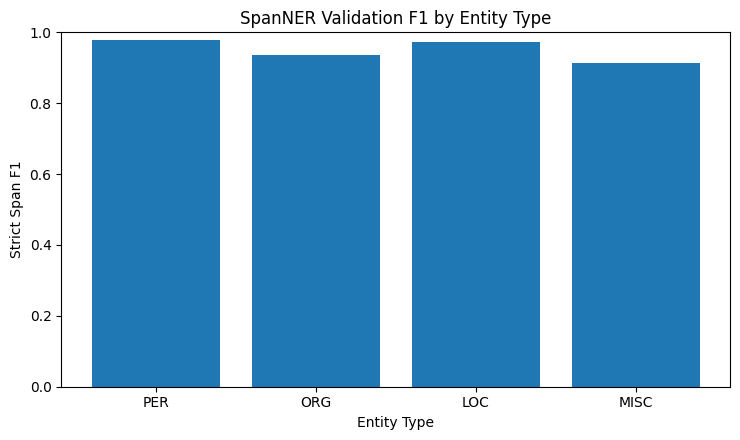

Entity-type figure saved: /kaggle/working/02_spanner_baseline_and_uncertainty/figures/validation_f1_by_entity_type.png


In [47]:
# Visualise strict F1 for each of the four CoNLL-2003 entity types.
plt.figure(figsize=(7.5, 4.5))

plt.bar(
    entity_type_metrics_df[
        "Entity Type"
    ],
    entity_type_metrics_df[
        "F1"
    ],
)

plt.ylim(0, 1.0)
plt.xlabel("Entity Type")
plt.ylabel("Strict Span F1")
plt.title(
    "SpanNER Validation F1 by Entity Type"
)
plt.tight_layout()

entity_type_figure_path = (
    FIGURE_OUTPUT_DIR
    / "validation_f1_by_entity_type.png"
)

# Save a high-resolution copy with the final notebook figures.
plt.savefig(
    entity_type_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Entity-type figure saved:",
    entity_type_figure_path,
)

### 11.3 Validation Performance by Entity Length

Performance is additionally summarised according to entity length in original words. Lengths from one to four words correspond to the representable SpanNER candidate space, while entities of five or more words form a separate structurally unrepresentable group.

This analysis makes the effect of the fixed width-four candidate support explicit rather than excluding longer gold entities from evaluation.


In [48]:
def assign_span_length_group(length):
    """Map an entity length to the displayed validation length group."""

    length = int(length)

    if length <= MAX_SPAN_WIDTH:
        return str(length)

    return "5+"


# Prediction-side rows contain every decoded entity, including
# unmatched false positives.
validation_prediction_side_df = (
    validation_matching_df[
        validation_matching_df[
            "predicted_start"
        ].notna()
    ].copy()
)

# Gold-side rows contain every annotated entity, including
# unmatched false negatives.
validation_gold_side_df = (
    validation_matching_df[
        validation_matching_df[
            "gold_start"
        ].notna()
    ].copy()
)

validation_prediction_side_df[
    "predicted_span_length"
] = (
    validation_prediction_side_df[
        "predicted_end"
    ].astype(int)
    - validation_prediction_side_df[
        "predicted_start"
    ].astype(int)
    + 1
)

validation_gold_side_df[
    "gold_span_length"
] = (
    validation_gold_side_df[
        "gold_end"
    ].astype(int)
    - validation_gold_side_df[
        "gold_start"
    ].astype(int)
    + 1
)

validation_prediction_side_df[
    "span_length_group"
] = validation_prediction_side_df[
    "predicted_span_length"
].apply(
    assign_span_length_group
)

validation_gold_side_df[
    "span_length_group"
] = validation_gold_side_df[
    "gold_span_length"
].apply(
    assign_span_length_group
)


span_length_records = []

for span_length_group in [
    "1",
    "2",
    "3",
    "4",
    "5+",
]:
    # Predicted counts are grouped by the decoded entity length.
    predicted_count = int(
        (
            validation_prediction_side_df[
                "span_length_group"
            ]
            == span_length_group
        ).sum()
    )

    # Gold counts retain all annotated entities, including those
    # outside the width-four candidate support.
    gold_count = int(
        (
            validation_gold_side_df[
                "span_length_group"
            ]
            == span_length_group
        ).sum()
    )

    # For an exact match, predicted and gold lengths are necessarily
    # identical, so the gold-side group can identify strict TPs.
    true_positive_count = int(
        (
            (
                validation_gold_side_df[
                    "span_length_group"
                ]
                == span_length_group
            )
            & (
                validation_gold_side_df[
                    "error_category"
                ]
                == "exact_match"
            )
        ).sum()
    )

    precision = (
        true_positive_count
        / predicted_count
        if predicted_count > 0
        else np.nan
    )

    recall = (
        true_positive_count
        / gold_count
        if gold_count > 0
        else np.nan
    )

    if (
        predicted_count > 0
        and gold_count > 0
        and precision + recall > 0
    ):
        f1 = (
            2
            * precision
            * recall
            / (precision + recall)
        )

    elif gold_count > 0:
        f1 = 0.0

    else:
        f1 = np.nan

    span_length_records.append({
        "Span Length": span_length_group,
        "Representable by Width 4": (
            span_length_group != "5+"
        ),
        "Gold Entities": gold_count,
        "Predicted Entities": predicted_count,
        "True Positives": true_positive_count,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
    })


span_length_metrics_df = pd.DataFrame(
    span_length_records
)

span_length_metrics_df.to_csv(
    METRICS_OUTPUT_DIR
    / "validation_span_length_metrics.csv",
    index=False,
)

print(
    "SpanNER validation performance by entity length:"
)
display(
    span_length_metrics_df.round(4)
)

SpanNER validation performance by entity length:


,Span Length,Representable by Width 4,Gold Entities,Predicted Entities,True Positives,Precision,Recall,F1
0,1,True,1882,1868,1796,0.9615,0.9543,0.9579
1,2,True,949,952,930,0.9769,0.9800,0.9784
2,3,True,108,110,95,0.8636,0.8796,0.8716
3,4,True,54,48,45,0.9375,0.8333,0.8824
4,5+,False,18,0,0,NaN,0.0000,0.0000


### Recall by entity length

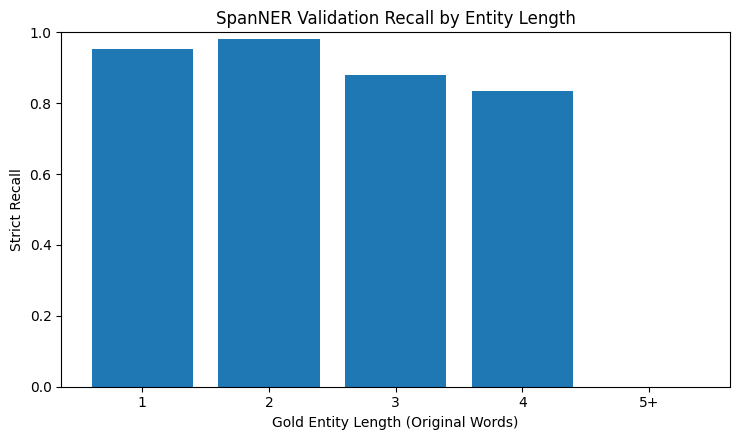

Span-length figure saved: /kaggle/working/02_spanner_baseline_and_uncertainty/figures/validation_recall_by_span_length.png


In [49]:
# Recall is the most direct quantity for showing the effect of
# representational support on gold entities of different lengths.
plt.figure(figsize=(7.5, 4.5))

plt.bar(
    span_length_metrics_df[
        "Span Length"
    ],
    span_length_metrics_df[
        "Recall"
    ],
)

plt.ylim(0, 1.0)
plt.xlabel(
    "Gold Entity Length (Original Words)"
)
plt.ylabel("Strict Recall")
plt.title(
    "SpanNER Validation Recall by Entity Length"
)
plt.tight_layout()

span_length_figure_path = (
    FIGURE_OUTPUT_DIR
    / "validation_recall_by_span_length.png"
)

# Save the figure for the final notebook artefact set.
plt.savefig(
    span_length_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Span-length figure saved:",
    span_length_figure_path,
)

### 11.4 Prediction-Side and Gold-Side Analysis Views

The one-to-one matching output is separated into prediction-side and gold-side views for subsequent uncertainty analysis. The prediction-side view contains every decoded entity prediction, including unmatched false positives, while the gold-side view contains every annotated entity, including unmatched false negatives.

This separation allows uncertainty features to remain associated with model predictions without altering the gold entity population used for recall-oriented analyses.


In [50]:
prediction_side_tables = {}
gold_side_tables = {}

analysis_view_summary_records = []

for split_name in PREDICTION_SPLITS:
    matching_df = matching_tables[
        split_name
    ].copy()

    # Every row with a predicted span belongs to the prediction-side
    # population, including unmatched false positives.
    prediction_side_df = matching_df[
        matching_df[
            "predicted_start"
        ].notna()
    ].copy()

    # Every row with a gold span belongs to the gold-side population,
    # including unmatched false negatives.
    gold_side_df = matching_df[
        matching_df[
            "gold_start"
        ].notna()
    ].copy()

    # Retain explicit span lengths because later uncertainty and
    # error analyses may stratify results by entity width.
    prediction_side_df[
        "predicted_token_count"
    ] = (
        prediction_side_df[
            "predicted_end"
        ].astype(int)
        - prediction_side_df[
            "predicted_start"
        ].astype(int)
        + 1
    )

    gold_side_df[
        "gold_token_count"
    ] = (
        gold_side_df[
            "gold_end"
        ].astype(int)
        - gold_side_df[
            "gold_start"
        ].astype(int)
        + 1
    )

    prediction_side_tables[
        split_name
    ] = prediction_side_df

    gold_side_tables[
        split_name
    ] = gold_side_df

    # Save both views for downstream uncertainty and calibration stages.
    prediction_side_df.to_csv(
        MATCHING_OUTPUT_DIR
        / f"{split_name}_prediction_side.csv",
        index=False,
    )

    gold_side_df.to_csv(
        MATCHING_OUTPUT_DIR
        / f"{split_name}_gold_side.csv",
        index=False,
    )

    analysis_view_summary_records.append({
        "Population": split_name,
        "Prediction-Side Rows": int(
            len(prediction_side_df)
        ),
        "Gold-Side Rows": int(
            len(gold_side_df)
        ),
    })


analysis_view_summary_df = pd.DataFrame(
    analysis_view_summary_records
)

print("SpanNER analysis populations:")
display(analysis_view_summary_df)

SpanNER analysis populations:


,Population,Prediction-Side Rows,Gold-Side Rows
0,validation,2978,3011
1,probability_calibration,1760,1756
2,conformal_calibration,1170,1175


## 12. Monte Carlo Dropout Uncertainty Extraction

Monte Carlo Dropout is used to derive stochastic uncertainty features from the frozen SpanNER model. Ten stochastic forward passes are performed for each development population using seeds 42–51. All learned parameters remain frozen and gradients are disabled throughout.

The complete model is retained in evaluation mode, with only `torch.nn.Dropout` modules temporarily reactivated during stochastic inference. This preserves deterministic behaviour for non-dropout components while allowing variation in the BERT and span-classifier dropout layers.

MC-Dropout outputs are calculated over the existing deterministic candidate population. Candidate labels and decoded entity spans are not redefined from the MC-mean probabilities, and the non-overlapping decoder is not rerun. Mutual information is interpreted as a stochastic model-disagreement measure rather than as a calibrated probability of epistemic uncertainty.


In [51]:
mc_candidate_order_records = []

for split_name in PREDICTION_SPLITS:
    candidate_df = (
        candidate_prediction_tables[
            split_name
        ]
        .reset_index(drop=True)
    )

    # Candidate rows must progress through sentences in their original
    # inference order because MC aggregation uses the same DataLoader order.
    observed_sentence_order = (
        candidate_df[
            "sentence_index"
        ]
        .drop_duplicates()
        .astype(int)
        .tolist()
    )

    expected_sentence_order = list(
        range(
            len(
                dataset_splits[
                    split_name
                ]
            )
        )
    )

    sentence_order_correct = (
        observed_sentence_order
        == expected_sentence_order
    )

    candidate_order_correct = True

    # Within each sentence, candidate indices must remain the exact
    # enumeration order produced by the width-4 candidate generator.
    for _, sentence_group in candidate_df.groupby(
        "sentence_index",
        sort=False,
    ):
        observed_candidate_indices = (
            sentence_group[
                "candidate_index"
            ]
            .astype(int)
            .tolist()
        )

        expected_candidate_indices = list(
            range(
                len(sentence_group)
            )
        )

        if (
            observed_candidate_indices
            != expected_candidate_indices
        ):
            candidate_order_correct = False
            break

    mc_candidate_order_records.append({
        "Population": split_name,
        "Sentence Order Verified": (
            sentence_order_correct
        ),
        "Candidate Order Verified": (
            candidate_order_correct
        ),
    })


mc_candidate_order_df = pd.DataFrame(
    mc_candidate_order_records
)

if not (
    mc_candidate_order_df[
        [
            "Sentence Order Verified",
            "Candidate Order Verified",
        ]
    ]
    .to_numpy()
    .all()
):
    raise RuntimeError(
        "Deterministic candidate ordering is not suitable "
        "for MC-Dropout aggregation."
    )

print(
    "Candidate ordering for stochastic aggregation:"
)
display(mc_candidate_order_df)

Candidate ordering for stochastic aggregation:


,Population,Sentence Order Verified,Candidate Order Verified
0,validation,True,True
1,probability_calibration,True,True
2,conformal_calibration,True,True


### Configure dropout-only stochastic inference

In [52]:
def set_complete_evaluation_mode(model):
    """Return the complete model to deterministic evaluation mode."""

    model.eval()


def enable_mc_dropout_only(model):
    """
    Keep the parent model in evaluation mode while activating
    only torch.nn.Dropout modules.
    """

    # Evaluation mode is applied first so that all non-dropout
    # components retain deterministic inference behaviour.
    model.eval()

    activated_module_names = []

    for module_name, module in model.named_modules():
        if isinstance(module, nn.Dropout):
            module.train()
            activated_module_names.append(
                module_name
            )

    return activated_module_names


# Summarise dropout probabilities without printing every individual
# transformer dropout module into the final notebook.
dropout_records = []

for module_name, module in (
    spanner_model.named_modules()
):
    if isinstance(module, nn.Dropout):
        dropout_records.append({
            "Module": module_name,
            "Dropout Probability": float(
                module.p
            ),
        })


dropout_module_df = pd.DataFrame(
    dropout_records
)

if len(dropout_module_df) == 0:
    raise RuntimeError(
        "No dropout modules were found in the frozen SpanNER model."
    )

dropout_summary_df = (
    dropout_module_df[
        "Dropout Probability"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "Dropout Probability"
    )
    .reset_index(
        name="Number of Modules"
    )
)

print(
    "SpanNER dropout configuration:"
)
display(dropout_summary_df)

SpanNER dropout configuration:


,Dropout Probability,Number of Modules
0,0.1,37
1,0.2,1


### MC-Dropout aggregation

In [53]:
MC_EPSILON = 1e-12

# Use one deterministic seed for each stochastic forward pass.
MC_PASS_SEEDS = [
    SEED + pass_index
    for pass_index in range(
        MC_DROPOUT_PASSES
    )
]


def run_mc_dropout_aggregation(
    split_name,
):
    """
    Aggregate candidate-level MC-Dropout probabilities over
    the fixed deterministic candidate population.
    """

    candidate_df = (
        candidate_prediction_tables[
            split_name
        ]
        .reset_index(drop=True)
    )

    total_candidates = len(
        candidate_df
    )

    number_of_classes = len(
        span_label_names
    )

    # Deterministic labels remain the reference labels throughout
    # stochastic uncertainty extraction.
    deterministic_label_ids = (
        pd.to_numeric(
            candidate_df[
                "predicted_label_id"
            ],
            errors="raise",
        )
        .astype(int)
        .to_numpy()
    )

    # Running sums avoid storing all ten full probability tensors.
    probability_sum = np.zeros(
        (
            total_candidates,
            number_of_classes,
        ),
        dtype=np.float64,
    )

    probability_square_sum = (
        np.zeros_like(
            probability_sum
        )
    )

    entropy_sum = np.zeros(
        total_candidates,
        dtype=np.float64,
    )

    vote_counts = np.zeros(
        (
            total_candidates,
            number_of_classes,
        ),
        dtype=np.int16,
    )

    pass_seconds = []

    # Activate only dropout layers while keeping the parent model
    # and all non-dropout modules in evaluation mode.
    activated_dropout_modules = (
        enable_mc_dropout_only(
            spanner_model
        )
    )

    if spanner_model.training:
        raise RuntimeError(
            "The parent SpanNER model must remain in evaluation mode."
        )

    if not all(
        module.training
        for module in spanner_model.modules()
        if isinstance(
            module,
            nn.Dropout,
        )
    ):
        raise RuntimeError(
            "At least one dropout module was not activated."
        )

    for (
        pass_index,
        pass_seed,
    ) in enumerate(
        MC_PASS_SEEDS
    ):
        # Re-seed every stochastic pass so that the complete
        # MC experiment can be reproduced exactly.
        random.seed(
            pass_seed
        )

        np.random.seed(
            pass_seed
        )

        torch.manual_seed(
            pass_seed
        )

        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(
                pass_seed
            )

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        pass_start_time = (
            time.perf_counter()
        )

        candidate_cursor = 0

        with torch.no_grad():
            for batch in (
                inference_dataloaders[
                    split_name
                ]
            ):
                # Only model inputs are transferred to the GPU.
                model_inputs = {
                    "input_ids": (
                        batch[
                            "input_ids"
                        ].to(DEVICE)
                    ),
                    "attention_mask": (
                        batch[
                            "attention_mask"
                        ].to(DEVICE)
                    ),
                    "token_type_ids": (
                        batch[
                            "token_type_ids"
                        ].to(DEVICE)
                    ),
                    "span_subword_indices": (
                        batch[
                            "span_subword_indices"
                        ].to(DEVICE)
                    ),
                    "span_word_lengths": (
                        batch[
                            "span_word_lengths"
                        ].to(DEVICE)
                    ),
                    "tokenised_width_buckets": (
                        batch[
                            "tokenised_width_buckets"
                        ].to(DEVICE)
                    ),
                }

                logits = spanner_model(
                    **model_inputs
                )

                # Convert logits to full five-class probabilities
                # before transferring the stochastic output to CPU.
                batch_probabilities = (
                    torch.softmax(
                        logits.float(),
                        dim=-1,
                    )
                    .cpu()
                )

                batch_predictions = (
                    batch_probabilities.argmax(
                        dim=-1
                    )
                )

                # Entropy is calculated independently for every
                # stochastic pass before averaging across passes.
                batch_entropy = -torch.sum(
                    batch_probabilities
                    * torch.log(
                        batch_probabilities.clamp_min(
                            MC_EPSILON
                        )
                    ),
                    dim=-1,
                )

                for (
                    sentence_position,
                    _
                ) in enumerate(
                    batch[
                        "metadata"
                    ]
                ):
                    candidate_count = int(
                        batch[
                            "span_mask"
                        ][
                            sentence_position
                        ]
                        .sum()
                        .item()
                    )

                    row_slice = slice(
                        candidate_cursor,
                        (
                            candidate_cursor
                            + candidate_count
                        ),
                    )

                    row_probabilities = (
                        batch_probabilities[
                            sentence_position,
                            :candidate_count,
                        ]
                        .numpy()
                        .astype(
                            np.float64
                        )
                    )

                    row_predictions = (
                        batch_predictions[
                            sentence_position,
                            :candidate_count,
                        ]
                        .numpy()
                        .astype(
                            np.int16
                        )
                    )

                    row_entropy = (
                        batch_entropy[
                            sentence_position,
                            :candidate_count,
                        ]
                        .numpy()
                        .astype(
                            np.float64
                        )
                    )

                    # Accumulate first and second probability moments
                    # for each fixed candidate.
                    probability_sum[
                        row_slice
                    ] += (
                        row_probabilities
                    )

                    probability_square_sum[
                        row_slice
                    ] += np.square(
                        row_probabilities
                    )

                    entropy_sum[
                        row_slice
                    ] += row_entropy

                    global_candidate_indices = (
                        np.arange(
                            candidate_cursor,
                            (
                                candidate_cursor
                                + candidate_count
                            ),
                        )
                    )

                    # Count the class receiving the stochastic argmax
                    # in each pass for vote-based uncertainty measures.
                    vote_counts[
                        global_candidate_indices,
                        row_predictions,
                    ] += 1

                    candidate_cursor += (
                        candidate_count
                    )

        if (
            candidate_cursor
            != total_candidates
        ):
            raise RuntimeError(
                f"MC candidate count changed for {split_name}."
            )

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        elapsed_seconds = (
            time.perf_counter()
            - pass_start_time
        )

        pass_seconds.append(
            float(
                elapsed_seconds
            )
        )

        print(
            f"{split_name}: MC pass "
            f"{pass_index + 1}/"
            f"{MC_DROPOUT_PASSES} completed"
        )

    # Calculate the first and second probability moments across
    # the ten stochastic forward passes.
    mean_probabilities = (
        probability_sum
        / MC_DROPOUT_PASSES
    )

    mean_squared_probabilities = (
        probability_square_sum
        / MC_DROPOUT_PASSES
    )

    class_probability_variance = (
        np.maximum(
            mean_squared_probabilities
            - np.square(
                mean_probabilities
            ),
            0.0,
        )
    )

    # Predictive entropy is calculated from the MC-mean distribution.
    predictive_entropy = -np.sum(
        mean_probabilities
        * np.log(
            np.clip(
                mean_probabilities,
                MC_EPSILON,
                1.0,
            )
        ),
        axis=-1,
    )

    # Expected entropy averages the entropy within individual
    # stochastic passes.
    expected_entropy = (
        entropy_sum
        / MC_DROPOUT_PASSES
    )

    # Mutual information captures disagreement between stochastic
    # model realisations.
    mutual_information = np.maximum(
        predictive_entropy
        - expected_entropy,
        0.0,
    )

    normalised_predictive_entropy = (
        predictive_entropy
        / MAXIMUM_SPAN_ENTROPY
    )

    normalised_expected_entropy = (
        expected_entropy
        / MAXIMUM_SPAN_ENTROPY
    )

    normalised_mutual_information = (
        mutual_information
        / MAXIMUM_SPAN_ENTROPY
    )

    row_indices = np.arange(
        total_candidates
    )

    # Extract MC statistics specifically for the deterministic
    # candidate label without redefining that label.
    fixed_label_mean_probability = (
        mean_probabilities[
            row_indices,
            deterministic_label_ids,
        ]
    )

    fixed_label_probability_variance = (
        class_probability_variance[
            row_indices,
            deterministic_label_ids,
        ]
    )

    fixed_label_vote_fraction = (
        vote_counts[
            row_indices,
            deterministic_label_ids,
        ]
        / MC_DROPOUT_PASSES
    )

    maximum_vote_fraction = (
        vote_counts.max(
            axis=-1
        )
        / MC_DROPOUT_PASSES
    )

    variation_ratio = (
        1.0
        - maximum_vote_fraction
    )

    # MC-mean argmax is retained only as a descriptive stability
    # measure and does not replace the deterministic label.
    mean_argmax_ids = np.argmax(
        mean_probabilities,
        axis=-1,
    ).astype(
        np.int16
    )

    sorted_mean_probabilities = (
        np.sort(
            mean_probabilities,
            axis=-1,
        )
    )

    mean_probability_margin = (
        sorted_mean_probabilities[
            :,
            -1,
        ]
        - sorted_mean_probabilities[
            :,
            -2,
        ]
    )

    mean_argmax_disagreement = (
        mean_argmax_ids
        != deterministic_label_ids
    )

    # These checks confirm numerical validity of the stochastic
    # summaries without imposing expected performance values.
    if not np.allclose(
        mean_probabilities.sum(
            axis=-1
        ),
        1.0,
        atol=1e-5,
    ):
        raise RuntimeError(
            "MC-mean probabilities do not sum to one."
        )

    if np.any(
        mutual_information < 0.0
    ):
        raise RuntimeError(
            "Negative mutual information encountered."
        )

    # Return the full model to deterministic inference mode before
    # leaving the stochastic extraction function.
    set_complete_evaluation_mode(
        spanner_model
    )

    return {
        "mean_probabilities": (
            mean_probabilities.astype(
                np.float32
            )
        ),
        "class_probability_variance": (
            class_probability_variance.astype(
                np.float32
            )
        ),
        "predictive_entropy": (
            predictive_entropy.astype(
                np.float32
            )
        ),
        "expected_entropy": (
            expected_entropy.astype(
                np.float32
            )
        ),
        "mutual_information": (
            mutual_information.astype(
                np.float32
            )
        ),
        "normalised_predictive_entropy": (
            normalised_predictive_entropy.astype(
                np.float32
            )
        ),
        "normalised_expected_entropy": (
            normalised_expected_entropy.astype(
                np.float32
            )
        ),
        "normalised_mutual_information": (
            normalised_mutual_information.astype(
                np.float32
            )
        ),
        "fixed_label_mean_probability": (
            fixed_label_mean_probability.astype(
                np.float32
            )
        ),
        "fixed_label_probability_variance": (
            fixed_label_probability_variance.astype(
                np.float32
            )
        ),
        "fixed_label_vote_fraction": (
            fixed_label_vote_fraction.astype(
                np.float32
            )
        ),
        "variation_ratio": (
            variation_ratio.astype(
                np.float32
            )
        ),
        "mean_argmax_ids": (
            mean_argmax_ids
        ),
        "mean_probability_margin": (
            mean_probability_margin.astype(
                np.float32
            )
        ),
        "mean_argmax_disagreement": (
            mean_argmax_disagreement
        ),
        "vote_counts": vote_counts,
        "pass_seconds": (
            pass_seconds
        ),
        "activated_dropout_modules": (
            activated_dropout_modules
        ),
    }


print(
    "Candidate-level MC-Dropout aggregation configured."
)
print(
    "MC pass seeds:",
    MC_PASS_SEEDS,
)

Candidate-level MC-Dropout aggregation configured.
MC pass seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]


### Run the ten-pass MC experiment

In [54]:
mc_results = {}
mc_runtime = {}
mc_summary_records = []

for split_name in PREDICTION_SPLITS:
    # Run ten stochastic forward passes over the fixed candidate
    # population without decoding new entity spans.
    result = run_mc_dropout_aggregation(
        split_name
    )

    mc_results[
        split_name
    ] = result

    # Save compact numerical arrays separately from the CSV tables
    # that will be constructed in the next section.
    mc_array_path = (
        MC_ARRAY_OUTPUT_DIR
        / f"{split_name}_mc_candidate_summary.npz"
    )

    np.savez_compressed(
        mc_array_path,
        mean_probabilities=(
            result[
                "mean_probabilities"
            ]
        ),
        class_probability_variance=(
            result[
                "class_probability_variance"
            ]
        ),
        predictive_entropy=(
            result[
                "predictive_entropy"
            ]
        ),
        expected_entropy=(
            result[
                "expected_entropy"
            ]
        ),
        mutual_information=(
            result[
                "mutual_information"
            ]
        ),
        normalised_predictive_entropy=(
            result[
                "normalised_predictive_entropy"
            ]
        ),
        normalised_expected_entropy=(
            result[
                "normalised_expected_entropy"
            ]
        ),
        normalised_mutual_information=(
            result[
                "normalised_mutual_information"
            ]
        ),
        fixed_label_mean_probability=(
            result[
                "fixed_label_mean_probability"
            ]
        ),
        fixed_label_probability_variance=(
            result[
                "fixed_label_probability_variance"
            ]
        ),
        fixed_label_vote_fraction=(
            result[
                "fixed_label_vote_fraction"
            ]
        ),
        variation_ratio=(
            result[
                "variation_ratio"
            ]
        ),
        mean_argmax_ids=(
            result[
                "mean_argmax_ids"
            ]
        ),
        mean_probability_margin=(
            result[
                "mean_probability_margin"
            ]
        ),
        vote_counts=(
            result[
                "vote_counts"
            ]
        ),
    )

    mc_runtime[
        split_name
    ] = {
        "mc_passes": int(
            MC_DROPOUT_PASSES
        ),
        "pass_seeds": (
            MC_PASS_SEEDS
        ),
        "pass_seconds": (
            result[
                "pass_seconds"
            ]
        ),
        "total_seconds": float(
            sum(
                result[
                    "pass_seconds"
                ]
            )
        ),
        "mean_seconds_per_pass": float(
            np.mean(
                result[
                    "pass_seconds"
                ]
            )
        ),
        "candidate_rows": int(
            len(
                candidate_prediction_tables[
                    split_name
                ]
            )
        ),
    }

    disagreement_count = int(
        result[
            "mean_argmax_disagreement"
        ].sum()
    )

    mc_summary_records.append({
        "Population": split_name,
        "Candidate Rows": int(
            len(
                candidate_prediction_tables[
                    split_name
                ]
            )
        ),
        "MC Passes": int(
            MC_DROPOUT_PASSES
        ),
        "Mean Predictive Entropy": float(
            result[
                "predictive_entropy"
            ].mean()
        ),
        "Mean Mutual Information": float(
            result[
                "mutual_information"
            ].mean()
        ),
        "Mean Fixed-Label Vote Fraction": float(
            result[
                "fixed_label_vote_fraction"
            ].mean()
        ),
        "MC-Mean Argmax Disagreements": (
            disagreement_count
        ),
    })


with open(
    RUNTIME_OUTPUT_DIR
    / "mc_dropout_runtime.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        mc_runtime,
        file,
        indent=4,
    )


mc_summary_df = pd.DataFrame(
    mc_summary_records
)

mc_summary_df.to_csv(
    METRICS_OUTPUT_DIR
    / "candidate_mc_dropout_summary.csv",
    index=False,
)

print(
    "SpanNER candidate-level MC-Dropout summary:"
)
display(
    mc_summary_df.round(6)
)

print(
    "\nMC-mean decoder rerun:",
    False,
)

print(
    "Deterministic decoded population replaced:",
    False,
)

validation: MC pass 1/10 completed
validation: MC pass 2/10 completed
validation: MC pass 3/10 completed
validation: MC pass 4/10 completed
validation: MC pass 5/10 completed
validation: MC pass 6/10 completed
validation: MC pass 7/10 completed
validation: MC pass 8/10 completed
validation: MC pass 9/10 completed
validation: MC pass 10/10 completed
probability_calibration: MC pass 1/10 completed
probability_calibration: MC pass 2/10 completed
probability_calibration: MC pass 3/10 completed
probability_calibration: MC pass 4/10 completed
probability_calibration: MC pass 5/10 completed
probability_calibration: MC pass 6/10 completed
probability_calibration: MC pass 7/10 completed
probability_calibration: MC pass 8/10 completed
probability_calibration: MC pass 9/10 completed
probability_calibration: MC pass 10/10 completed
conformal_calibration: MC pass 1/10 completed
conformal_calibration: MC pass 2/10 completed
conformal_calibration: MC pass 3/10 completed
conformal_calibration: MC pass

,Population,Candidate Rows,MC Passes,Mean Predictive Entropy,Mean Mutual Information,Mean Fixed-Label Vote Fraction,MC-Mean Argmax Disagreements
0,validation,94497,10,0.006879,0.001047,0.998817,42
1,probability_calibration,57126,10,0.006932,0.001090,0.998664,37
2,conformal_calibration,34635,10,0.006491,0.000875,0.998987,17



MC-mean decoder rerun: False
Deterministic decoded population replaced: False


## 13. Fixed-Candidate and Fixed-Span Uncertainty Features

The MC-Dropout statistics are attached to the existing deterministic candidate population. Each candidate therefore retains its deterministic logits, probabilities and uncertainty measures together with MC-mean class probabilities, probability variance, predictive entropy, expected entropy, mutual information and vote-based stability measures.

Candidate-level stochastic features are subsequently joined to the fixed deterministic decoded spans using their original candidate identities. The deterministic decoded population is not altered.

Boundary competition is also recalculated using MC-mean probabilities while retaining the same deterministic entity type and the same candidate-local definition used for the deterministic boundary signals. This provides stochastic start- and end-boundary competition measures without rerunning the decoder.


In [55]:
candidate_uncertainty_tables = {}
candidate_uncertainty_summary_records = []

for split_name in PREDICTION_SPLITS:
    # Begin with the deterministic candidate table so that all
    # original candidate identities and predictions are preserved.
    candidate_uncertainty_df = (
        candidate_prediction_tables[
            split_name
        ]
        .reset_index(drop=True)
        .copy()
    )

    result = mc_results[
        split_name
    ]

    # MC summaries were accumulated in the same fixed candidate order.
    if (
        len(candidate_uncertainty_df)
        != len(
            result[
                "predictive_entropy"
            ]
        )
    ):
        raise RuntimeError(
            f"Candidate population mismatch for {split_name}."
        )

    # Retain MC-mean probability and probability variance for
    # each of the five SpanNER classes.
    for (
        label_id,
        label_name,
    ) in enumerate(
        span_label_names
    ):
        candidate_uncertainty_df[
            f"mc_mean_probability_{label_name}"
        ] = (
            result[
                "mean_probabilities"
            ][:, label_id]
        )

        candidate_uncertainty_df[
            f"mc_probability_variance_{label_name}"
        ] = (
            result[
                "class_probability_variance"
            ][:, label_id]
        )

    # Attach distribution-level MC-Dropout uncertainty measures.
    candidate_uncertainty_df[
        "mc_predictive_entropy"
    ] = result[
        "predictive_entropy"
    ]

    candidate_uncertainty_df[
        "mc_expected_entropy"
    ] = result[
        "expected_entropy"
    ]

    candidate_uncertainty_df[
        "mc_mutual_information"
    ] = result[
        "mutual_information"
    ]

    candidate_uncertainty_df[
        "mc_normalised_predictive_entropy"
    ] = result[
        "normalised_predictive_entropy"
    ]

    candidate_uncertainty_df[
        "mc_normalised_expected_entropy"
    ] = result[
        "normalised_expected_entropy"
    ]

    candidate_uncertainty_df[
        "mc_normalised_mutual_information"
    ] = result[
        "normalised_mutual_information"
    ]

    # Retain stochastic quantities specifically for the deterministic
    # candidate label rather than replacing that label with the MC mean.
    candidate_uncertainty_df[
        "mc_fixed_label_mean_probability"
    ] = result[
        "fixed_label_mean_probability"
    ]

    candidate_uncertainty_df[
        "mc_fixed_label_probability_variance"
    ] = result[
        "fixed_label_probability_variance"
    ]

    candidate_uncertainty_df[
        "mc_fixed_label_vote_fraction"
    ] = result[
        "fixed_label_vote_fraction"
    ]

    candidate_uncertainty_df[
        "mc_variation_ratio"
    ] = result[
        "variation_ratio"
    ]

    candidate_uncertainty_df[
        "mc_mean_probability_margin"
    ] = result[
        "mean_probability_margin"
    ]

    candidate_uncertainty_df[
        "mc_mean_margin_uncertainty"
    ] = (
        1.0
        - result[
            "mean_probability_margin"
        ]
    )

    # The MC-mean argmax is stored only as a descriptive stability
    # diagnostic; it does not redefine the deterministic prediction.
    candidate_uncertainty_df[
        "mc_mean_argmax_label_id"
    ] = result[
        "mean_argmax_ids"
    ]

    candidate_uncertainty_df[
        "mc_mean_argmax_label"
    ] = [
        span_id2label[
            int(label_id)
        ]
        for label_id
        in result[
            "mean_argmax_ids"
        ]
    ]

    candidate_uncertainty_df[
        "mc_mean_argmax_differs_from_deterministic"
    ] = result[
        "mean_argmax_disagreement"
    ]

    # Save the complete deterministic-plus-stochastic candidate table.
    candidate_uncertainty_df.to_csv(
        CANDIDATE_UNCERTAINTY_DIR
        / f"{split_name}_spanner_candidate_uncertainty.csv",
        index=False,
    )

    candidate_uncertainty_tables[
        split_name
    ] = candidate_uncertainty_df

    candidate_uncertainty_summary_records.append({
        "Population": split_name,
        "Candidate Rows": int(
            len(
                candidate_uncertainty_df
            )
        ),
        "Mean MC Mutual Information": float(
            candidate_uncertainty_df[
                "mc_mutual_information"
            ].mean()
        ),
        "Mean MC Fixed-Label Variance": float(
            candidate_uncertainty_df[
                "mc_fixed_label_probability_variance"
            ].mean()
        ),
        "Mean MC Variation Ratio": float(
            candidate_uncertainty_df[
                "mc_variation_ratio"
            ].mean()
        ),
    })


candidate_uncertainty_summary_df = (
    pd.DataFrame(
        candidate_uncertainty_summary_records
    )
)

candidate_uncertainty_summary_df.to_csv(
    METRICS_OUTPUT_DIR
    / "candidate_uncertainty_summary.csv",
    index=False,
)

print(
    "Complete SpanNER candidate uncertainty outputs:"
)
display(
    candidate_uncertainty_summary_df.round(6)
)

Complete SpanNER candidate uncertainty outputs:


,Population,Candidate Rows,Mean MC Mutual Information,Mean MC Fixed-Label Variance,Mean MC Variation Ratio
0,validation,94497,0.001047,0.000283,0.001054
1,probability_calibration,57126,0.001090,0.000294,0.001159
2,conformal_calibration,34635,0.000875,0.000223,0.000846


### Join candidate uncertainty to fixed decoded spans

In [56]:
# These keys uniquely connect each decoded span to the candidate
# from which that deterministic prediction was produced.
SPAN_JOIN_KEYS = [
    "split",
    "source_index",
    "sentence_id",
    "sentence_index",
    "candidate_index",
]

MC_CANDIDATE_COLUMNS = [
    "mc_predictive_entropy",
    "mc_expected_entropy",
    "mc_mutual_information",
    "mc_normalised_predictive_entropy",
    "mc_normalised_expected_entropy",
    "mc_normalised_mutual_information",
    "mc_fixed_label_mean_probability",
    "mc_fixed_label_probability_variance",
    "mc_fixed_label_vote_fraction",
    "mc_variation_ratio",
    "mc_mean_probability_margin",
    "mc_mean_margin_uncertainty",
    "mc_mean_argmax_label_id",
    "mc_mean_argmax_label",
    "mc_mean_argmax_differs_from_deterministic",
]


span_uncertainty_tables = {}
span_uncertainty_summary_records = []

for split_name in PREDICTION_SPLITS:
    # Begin with the fixed decoded entity population produced before
    # MC Dropout; its identities must remain unchanged.
    fixed_spans = (
        predicted_span_tables[
            split_name
        ].copy()
    )

    candidate_uncertainty_df = (
        candidate_uncertainty_tables[
            split_name
        ]
    )

    # Provide explicit deterministic uncertainty quantities at the
    # decoded-span level for later architecture comparisons.
    fixed_spans[
        "det_span_probability_uncertainty"
    ] = (
        1.0
        - pd.to_numeric(
            fixed_spans[
                "span_probability_proxy"
            ],
            errors="raise",
        )
    )

    fixed_spans[
        "det_span_normalised_entropy_uncertainty"
    ] = pd.to_numeric(
        fixed_spans[
            "span_normalised_entropy_proxy"
        ],
        errors="raise",
    )

    fixed_spans[
        "det_span_margin_uncertainty"
    ] = (
        1.0
        - pd.to_numeric(
            fixed_spans[
                "span_margin_proxy"
            ],
            errors="raise",
        )
    )

    # Retain deterministic start and end boundary competition under
    # explicit names alongside the later MC-mean versions.
    fixed_spans[
        "det_start_boundary_competition_uncertainty"
    ] = pd.to_numeric(
        fixed_spans[
            "start_boundary_competition_uncertainty"
        ],
        errors="coerce",
    )

    fixed_spans[
        "det_end_boundary_competition_uncertainty"
    ] = pd.to_numeric(
        fixed_spans[
            "end_boundary_competition_uncertainty"
        ],
        errors="coerce",
    )

    # The joint deterministic boundary signal is the stronger of
    # the two available local competition values.
    fixed_spans[
        "det_joint_boundary_competition_uncertainty"
    ] = fixed_spans[
        [
            "det_start_boundary_competition_uncertainty",
            "det_end_boundary_competition_uncertainty",
        ]
    ].max(
        axis=1,
        skipna=True,
    )

    mc_features = (
        candidate_uncertainty_df[
            SPAN_JOIN_KEYS
            + MC_CANDIDATE_COLUMNS
        ].copy()
    )

    # Join stochastic candidate statistics to the same deterministic
    # candidate that generated each decoded entity.
    enriched_spans = (
        fixed_spans.merge(
            mc_features,
            on=SPAN_JOIN_KEYS,
            how="left",
            validate="one_to_one",
        )
    )

    if (
        len(enriched_spans)
        != len(fixed_spans)
    ):
        raise RuntimeError(
            f"Decoded-span population changed for {split_name}."
        )

    if (
        enriched_spans[
            "mc_mutual_information"
        ]
        .isna()
        .any()
    ):
        raise RuntimeError(
            f"Missing MC features for decoded spans in {split_name}."
        )

    # Rename candidate-level MC quantities so their role as
    # fixed decoded-span features is explicit downstream.
    enriched_spans = (
        enriched_spans.rename(
            columns={
                "mc_predictive_entropy":
                    "mc_span_predictive_entropy",
                "mc_expected_entropy":
                    "mc_span_expected_entropy",
                "mc_mutual_information":
                    "mc_span_mutual_information",
                "mc_normalised_predictive_entropy":
                    "mc_span_normalised_predictive_entropy",
                "mc_normalised_expected_entropy":
                    "mc_span_normalised_expected_entropy",
                "mc_normalised_mutual_information":
                    "mc_span_normalised_mutual_information",
                "mc_fixed_label_mean_probability":
                    "mc_span_fixed_label_mean_probability",
                "mc_fixed_label_probability_variance":
                    "mc_span_fixed_label_probability_variance",
                "mc_fixed_label_vote_fraction":
                    "mc_span_fixed_label_vote_fraction",
                "mc_variation_ratio":
                    "mc_span_variation_ratio",
                "mc_mean_probability_margin":
                    "mc_span_mean_probability_margin",
                "mc_mean_margin_uncertainty":
                    "mc_span_mean_margin_uncertainty",
                "mc_mean_argmax_label_id":
                    "mc_span_mean_argmax_label_id",
                "mc_mean_argmax_label":
                    "mc_span_mean_argmax_label",
                "mc_mean_argmax_differs_from_deterministic":
                    "mc_span_mean_argmax_differs_from_deterministic",
            }
        )
    )

    span_uncertainty_tables[
        split_name
    ] = enriched_spans

    span_uncertainty_summary_records.append({
        "Population": split_name,
        "Fixed Deterministic Spans": int(
            len(enriched_spans)
        ),
        "Mean Direct-Probability Uncertainty": float(
            enriched_spans[
                "det_span_probability_uncertainty"
            ].mean()
        ),
        "Mean MC Span Mutual Information": float(
            enriched_spans[
                "mc_span_mutual_information"
            ].mean()
        ),
        "Mean MC Fixed-Label Variance": float(
            enriched_spans[
                "mc_span_fixed_label_probability_variance"
            ].mean()
        ),
    })


span_uncertainty_summary_df = (
    pd.DataFrame(
        span_uncertainty_summary_records
    )
)

print(
    "Fixed SpanNER span uncertainty outputs:"
)
display(
    span_uncertainty_summary_df.round(6)
)

print(
    "\nDeterministic decoded-span identity preserved:",
    True,
)

Fixed SpanNER span uncertainty outputs:


,Population,Fixed Deterministic Spans,Mean Direct-Probability Uncertainty,Mean MC Span Mutual Information,Mean MC Fixed-Label Variance
0,validation,2978,0.018355,0.016760,0.004542
1,probability_calibration,1760,0.022685,0.019027,0.005092
2,conformal_calibration,1170,0.018081,0.013150,0.003301



Deterministic decoded-span identity preserved: True


### MC-mean boundary competition

In [57]:
def calculate_mc_boundary_competition(
    split_name,
    span_df,
    candidate_df,
):
    """
    Calculate boundary competition using MC-mean probabilities
    for the fixed deterministic decoded spans.
    """

    # Group the complete fixed candidate universe by sentence so
    # local start/end alternatives can be retrieved efficiently.
    candidates_by_sentence = {
        int(sentence_index): group.copy()
        for sentence_index, group
        in candidate_df.groupby(
            "sentence_index",
            sort=False,
        )
    }

    records = []

    for prediction in span_df.to_dict(
        "records"
    ):
        sentence_index = int(
            prediction[
                "sentence_index"
            ]
        )

        candidate_index = int(
            prediction[
                "candidate_index"
            ]
        )

        selected_start = int(
            prediction["start"]
        )

        selected_end = int(
            prediction["end"]
        )

        entity_type = str(
            prediction[
                "entity_type"
            ]
        )

        # MC competition uses probability evidence for the same
        # deterministic entity type selected before MC Dropout.
        probability_column = (
            f"mc_mean_probability_{entity_type}"
        )

        sentence_candidates = (
            candidates_by_sentence[
                sentence_index
            ]
        )

        selected_rows = (
            sentence_candidates[
                sentence_candidates[
                    "candidate_index"
                ].eq(
                    candidate_index
                )
            ]
        )

        if len(selected_rows) != 1:
            raise RuntimeError(
                "Expected exactly one selected candidate "
                "for MC boundary competition."
            )

        selected_probability = float(
            selected_rows.iloc[0][
                probability_column
            ]
        )

        # Start competitors retain the deterministic end boundary
        # and entity type while proposing another start.
        start_competitors = (
            sentence_candidates[
                sentence_candidates[
                    "end"
                ].eq(
                    selected_end
                )
                & ~sentence_candidates[
                    "start"
                ].eq(
                    selected_start
                )
            ]
        )

        # End competitors retain the deterministic start boundary
        # and entity type while proposing another end.
        end_competitors = (
            sentence_candidates[
                sentence_candidates[
                    "start"
                ].eq(
                    selected_start
                )
                & ~sentence_candidates[
                    "end"
                ].eq(
                    selected_end
                )
            ]
        )

        if len(
            start_competitors
        ) > 0:
            best_start_index = (
                start_competitors[
                    probability_column
                ].idxmax()
            )

            best_start = (
                start_competitors.loc[
                    best_start_index
                ]
            )

            start_competitor_probability = float(
                best_start[
                    probability_column
                ]
            )

            start_uncertainty = (
                start_competitor_probability
                / (
                    selected_probability
                    + start_competitor_probability
                    + BOUNDARY_EPSILON
                )
            )

            start_competitor_candidate_index = int(
                best_start[
                    "candidate_index"
                ]
            )

            start_competitor_start = int(
                best_start["start"]
            )

        else:
            start_competitor_probability = np.nan
            start_uncertainty = np.nan
            start_competitor_candidate_index = np.nan
            start_competitor_start = np.nan

        if len(
            end_competitors
        ) > 0:
            best_end_index = (
                end_competitors[
                    probability_column
                ].idxmax()
            )

            best_end = (
                end_competitors.loc[
                    best_end_index
                ]
            )

            end_competitor_probability = float(
                best_end[
                    probability_column
                ]
            )

            end_uncertainty = (
                end_competitor_probability
                / (
                    selected_probability
                    + end_competitor_probability
                    + BOUNDARY_EPSILON
                )
            )

            end_competitor_candidate_index = int(
                best_end[
                    "candidate_index"
                ]
            )

            end_competitor_end = int(
                best_end["end"]
            )

        else:
            end_competitor_probability = np.nan
            end_uncertainty = np.nan
            end_competitor_candidate_index = np.nan
            end_competitor_end = np.nan

        # Joint competition retains the stronger available
        # start- or end-boundary signal.
        available_uncertainties = [
            uncertainty
            for uncertainty in [
                start_uncertainty,
                end_uncertainty,
            ]
            if pd.notna(
                uncertainty
            )
        ]

        joint_uncertainty = (
            max(
                available_uncertainties
            )
            if available_uncertainties
            else np.nan
        )

        records.append({
            "split": split_name,
            "source_index": int(
                prediction[
                    "source_index"
                ]
            ),
            "sentence_id": str(
                prediction[
                    "sentence_id"
                ]
            ),
            "sentence_index": int(
                sentence_index
            ),
            "candidate_index": int(
                candidate_index
            ),
            "mc_selected_entity_type_mean_probability": (
                selected_probability
            ),
            "mc_start_competitor_candidate_index": (
                start_competitor_candidate_index
            ),
            "mc_start_competitor_start": (
                start_competitor_start
            ),
            "mc_start_competitor_probability": (
                start_competitor_probability
            ),
            "mc_start_boundary_competition_uncertainty": (
                start_uncertainty
            ),
            "mc_end_competitor_candidate_index": (
                end_competitor_candidate_index
            ),
            "mc_end_competitor_end": (
                end_competitor_end
            ),
            "mc_end_competitor_probability": (
                end_competitor_probability
            ),
            "mc_end_boundary_competition_uncertainty": (
                end_uncertainty
            ),
            "mc_joint_boundary_competition_uncertainty": (
                joint_uncertainty
            ),
        })

    return pd.DataFrame(
        records
    )


print(
    "MC-mean SpanNER boundary-competition extraction configured."
)

MC-mean SpanNER boundary-competition extraction configured.


### Final fixed-span uncertainty tables

In [58]:
boundary_uncertainty_summary_records = []

for split_name in PREDICTION_SPLITS:
    # Calculate MC-mean start/end competition on the existing
    # deterministic decoded-span population.
    mc_boundary_df = (
        calculate_mc_boundary_competition(
            split_name=split_name,
            span_df=(
                span_uncertainty_tables[
                    split_name
                ]
            ),
            candidate_df=(
                candidate_uncertainty_tables[
                    split_name
                ]
            ),
        )
    )

    enriched_span_uncertainty_df = (
        span_uncertainty_tables[
            split_name
        ].merge(
            mc_boundary_df,
            on=SPAN_JOIN_KEYS,
            how="left",
            validate="one_to_one",
        )
    )

    if (
        len(
            enriched_span_uncertainty_df
        )
        != len(
            predicted_span_tables[
                split_name
            ]
        )
    ):
        raise RuntimeError(
            f"Fixed decoded-span population changed "
            f"for {split_name}."
        )

    # Deterministic and MC boundary competition operate over the
    # same width-4 candidate support, so alternative availability
    # must remain unchanged.
    deterministic_start_available = (
        pd.to_numeric(
            enriched_span_uncertainty_df[
                "start_competitor_probability"
            ],
            errors="coerce",
        ).notna()
    )

    deterministic_end_available = (
        pd.to_numeric(
            enriched_span_uncertainty_df[
                "end_competitor_probability"
            ],
            errors="coerce",
        ).notna()
    )

    mc_start_available = (
        enriched_span_uncertainty_df[
            "mc_start_competitor_probability"
        ].notna()
    )

    mc_end_available = (
        enriched_span_uncertainty_df[
            "mc_end_competitor_probability"
        ].notna()
    )

    if not (
        deterministic_start_available
        .equals(
            mc_start_available
        )
    ):
        raise RuntimeError(
            f"Start-competitor availability changed for {split_name}."
        )

    if not (
        deterministic_end_available
        .equals(
            mc_end_available
        )
    ):
        raise RuntimeError(
            f"End-competitor availability changed for {split_name}."
        )

    # Save the final span-level uncertainty artefact containing
    # deterministic and stochastic span/boundary signals.
    enriched_span_uncertainty_df.to_csv(
        SPAN_UNCERTAINTY_DIR
        / f"{split_name}_spanner_span_boundary_uncertainty.csv",
        index=False,
    )

    span_uncertainty_tables[
        split_name
    ] = (
        enriched_span_uncertainty_df
    )

    boundary_uncertainty_summary_records.append({
        "Population": split_name,
        "Fixed Spans": int(
            len(
                enriched_span_uncertainty_df
            )
        ),
        "Start Competitor Available": int(
            mc_start_available.sum()
        ),
        "End Competitor Available": int(
            mc_end_available.sum()
        ),
        "Mean Deterministic Start Competition": float(
            enriched_span_uncertainty_df[
                "det_start_boundary_competition_uncertainty"
            ].mean()
        ),
        "Mean Deterministic End Competition": float(
            enriched_span_uncertainty_df[
                "det_end_boundary_competition_uncertainty"
            ].mean()
        ),
        "Mean MC Start Competition": float(
            enriched_span_uncertainty_df[
                "mc_start_boundary_competition_uncertainty"
            ].mean()
        ),
        "Mean MC End Competition": float(
            enriched_span_uncertainty_df[
                "mc_end_boundary_competition_uncertainty"
            ].mean()
        ),
    })


boundary_uncertainty_summary_df = (
    pd.DataFrame(
        boundary_uncertainty_summary_records
    )
)

boundary_uncertainty_summary_df.to_csv(
    METRICS_OUTPUT_DIR
    / "span_boundary_uncertainty_summary.csv",
    index=False,
)

print(
    "SpanNER boundary-competition uncertainty outputs:"
)
display(
    boundary_uncertainty_summary_df.round(6)
)

print(
    "\nMC-mean decoder rerun:",
    False,
)

print(
    "Fixed deterministic spans preserved:",
    True,
)

SpanNER boundary-competition uncertainty outputs:


,Population,Fixed Spans,Start Competitor Available,End Competitor Available,Mean Deterministic Start Competition,Mean Deterministic End Competition,Mean MC Start Competition,Mean MC End Competition
0,validation,2978,2470,2946,0.022488,0.016048,0.024800,0.018358
1,probability_calibration,1760,1467,1741,0.022003,0.017461,0.023915,0.020168
2,conformal_calibration,1170,975,1157,0.020516,0.016432,0.023444,0.018219



MC-mean decoder rerun: False
Fixed deterministic spans preserved: True


## 14. Validation-Only Descriptive Uncertainty Analysis

The validation population is used to examine whether the extracted uncertainty measures differ descriptively between correct and incorrect predictions.

Exact typed-span correctness is defined for every emitted prediction, including unmatched false positives. Start-, end- and joint-boundary correctness are evaluated only for predictions that received a one-to-one gold match; unmatched false positives are not assigned artificial boundary-correctness labels.

The summaries in this section are descriptive only. Formal error-discrimination analysis using AUROC and AUPRC, together with risk–coverage comparisons, is performed in Notebook 03.


In [59]:
# Retain every emitted validation prediction. This includes matched
# predictions and unmatched false positives, but excludes false negatives
# because they have no prediction-side uncertainty representation.
validation_prediction_events = (
    matching_tables["validation"]
    .loc[
        matching_tables["validation"][
            "row_source"
        ].isin(
            [
                "matched_pair",
                "unmatched_prediction",
            ]
        )
    ]
    .copy()
)

# Recover the original SpanNER candidate identity associated with each
# emitted deterministic prediction.
validation_prediction_events[
    "candidate_index"
] = pd.to_numeric(
    validation_prediction_events[
        "predicted_candidate_index"
    ],
    errors="raise",
).astype(int)

for boolean_column in [
    "is_exact_correct",
    "is_start_correct",
    "is_end_correct",
    "is_boundary_correct",
    "is_type_correct",
]:
    validation_prediction_events[
        boolean_column
    ] = validation_prediction_events[
        boolean_column
    ].astype("boolean")


EVENT_COLUMNS = [
    "split",
    "source_index",
    "sentence_id",
    "sentence_index",
    "candidate_index",
    "row_source",
    "error_category",
    "is_exact_correct",
    "is_start_correct",
    "is_end_correct",
    "is_boundary_correct",
    "is_type_correct",
    "gold_entity_type",
    "gold_start",
    "gold_end",
    "start_offset",
    "end_offset",
]

# Combine deterministic/MC uncertainty features with the diagnostic
# correctness labels derived from the one-to-one matching procedure.
validation_prediction_uncertainty_df = (
    span_uncertainty_tables[
        "validation"
    ]
    .merge(
        validation_prediction_events[
            EVENT_COLUMNS
        ],
        on=[
            "split",
            "source_index",
            "sentence_id",
            "sentence_index",
            "candidate_index",
        ],
        how="left",
        validate="one_to_one",
    )
)

if (
    len(
        validation_prediction_uncertainty_df
    )
    != len(
        predicted_span_tables[
            "validation"
        ]
    )
):
    raise RuntimeError(
        "Validation prediction population changed while "
        "attaching correctness events."
    )

if (
    validation_prediction_uncertainty_df[
        "error_category"
    ]
    .isna()
    .any()
):
    raise RuntimeError(
        "At least one validation prediction lacks a correctness event."
    )

validation_prediction_uncertainty_df[
    "is_span_error"
] = (
    ~validation_prediction_uncertainty_df[
        "is_exact_correct"
    ]
)

# Save the principal validation prediction-side uncertainty artefact.
validation_prediction_uncertainty_path = (
    SPAN_UNCERTAINTY_DIR
    / "validation_spanner_prediction_uncertainty.csv"
)

validation_prediction_uncertainty_df.to_csv(
    validation_prediction_uncertainty_path,
    index=False,
)

print(
    "Validation predictions with uncertainty and correctness labels:",
    len(validation_prediction_uncertainty_df),
)

Validation predictions with uncertainty and correctness labels: 2978


### Validation uncertainty event populations

In [60]:
# Exact correctness is defined for all emitted predictions.
exact_correct_count = int(
    validation_prediction_uncertainty_df[
        "is_exact_correct"
    ].eq(True).sum()
)

whole_span_error_count = int(
    validation_prediction_uncertainty_df[
        "is_exact_correct"
    ].eq(False).sum()
)

# Boundary correctness is defined only for predictions with
# a one-to-one matched gold entity.
start_evaluable_count = int(
    validation_prediction_uncertainty_df[
        "is_start_correct"
    ].notna().sum()
)

start_error_count = int(
    validation_prediction_uncertainty_df[
        "is_start_correct"
    ].eq(False).sum()
)

end_evaluable_count = int(
    validation_prediction_uncertainty_df[
        "is_end_correct"
    ].notna().sum()
)

end_error_count = int(
    validation_prediction_uncertainty_df[
        "is_end_correct"
    ].eq(False).sum()
)

joint_boundary_evaluable_count = int(
    validation_prediction_uncertainty_df[
        "is_boundary_correct"
    ].notna().sum()
)

joint_boundary_error_count = int(
    validation_prediction_uncertainty_df[
        "is_boundary_correct"
    ].eq(False).sum()
)

# Validate the uncertainty-event populations against the deterministic
# one-to-one matching table constructed earlier in this notebook.
expected_exact_correct_count = int(
    validation_matching_df[
        "error_category"
    ].eq("exact_match").sum()
)

matched_pair_count = int(
    validation_matching_df[
        "row_source"
    ].eq("matched_pair").sum()
)

if (
    exact_correct_count
    != expected_exact_correct_count
):
    raise RuntimeError(
        "Exact-match count does not agree with the "
        "validation matching table."
    )

if (
    whole_span_error_count
    != (
        len(
            validation_prediction_uncertainty_df
        )
        - exact_correct_count
    )
):
    raise RuntimeError(
        "Whole-span correctness population is inconsistent."
    )

if not (
    start_evaluable_count
    == end_evaluable_count
    == joint_boundary_evaluable_count
    == matched_pair_count
):
    raise RuntimeError(
        "Boundary-evaluable populations do not agree with "
        "the validation matching table."
    )

validation_event_summary_df = pd.DataFrame([
    {
        "Event": "Exact typed-span correctness",
        "Evaluable": len(
            validation_prediction_uncertainty_df
        ),
        "Errors": whole_span_error_count,
    },
    {
        "Event": "Start-boundary correctness",
        "Evaluable": start_evaluable_count,
        "Errors": start_error_count,
    },
    {
        "Event": "End-boundary correctness",
        "Evaluable": end_evaluable_count,
        "Errors": end_error_count,
    },
    {
        "Event": "Any/joint-boundary correctness",
        "Evaluable": joint_boundary_evaluable_count,
        "Errors": joint_boundary_error_count,
    },
])

validation_event_summary_df.to_csv(
    METRICS_OUTPUT_DIR
    / "validation_uncertainty_event_counts.csv",
    index=False,
)

print(
    "SpanNER validation uncertainty event populations:"
)
display(
    validation_event_summary_df
)

SpanNER validation uncertainty event populations:


,Event,Evaluable,Errors
0,Exact typed-span correctness,2978,112
1,Start-boundary correctness,2953,15
2,End-boundary correctness,2953,14
3,Any/joint-boundary correctness,2953,28


### 14.1 Whole-Span Uncertainty by Exact Correctness

Whole-span uncertainty measures are summarised separately for exact typed-span predictions and incorrect emitted predictions. The comparison includes deterministic confidence-derived quantities and MC-Dropout measures.

Higher uncertainty among incorrect predictions would indicate that the corresponding signal contains information relevant to prediction reliability. These summaries are descriptive; discrimination performance is quantified formally in Notebook 03.


In [61]:
def summarise_binary_event_metric(
    dataframe,
    event_column,
    metric_column,
    correct_label,
    incorrect_label,
):
    """Summarise one uncertainty metric for binary correctness outcomes."""

    rows = []

    for (
        event_value,
        display_label,
    ) in [
        (True, correct_label),
        (False, incorrect_label),
    ]:
        event_rows = dataframe[
            dataframe[
                event_column
            ].eq(
                event_value
            )
        ]

        values = pd.to_numeric(
            event_rows[
                metric_column
            ],
            errors="coerce",
        ).dropna()

        rows.append({
            "Outcome": display_label,
            "Metric": metric_column,
            "Total Cases": int(
                len(event_rows)
            ),
            "Available Values": int(
                len(values)
            ),
            "Mean": (
                float(values.mean())
                if len(values)
                else np.nan
            ),
            "Median": (
                float(values.median())
                if len(values)
                else np.nan
            ),
            "Q1": (
                float(
                    values.quantile(
                        0.25
                    )
                )
                if len(values)
                else np.nan
            ),
            "Q3": (
                float(
                    values.quantile(
                        0.75
                    )
                )
                if len(values)
                else np.nan
            ),
        })

    return rows


# Preserve the principal deterministic and MC-Dropout uncertainty
# measures used in the original SpanNER uncertainty analysis.
span_metric_columns = [
    "det_span_probability_uncertainty",
    "det_span_normalised_entropy_uncertainty",
    "det_span_margin_uncertainty",
    "mc_span_normalised_predictive_entropy",
    "mc_span_normalised_mutual_information",
    "mc_span_fixed_label_probability_variance",
    "mc_span_variation_ratio",
]

span_descriptive_rows = []

for metric_column in (
    span_metric_columns
):
    span_descriptive_rows.extend(
        summarise_binary_event_metric(
            dataframe=(
                validation_prediction_uncertainty_df
            ),
            event_column=(
                "is_exact_correct"
            ),
            metric_column=(
                metric_column
            ),
            correct_label=(
                "Exact correct"
            ),
            incorrect_label=(
                "Incorrect"
            ),
        )
    )


span_uncertainty_by_correctness_df = (
    pd.DataFrame(
        span_descriptive_rows
    )
)

span_uncertainty_by_correctness_df.to_csv(
    METRICS_OUTPUT_DIR
    / "validation_span_uncertainty_by_correctness.csv",
    index=False,
)

print(
    "SpanNER span uncertainty by exact correctness:"
)
display(
    span_uncertainty_by_correctness_df.round(
        6
    )
)

SpanNER span uncertainty by exact correctness:


,Outcome,Metric,Total Cases,Available Values,Mean,Median,Q1,Q3
0,Exact correct,det_span_probability_uncertainty,2866,2866,0.013137,0.001287,0.000395,0.004177
1,Incorrect,det_span_probability_uncertainty,112,112,0.151892,0.074344,0.015294,0.240070
2,Exact correct,det_span_normalised_entropy_uncertainty,2866,2866,0.029215,0.006491,0.002325,0.017710
3,Incorrect,det_span_normalised_entropy_uncertainty,112,112,0.257335,0.192555,0.057256,0.427054
4,Exact correct,det_span_margin_uncertainty,2866,2866,0.024026,0.002459,0.000708,0.007868
5,Incorrect,det_span_margin_uncertainty,112,112,0.264014,0.138350,0.024552,0.456501
6,Exact correct,mc_span_normalised_predictive_entropy,2866,2866,0.054910,0.016549,0.006489,0.044048
7,Incorrect,mc_span_normalised_predictive_entropy,112,112,0.373969,0.383653,0.151804,0.575523
8,Exact correct,mc_span_normalised_mutual_information,2866,2866,0.007952,0.000550,0.000164,0.002251
9,Incorrect,mc_span_normalised_mutual_information,112,112,0.073405,0.056691,0.013978,0.104838


### 14.2 Boundary Uncertainty by Boundary Correctness

Boundary-specific uncertainty is summarised separately for correct and incorrect start boundaries, end boundaries and joint boundary placement.

For each boundary event, only predictions with an available one-to-one gold match are included. Deterministic boundary competition, MC-mean boundary competition and MC-Dropout model disagreement are reported together to distinguish candidate-local boundary competition from broader stochastic uncertainty.


In [62]:
boundary_descriptive_rows = []

boundary_analysis_configuration = [
    {
        "event_column": (
            "is_start_correct"
        ),
        "correct_label": (
            "Correct start"
        ),
        "incorrect_label": (
            "Incorrect start"
        ),
        "metrics": [
            "det_start_boundary_competition_uncertainty",
            "mc_start_boundary_competition_uncertainty",
            "mc_span_normalised_mutual_information",
        ],
    },
    {
        "event_column": (
            "is_end_correct"
        ),
        "correct_label": (
            "Correct end"
        ),
        "incorrect_label": (
            "Incorrect end"
        ),
        "metrics": [
            "det_end_boundary_competition_uncertainty",
            "mc_end_boundary_competition_uncertainty",
            "mc_span_normalised_mutual_information",
        ],
    },
    {
        "event_column": (
            "is_boundary_correct"
        ),
        "correct_label": (
            "Both boundaries correct"
        ),
        "incorrect_label": (
            "Any boundary incorrect"
        ),
        "metrics": [
            "det_joint_boundary_competition_uncertainty",
            "mc_joint_boundary_competition_uncertainty",
            "mc_span_normalised_mutual_information",
        ],
    },
]


for configuration in (
    boundary_analysis_configuration
):
    event_column = configuration[
        "event_column"
    ]

    # Unmatched false positives are excluded because they do not
    # possess a gold boundary against which correctness can be defined.
    evaluable_df = (
        validation_prediction_uncertainty_df[
            validation_prediction_uncertainty_df[
                event_column
            ].notna()
        ]
    )

    for metric_column in (
        configuration[
            "metrics"
        ]
    ):
        boundary_descriptive_rows.extend(
            summarise_binary_event_metric(
                dataframe=evaluable_df,
                event_column=event_column,
                metric_column=metric_column,
                correct_label=(
                    configuration[
                        "correct_label"
                    ]
                ),
                incorrect_label=(
                    configuration[
                        "incorrect_label"
                    ]
                ),
            )
        )


boundary_uncertainty_by_correctness_df = (
    pd.DataFrame(
        boundary_descriptive_rows
    )
)

boundary_uncertainty_by_correctness_df.to_csv(
    METRICS_OUTPUT_DIR
    / "validation_boundary_uncertainty_by_correctness.csv",
    index=False,
)

print(
    "SpanNER boundary uncertainty by correctness:"
)
display(
    boundary_uncertainty_by_correctness_df.round(
        6
    )
)

SpanNER boundary uncertainty by correctness:


,Outcome,Metric,Total Cases,Available Values,Mean,Median,Q1,Q3
0,Correct start,det_start_boundary_competition_uncertainty,2938,2437,0.021163,0.000266,0.000048,0.001623
1,Incorrect start,det_start_boundary_competition_uncertainty,15,15,0.168714,0.055211,0.012296,0.361063
2,Correct start,mc_start_boundary_competition_uncertainty,2938,2437,0.023438,0.000612,0.000130,0.003455
3,Incorrect start,mc_start_boundary_competition_uncertainty,15,15,0.173137,0.103902,0.033333,0.349147
4,Correct start,mc_span_normalised_mutual_information,2938,2938,0.009789,0.000585,0.000169,0.002472
5,Incorrect start,mc_span_normalised_mutual_information,15,15,0.052600,0.035915,0.006755,0.081923
6,Correct end,det_end_boundary_competition_uncertainty,2939,2907,0.015262,0.000205,0.000025,0.001320
7,Incorrect end,det_end_boundary_competition_uncertainty,14,14,0.113673,0.014074,0.001316,0.132782
8,Correct end,mc_end_boundary_competition_uncertainty,2939,2907,0.017437,0.000417,0.000060,0.002329
9,Incorrect end,mc_end_boundary_competition_uncertainty,14,14,0.134738,0.021483,0.005288,0.179328


## 15. Final Outputs and Notebook Completion

The final artefacts from this notebook preserve the trained SpanNER model, deterministic candidate and decoded-span predictions, one-to-one correctness events, deterministic boundary-competition signals and MC-Dropout uncertainty features required by the downstream dissertation analyses.

Probability calibration and conformal prediction are deliberately not fitted here. The official CoNLL-2003 test population has also remained inaccessible throughout this notebook. The generated development artefacts therefore provide the frozen SpanNER inputs required for subsequent architecture comparison, calibration and conformal-prediction stages.


In [63]:
# Record the interpretation and construction of the uncertainty
# quantities exported by this notebook.
uncertainty_protocol = {
    "model": "SpanNER",
    "model_checkpoint": MODEL_CHECKPOINT,
    "maximum_span_width": int(
        MAX_SPAN_WIDTH
    ),
    "deterministic_prediction": {
        "non_overlapping_decoding": True,
        "candidate_labels_fixed_before_mc_dropout": True,
        "decoded_spans_fixed_before_mc_dropout": True,
    },
    "mc_dropout": {
        "passes": int(
            MC_DROPOUT_PASSES
        ),
        "pass_seeds": [
            int(seed)
            for seed in MC_PASS_SEEDS
        ],
        "parameters_frozen": True,
        "parent_model_mode": "evaluation",
        "only_torch_nn_dropout_modules_activated": True,
        "mc_mean_used_to_redefine_candidate_labels": False,
        "mc_mean_used_to_redecode_spans": False,
        "interpretation": (
            "Stochastic model-disagreement and uncertainty "
            "features; not calibrated probabilities of error."
        ),
    },
    "boundary_competition": {
        "start_competitor": (
            "Strongest same-type candidate with the same "
            "end boundary and a different start boundary."
        ),
        "end_competitor": (
            "Strongest same-type candidate with the same "
            "start boundary and a different end boundary."
        ),
        "signal": (
            "p_competitor / "
            "(p_selected + p_competitor + epsilon)"
        ),
        "interpretation": (
            "Candidate-local boundary competition strength; "
            "not a calibrated probability that the boundary is incorrect."
        ),
    },
    "mc_statistics": [
        "predictive_entropy",
        "expected_entropy",
        "mutual_information",
        "class_probability_variance",
        "fixed_label_vote_fraction",
        "variation_ratio",
    ],
    "data_use": {
        "validation_descriptive_analysis": True,
        "probability_calibration_features_generated": True,
        "conformal_calibration_features_generated": True,
        "probability_calibration_fitted_here": False,
        "conformal_prediction_fitted_here": False,
        "official_test_selected_or_evaluated": False,
    },
}

uncertainty_protocol_path = (
    CONFIG_OUTPUT_DIR
    / "spanner_uncertainty_protocol.json"
)

with open(
    uncertainty_protocol_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        uncertainty_protocol,
        file,
        indent=4,
    )

print(
    "SpanNER uncertainty protocol saved:",
    uncertainty_protocol_path,
)

SpanNER uncertainty protocol saved: /kaggle/working/02_spanner_baseline_and_uncertainty/configuration/spanner_uncertainty_protocol.json


In [64]:
def calculate_file_sha256(file_path):
    """Calculate a SHA-256 fingerprint for a saved artefact."""

    digest = hashlib.sha256()

    with open(
        file_path,
        "rb",
    ) as file:
        for chunk in iter(
            lambda: file.read(
                1024 * 1024
            ),
            b"",
        ):
            digest.update(chunk)

    return digest.hexdigest()


# Fingerprint the final selected model bundle so downstream notebooks
# can identify the exact trained artefact used for uncertainty extraction.
MODEL_BUNDLE_SHA256 = (
    calculate_file_sha256(
        FINAL_MODEL_PATH
    )
)

model_integrity_record = {
    "model_path": str(
        FINAL_MODEL_PATH
    ),
    "sha256": (
        MODEL_BUNDLE_SHA256
    ),
    "selected_epoch": int(
        best_epoch
    ),
    "validation_f1": float(
        selected_validation_metrics[
            "f1"
        ]
    ),
    "parameters_preserved_after_reload": bool(
        parameters_identical
    ),
    "parameters_frozen": bool(
        not any(
            parameter.requires_grad
            for parameter
            in spanner_model.parameters()
        )
    ),
}

model_integrity_path = (
    CONFIG_OUTPUT_DIR
    / "model_integrity.json"
)

with open(
    model_integrity_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        model_integrity_record,
        file,
        indent=4,
    )

print(
    "Final model SHA-256:",
    MODEL_BUNDLE_SHA256,
)

Final model SHA-256: a99b944ce11eb055d30d1f231b2796eb1a286960c1a459023fb54b72823bd3b5


In [65]:
# Summarise the principal artefact families rather than printing
# every individual file generated during the notebook.
output_manifest_df = pd.DataFrame([
    {
        "Artefact": (
            "Final SpanNER model"
        ),
        "Location": str(
            FINAL_MODEL_PATH
        ),
        "Purpose": (
            "Verified frozen trained model"
        ),
    },
    {
        "Artefact": (
            "Tokenizer"
        ),
        "Location": str(
            TOKENIZER_OUTPUT_DIR
        ),
        "Purpose": (
            "Reproduce BERT word-to-subword alignment"
        ),
    },
    {
        "Artefact": (
            "Deterministic candidate predictions"
        ),
        "Location": str(
            CANDIDATE_OUTPUT_DIR
        ),
        "Purpose": (
            "Five-class logits, probabilities and candidate signals"
        ),
    },
    {
        "Artefact": (
            "Deterministic decoded spans"
        ),
        "Location": str(
            SPAN_OUTPUT_DIR
        ),
        "Purpose": (
            "Fixed non-overlapping SpanNER entity predictions"
        ),
    },
    {
        "Artefact": (
            "Boundary competition"
        ),
        "Location": str(
            BOUNDARY_OUTPUT_DIR
        ),
        "Purpose": (
            "Deterministic start/end candidate-local competition"
        ),
    },
    {
        "Artefact": (
            "Prediction-to-gold matching"
        ),
        "Location": str(
            MATCHING_OUTPUT_DIR
        ),
        "Purpose": (
            "Exact, type, boundary, false-positive and "
            "false-negative events"
        ),
    },
    {
        "Artefact": (
            "MC-Dropout arrays"
        ),
        "Location": str(
            MC_ARRAY_OUTPUT_DIR
        ),
        "Purpose": (
            "Compact stochastic candidate summaries"
        ),
    },
    {
        "Artefact": (
            "Candidate uncertainty tables"
        ),
        "Location": str(
            CANDIDATE_UNCERTAINTY_DIR
        ),
        "Purpose": (
            "Fixed candidate population with MC uncertainty"
        ),
    },
    {
        "Artefact": (
            "Span and boundary uncertainty tables"
        ),
        "Location": str(
            SPAN_UNCERTAINTY_DIR
        ),
        "Purpose": (
            "Fixed decoded spans with deterministic and MC signals"
        ),
    },
    {
        "Artefact": (
            "Metrics and descriptive analyses"
        ),
        "Location": str(
            METRICS_OUTPUT_DIR
        ),
        "Purpose": (
            "Validation metrics and uncertainty summaries"
        ),
    },
    {
        "Artefact": (
            "Figures"
        ),
        "Location": str(
            FIGURE_OUTPUT_DIR
        ),
        "Purpose": (
            "Training and validation diagnostic figures"
        ),
    },
])

output_manifest_path = (
    CONFIG_OUTPUT_DIR
    / "output_manifest.csv"
)

output_manifest_df.to_csv(
    output_manifest_path,
    index=False,
)

print(
    "SpanNER output manifest:"
)
display(output_manifest_df)

SpanNER output manifest:


,Artefact,Location,Purpose
0,Final SpanNER model,/kaggle/working/02_spanner_baseline_and_uncert...,Verified frozen trained model
1,Tokenizer,/kaggle/working/02_spanner_baseline_and_uncert...,Reproduce BERT word-to-subword alignment
2,Deterministic candidate predictions,/kaggle/working/02_spanner_baseline_and_uncert...,"Five-class logits, probabilities and candidate..."
3,Deterministic decoded spans,/kaggle/working/02_spanner_baseline_and_uncert...,Fixed non-overlapping SpanNER entity predictions
4,Boundary competition,/kaggle/working/02_spanner_baseline_and_uncert...,Deterministic start/end candidate-local compet...
5,Prediction-to-gold matching,/kaggle/working/02_spanner_baseline_and_uncert...,"Exact, type, boundary, false-positive and fals..."
6,MC-Dropout arrays,/kaggle/working/02_spanner_baseline_and_uncert...,Compact stochastic candidate summaries
7,Candidate uncertainty tables,/kaggle/working/02_spanner_baseline_and_uncert...,Fixed candidate population with MC uncertainty
8,Span and boundary uncertainty tables,/kaggle/working/02_spanner_baseline_and_uncert...,Fixed decoded spans with deterministic and MC ...
9,Metrics and descriptive analyses,/kaggle/working/02_spanner_baseline_and_uncert...,Validation metrics and uncertainty summaries


In [66]:
validation_unrepresentable_width_gt_4 = int(
    span_length_metrics_df.loc[
        span_length_metrics_df[
            "Span Length"
        ].eq("5+"),
        "Gold Entities",
    ].iloc[0]
)

completion_record = {
    "notebook": (
        "02_SpanNER_Baseline_and_Uncertainty"
    ),
    "status": "complete",

    "model_checkpoint": (
        MODEL_CHECKPOINT
    ),
    "model_bundle_sha256": (
        MODEL_BUNDLE_SHA256
    ),
    "selected_epoch": int(
        best_epoch
    ),
    "maximum_span_width": int(
        MAX_SPAN_WIDTH
    ),

    "validation_predictions": int(
        len(
            predicted_span_tables[
                "validation"
            ]
        )
    ),
    "validation_strict_precision": float(
        selected_validation_metrics[
            "precision"
        ]
    ),
    "validation_strict_recall": float(
        selected_validation_metrics[
            "recall"
        ]
    ),
    "validation_strict_f1": float(
        selected_validation_metrics[
            "f1"
        ]
    ),

    "validation_start_boundary_errors": int(
        start_error_count
    ),
    "validation_end_boundary_errors": int(
        end_error_count
    ),
    "validation_any_boundary_errors": int(
        joint_boundary_error_count
    ),
    "validation_unrepresentable_gold_width_gt_4": int(
        validation_unrepresentable_width_gt_4
    ),

    "mc_dropout_passes": int(
        MC_DROPOUT_PASSES
    ),
    "mc_pass_seeds": [
        int(seed)
        for seed in MC_PASS_SEEDS
    ],

    "deterministic_candidate_labels_preserved": True,
    "deterministic_decoded_spans_preserved": True,
    "mc_mean_redecoding_performed": False,
    "model_parameters_frozen_during_uncertainty": True,

    "probability_calibration_features_generated": True,
    "conformal_calibration_features_generated": True,
    "probability_calibration_fitted": False,
    "conformal_prediction_fitted": False,

    "test_selected_or_evaluated": False,

    "next_notebook": (
        "03_Architecture_and_Uncertainty_Comparison"
    ),
}

completion_record_path = (
    CONFIG_OUTPUT_DIR
    / "spanner_notebook_completion.json"
)

with open(
    completion_record_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        completion_record,
        file,
        indent=4,
    )

print(
    "SpanNER completion record saved:",
    completion_record_path,
)

SpanNER completion record saved: /kaggle/working/02_spanner_baseline_and_uncertainty/configuration/spanner_notebook_completion.json


In [67]:
# Confirm that the fixed decoded-span identities remain unchanged
# after deterministic and stochastic uncertainty enrichment.
fixed_span_population_preserved = all(
    set(
        span_uncertainty_tables[
            split_name
        ][
            SPAN_JOIN_KEYS
        ].itertuples(
            index=False,
            name=None,
        )
    )
    == set(
        predicted_span_tables[
            split_name
        ][
            SPAN_JOIN_KEYS
        ].itertuples(
            index=False,
            name=None,
        )
    )
    for split_name
    in PREDICTION_SPLITS
)

all_span_uncertainty_files_saved = all(
    (
        SPAN_UNCERTAINTY_DIR
        / (
            f"{split_name}_"
            "spanner_span_boundary_uncertainty.csv"
        )
    ).is_file()
    for split_name
    in PREDICTION_SPLITS
)

mc_candidate_order_verified = bool(
    mc_candidate_order_df[
        [
            "Sentence Order Verified",
            "Candidate Order Verified",
        ]
    ]
    .to_numpy()
    .all()
)

final_status = {
    "Final model saved": (
        FINAL_MODEL_PATH.is_file()
    ),
    "Saved parameters reproduced exactly": (
        bool(parameters_identical)
    ),
    "Model parameters frozen": (
        not any(
            parameter.requires_grad
            for parameter
            in spanner_model.parameters()
        )
    ),
    "Model returned to evaluation mode": (
        not spanner_model.training
    ),
    "MC candidate order preserved": (
        mc_candidate_order_verified
    ),
    "Fixed decoded spans preserved": (
        fixed_span_population_preserved
    ),
    "All span uncertainty outputs saved": (
        all_span_uncertainty_files_saved
    ),
    "Probability calibration remains downstream": (
        completion_record[
            "probability_calibration_fitted"
        ]
        is False
    ),
    "Conformal prediction remains downstream": (
        completion_record[
            "conformal_prediction_fitted"
        ]
        is False
    ),
    "Official test remains untouched": (
        RUN_FINAL_TEST is False
        and "test"
        not in dataset_splits
    ),
}

final_status_df = pd.DataFrame({
    "Check": list(
        final_status.keys()
    ),
    "Passed": list(
        final_status.values()
    ),
})

print(
    "Final SpanNER notebook status:"
)
display(final_status_df)

if not final_status_df[
    "Passed"
].all():
    raise RuntimeError(
        "At least one final SpanNER completion check failed."
    )

print(
    "\nNotebook 02 completed successfully."
)

Final SpanNER notebook status:


,Check,Passed
0,Final model saved,True
1,Saved parameters reproduced exactly,True
2,Model parameters frozen,True
3,Model returned to evaluation mode,True
4,MC candidate order preserved,True
5,Fixed decoded spans preserved,True
6,All span uncertainty outputs saved,True
7,Probability calibration remains downstream,True
8,Conformal prediction remains downstream,True
9,Official test remains untouched,True



Notebook 02 completed successfully.


## Notebook Summary

This notebook establishes the complete SpanNER baseline and uncertainty branch of the dissertation pipeline.

A width-four BERT-based SpanNER model was trained and selected using strict typed-span validation F1. The final model achieved a validation precision of 0.9624, recall of 0.9518 and F1 of 0.9571. The selected checkpoint was independently reloaded and frozen before all subsequent uncertainty extraction.

Deterministic candidate probabilities, non-overlapping decoded spans and architecture-specific start- and end-boundary competition signals were generated for the validation, probability-calibration and conformal-calibration populations. One-to-one prediction–gold matching identified 15 start-boundary errors, 14 end-boundary errors and 28 predictions with at least one incorrect boundary on validation.

Ten-pass MC Dropout was then applied to the frozen model using the fixed candidate and decoded-span populations. Predictive entropy, expected entropy, mutual information, probability variance, vote-based stability and MC-mean boundary-competition features were retained without redefining deterministic predictions.

Validation-only descriptive analysis showed consistently greater uncertainty for incorrect spans and incorrect boundaries. Formal comparison of uncertainty discrimination across the BERT and SpanNER architectures is deferred to Notebook 03.

No probability calibration or conformal threshold was fitted in this notebook, and the official CoNLL-2003 test population remained reserved for the final locked evaluation.

